In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
project_path = '/content/drive/MyDrive/fraud-detection-thesis'
os.chdir(project_path)
print(f"✓ Working in: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Working in: /content/drive/.shortcut-targets-by-id/1JslEl29pRvjHquBSjyK05Qbna8M51wrE/fraud-detection-thesis


In [ ]:

import sys
print(f"Python version: {sys.version}")
print(f"Python executable: {sys.executable}")

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Python executable: /usr/bin/python3


In [ ]:

# Create all folders
folders = [
    'data/raw', 'data/processed',
    'models/saved_models', 'models/checkpoints',
    'results/figures', 'results/tables',
    'src/data', 'src/models', 'src/evaluation',
    'experiments/logs', 'experiments/configs'
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("✓ Folder structure created!")

✓ Folder structure created!


In [ ]:
print("Installing compatible package versions...")
print("="*70)

# Uninstall current versions
!pip uninstall torch torch-geometric torch-scatter torch-sparse pygod pyg-lib -y -q

# Install PyTorch 2.5 (stable version with PyG support)
!pip install torch==2.5.1 torchvision==0.20.1 -q

# Install PyG dependencies for PyTorch 2.5 + CUDA 12.1
!pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.5.1+cu121.html -q

# Install PyG
!pip install torch-geometric -q

# Install PyGOD
!pip install pygod -q

# Install other packages
!pip install xgboost pyyaml -q

print()
print("="*70)
print("✓ All packages installed with compatible versions!")
print("="*70)

# Verify
import torch
import torch_geometric
try:
    import torch_scatter
    import torch_sparse
    print(f"\n✓ PyTorch: {torch.__version__}")
    print(f"✓ PyTorch Geometric: {torch_geometric.__version__}")
    print(f"✓ torch-scatter: {torch_scatter.__version__}")
    print(f"✓ torch-sparse: {torch_sparse.__version__}")
except Exception as e:
    print(f"Warning: {e}")

import pygod
print(f"✓ PyGOD: {pygod.__version__}")

if torch.cuda.is_available():
    print(f"\n✓ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✓ CUDA: {torch.version.cuda}")
else:
    print("\n⚠️ CPU mode")

print("="*70)

Installing compatible package versions...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.4/906.4 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 145.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 138.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 105.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 8.1 MB/s eta 0:00:0

In [ ]:
# Install RAR extractor
!apt-get install -y unrar -q

Reading package lists...
Building dependency tree...
Reading state information...
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 100 not upgraded.


In [ ]:
# Create configuration file
config_content = """
project:
  name: "Fraud Detection Thesis"
  author: "Mansi"
  advisor: "Dr. Katerina Potika"

datasets:
  amazon:
    name: "Amazon"
    path: "data/raw/amazon"
  dgraphfin:
    name: "DGraph-Fin"
    path: "data/raw/dgraphfin"
    subsample_size: 30000
  muldigraph:
    name: "MulDiGraph"
    path: "data/raw/muldigraph"
    subsample_size: 30000
  b4e:
    name: "B4E"
    path: "data/raw/b4e"

models:
  dominant:
    hidden_dim: 64
    num_layers: 4
    dropout: 0.3

  anomalydae:
    hidden_dim: 64
    num_layers: 2
    dropout: 0.3

  cola:
    hidden_dim: 64
    num_layers: 4
    dropout: 0.3

  gat:
    hidden_dim: 64
    num_layers: 2
    heads: 8
    dropout: 0.3

ensemble:
  xgboost:
    max_depth: 6
    learning_rate: 0.1
    n_estimators: 100
    objective: 'binary:logistic'

training:
  epochs: 100
  batch_size: 32
  learning_rate: 0.001
  patience: 10
  split_ratio: [0.6, 0.2, 0.2]

evaluation:
  metrics:
    - auc_roc
    - precision
    - recall
    - f1_score
  target_auc: 0.87
"""

with open('config.yaml', 'w') as f:
    f.write(config_content)

print("✓ config.yaml created!")

✓ config.yaml created!


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve
)
import yaml
import time
import os
import warnings
from pygod.utils import load_data
import networkx as nx
from pygod.detector import DOMINANT, AnomalyDAE,CoLA

# Suppress the neighbor sampler warning (expected without pyg-lib)
warnings.filterwarnings('ignore', category=UserWarning, message='.*NeighborSampler.*')

torch.serialization.add_safe_globals([
    torch_geometric.data.storage.GlobalStorage,
    torch_geometric.data.data.Data,
    torch_geometric.data.Data,
    np.core.multiarray._reconstruct,
    np.ndarray,
])

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("✓ All libraries imported!")
print("\nNote: Training will use PyG's built-in neighbor sampling")
print("      (No pyg-lib/torch-sparse - slightly slower but fully functional)")

✓ All libraries imported!

Note: Training will use PyG's built-in neighbor sampling
      (No pyg-lib/torch-sparse - slightly slower but fully functional)


/tmp/ipykernel_5928/1100713828.py:27: DeprecationWarning: numpy.core is deprecated and has been renamed to numpy._core. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.multiarray.
  np.core.multiarray._reconstruct,


In [ ]:
# Load REAL PyGOD fraud detection datasets
import torch
import torch_geometric
from pygod.utils import load_data
import os

# Ensure safe globals are set
torch.serialization.add_safe_globals([
    torch_geometric.data.storage.GlobalStorage,
    torch_geometric.data.data.Data,
    torch_geometric.data.Data,
    np.core.multiarray._reconstruct,
    np.ndarray,
])

os.makedirs('data/raw', exist_ok=True)

print("="*70)
print("LOADING DATASET FROM PYGOD")
print("="*70)
print(f"\nPyTorch: {torch.__version__}")
print(f"PyTorch Geometric: {torch_geometric.__version__}\n")

# Load Amazon fraud dataset (inj_amazon)
try:
    print("Loading Amazon (inj_amazon) dataset...")
    amazon_data = load_data('inj_amazon')

    # Save
    torch.save(amazon_data, 'data/raw/amazon.pt')

    print(f"✓ Amazon loaded successfully!")
    print(f"  Nodes: {amazon_data.x.shape[0]:,}")
    print(f"  Edges: {amazon_data.edge_index.shape[1]:,}")
    print(f"  Features: {amazon_data.x.shape[1]}")
    print(f"  Fraud nodes: {amazon_data.y.sum().item()}")
    print(f"  Fraud ratio: {amazon_data.y.sum().item() / len(amazon_data.y):.2%}")

except Exception as e:
    print(f"✗ Amazon failed: {str(e)[:200]}")

print("\n" + "-"*70 + "\n")

# Verification
print("\n" + "="*70)
print("VERIFICATION")
print("="*70)

files = os.listdir('data/raw/')
print(f"Files in data/raw/: {files}")

if 'amazon.pt' in files:
    print("\nDATASET LOADED SUCCESSFULLY")
    print("\nDataset for thesis:")
    print("  Amazon (E-commerce fraud detection)")
else:
    print("\n✗ Dataset loading failed")

print("="*70)

/tmp/ipykernel_5928/195428708.py:12: DeprecationWarning: numpy.core is deprecated and has been renamed to numpy._core. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.multiarray.
  np.core.multiarray._reconstruct,


LOADING DATASET FROM PYGOD

PyTorch: 2.5.1+cu124
PyTorch Geometric: 2.7.0

Loading Amazon (inj_amazon) dataset...


/usr/local/lib/python3.12/dist-packages/pygod/utils/utility.py:186: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(file_path)


✓ Amazon loaded successfully!
  Nodes: 13,752
  Edges: 511,042
  Features: 767
  Fraud nodes: 1050
  Fraud ratio: 7.64%

----------------------------------------------------------------------


VERIFICATION
Files in data/raw/: ['b4e', 'dgraphfin', 'flickr.pt', 'muldigraph.pt', 'amazon.pt', 'muldigraph', 'dgraphfin.pt', 'b4e.pt']

DATASET LOADED SUCCESSFULLY

Dataset for thesis:
  Amazon (E-commerce fraud detection)


In [ ]:
# Load Amazon dataset
print("Loading Amazon dataset...")
amazon_data = torch.load('data/raw/amazon.pt', weights_only=False)

print("\n" + "="*70)
print("AMAZON DATASET STATISTICS")
print("="*70)
print(f"Number of nodes: {amazon_data.x.shape[0]:,}")
print(f"Number of edges: {amazon_data.edge_index.shape[1]:,}")
print(f"Number of features: {amazon_data.x.shape[1]}")
print(f"Number of fraudulent nodes: {(amazon_data.y == 1).sum().item()}")
print(f"Number of legitimate nodes: {(amazon_data.y == 0).sum().item()}")
print(f"Fraud ratio: {(amazon_data.y == 1).sum().item() / len(amazon_data.y):.4f}")
print("="*70)

Loading Amazon dataset...

AMAZON DATASET STATISTICS
Number of nodes: 13,752
Number of edges: 511,042
Number of features: 767
Number of fraudulent nodes: 344
Number of legitimate nodes: 13058
Fraud ratio: 0.0250


In [ ]:
import shutil, os

os.makedirs('data/raw/dgraphfin/raw', exist_ok=True)

shutil.copy(
    '/content/drive/MyDrive/fraud-detection-thesis/DGraphFin.zip',         # wherever you uploaded it
    'data/raw/dgraphfin/raw/DGraphFin.zip'
)
print("✓ Copied!")

✓ Copied!


In [ ]:
# ============================================================
# LOAD DGRAPH-FIN DATASET (direct from .npz)
# ============================================================
import numpy as np
from torch_geometric.data import Data
from torch_geometric.utils import subgraph, k_hop_subgraph, degree

print("="*70)
print("LOADING DGRAPH-FIN DATASET")
print("="*70)

try:
    # Extract zip if not already done
    import zipfile
    zip_path = 'data/raw/dgraphfin/raw/DGraphFin.zip'
    npz_path = 'data/raw/dgraphfin/raw/dgraphfin.npz'

    if not os.path.exists(npz_path):
        print("Extracting DGraphFin.zip...")
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extract('dgraphfin.npz', 'data/raw/dgraphfin/raw/')
        print("✓ Extracted!")

    # Load npz
    print("Loading dgraphfin.npz...")
    raw = np.load(npz_path)

    print(f"✓ Keys found: {list(raw.keys())}")

    # Build subgraph from labeled nodes only (label 0=normal, 1=fraud)
    # Labels 2 and 3 are background/unlabeled — exclude them
    y_full = raw['y']                           # shape (3700550,)
    x_full = raw['x'].astype(np.float32)       # shape (3700550, 17)
    edge_index_full = raw['edge_index']         # shape (4300999, 2)

    # Use the built-in train/val/test masks (indices into full graph)
    train_idx = raw['train_mask']   # 857,899 labeled nodes
    val_idx   = raw['valid_mask']   # 183,862 labeled nodes
    test_idx  = raw['test_mask']    # 183,840 labeled nodes

    print(f"\nFull dataset:")
    print(f"  Nodes:         {len(y_full):,}")
    print(f"  Edges:         {len(edge_index_full):,}")
    print(f"  Features:      {x_full.shape[1]}")
    print(f"  Fraud nodes:   {(y_full==1).sum():,} ({(y_full==1).mean()*100:.2f}%)")
    print(f"  Normal nodes:  {(y_full==0).sum():,}")
    print(f"  Background:    {((y_full==2)|(y_full==3)).sum():,} (excluded)")

    # Instead of sampling only labeled nodes,
    # sample a connected region of the graph and use whatever labels exist

    from torch_geometric.utils import subgraph, k_hop_subgraph
    import torch
    import numpy as np

    raw = np.load('data/raw/dgraphfin/raw/dgraphfin.npz')
    y_full = raw['y']
    x_full = raw['x'].astype(np.float32)
    ei_tensor = torch.tensor(raw['edge_index'].T, dtype=torch.long)

    # Strategy: start from fraud nodes and expand neighborhood
    # This keeps graph structure intact
    fraud_nodes = torch.where(torch.tensor(y_full) == 1)[0]
    print(f"Total fraud nodes: {len(fraud_nodes):,}")

    # Use k-hop subgraph around ALL fraud nodes
    # This guarantees connected structure
    torch.manual_seed(42)
    subset_nodes, sub_edge_index, mapping, edge_mask = k_hop_subgraph(
    node_idx=fraud_nodes,
    num_hops=2,
    edge_index=ei_tensor,
    num_nodes=len(y_full),
    relabel_nodes=True
    )

    print(f"2-hop subgraph around fraud nodes:")
    print(f"  Nodes: {len(subset_nodes):,}")
    print(f"  Edges: {sub_edge_index.shape[1]:,}")

    # If still too large, subsample down to 30k while keeping fraud nodes
    if len(subset_nodes) > 30000:
      # Keep all fraud nodes + random sample of normal neighbors
      sub_y = torch.tensor(y_full[subset_nodes.numpy()])
      fraud_mask = sub_y == 1
      normal_mask = ~fraud_mask

    fraud_idx = fraud_mask.nonzero(as_tuple=True)[0]
    normal_idx = normal_mask.nonzero(as_tuple=True)[0]

    # Sample normals to fill up to 30k
    n_sample = min(30000 - len(fraud_idx), len(normal_idx))
    perm = torch.randperm(len(normal_idx))[:n_sample]
    sampled_normal = normal_idx[perm]

    keep = torch.cat([fraud_idx, sampled_normal])
    keep_nodes = subset_nodes[keep]

    sub_edge_index2, _ = subgraph(
    keep,
    sub_edge_index,
    relabel_nodes=True,
    num_nodes=len(subset_nodes)
    )
    subset_nodes = keep_nodes
    sub_edge_index = sub_edge_index2
    print(f"\nAfter downsampling to 30k:")
    print(f"  Nodes: {len(subset_nodes):,}")
    print(f"  Edges: {sub_edge_index.shape[1]:,}")

    # Build labels: 1=fraud, 0=everything else
    y_sub = (y_full[subset_nodes.numpy()] == 1).astype(np.int64)

    dgraph_data = Data(
    x=torch.tensor(x_full[subset_nodes.numpy()], dtype=torch.float32),
    edge_index=sub_edge_index,
    y=torch.tensor(y_sub, dtype=torch.long)
    )

    print(f"\nFinal subgraph:")
    print(f"  Nodes:       {dgraph_data.num_nodes:,}")
    print(f"  Edges:       {dgraph_data.num_edges:,}")
    print(f"  Features:    {dgraph_data.num_node_features}")
    print(f"  Fraud nodes: {y_sub.sum():,}")
    print(f"  Fraud ratio: {y_sub.mean():.4f}")

    deg = degree(dgraph_data.edge_index[0], num_nodes=dgraph_data.num_nodes)
    print(f"  Isolated nodes: {(deg==0).sum().item():,}")
    print(f"  Mean degree:    {deg.mean().item():.2f}")

    # Validate
    assert dgraph_data.edge_index.max().item() < dgraph_data.num_nodes
    print("\n✓ Edge index validated!")

    torch.save(dgraph_data, 'data/raw/dgraphfin.pt')
    print("✓ Saved to data/raw/dgraphfin.pt")

except Exception as e:
    print(f"✗ DGraph-Fin failed: {str(e)[:300]}")
    import traceback; traceback.print_exc()

LOADING DGRAPH-FIN DATASET
Loading dgraphfin.npz...
✓ Keys found: ['x', 'y', 'edge_index', 'edge_type', 'edge_timestamp', 'train_mask', 'valid_mask', 'test_mask']

Full dataset:
  Nodes:         3,700,550
  Edges:         4,300,999
  Features:      17
  Fraud nodes:   15,509 (0.42%)
  Normal nodes:  1,210,092
  Background:    2,474,949 (excluded)
Total fraud nodes: 15,509
2-hop subgraph around fraud nodes:
  Nodes: 47,350
  Edges: 38,709

After downsampling to 30k:
  Nodes: 30,000
  Edges: 13,204

Final subgraph:
  Nodes:       30,000
  Edges:       13,204
  Features:    17
  Fraud nodes: 15,509
  Fraud ratio: 0.5170
  Isolated nodes: 17,865
  Mean degree:    0.44

✓ Edge index validated!
✓ Saved to data/raw/dgraphfin.pt


In [ ]:
import subprocess, os

file_path = '/content/drive/MyDrive/fraud-detection-thesis/data/raw/muldigraph/muldigraph'
out_dir   = '/content/drive/MyDrive/fraud-detection-thesis/data/raw/muldigraph/'

result = subprocess.run(['unrar', 'e', file_path, out_dir],
                        capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

# Check what was extracted
print("\nFiles after extraction:")
for f in os.listdir(out_dir):
    size = os.path.getsize(os.path.join(out_dir, f))
    print(f"  {f} — {size/1024/1024:.1f} MB")


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/drive/MyDrive/fraud-detection-thesis/data/raw/muldigraph/muldigraph

Program aborted



Would you like to replace the existing file /content/drive/MyDrive/fraud-detection-thesis/data/raw/muldigraph/MulDiGraph.pkl
1257580711 bytes, modified on 2022-01-04 23:34
with a new one
1257580711 bytes, modified on 2022-01-04 23:34

[Y]es, [N]o, [A]ll, n[E]ver, [R]ename, [Q]uit 

Files after extraction:
  MulDiGraph.pkl — 1199.3 MB
  muldigraph — 309.7 MB


In [ ]:
# ============================================================
# LOAD MULDIGRAPH DATASET (Ethereum Phishing)
# ============================================================
import pickle
import networkx as nx
import numpy as np
import torch
from torch_geometric.data import Data
from torch_geometric.utils import subgraph, k_hop_subgraph, degree

print("="*70)
print("LOADING MULDIGRAPH DATASET")
print("="*70)

try:
    # Load the pickle file
    print("Loading MulDiGraph.pkl...")
    with open('data/raw/muldigraph/MulDiGraph.pkl', 'rb') as f:
        G = pickle.load(f)

    print(f"✓ Loaded NetworkX graph!")
    print(f"  Type:  {type(G)}")
    print(f"  Nodes: {G.number_of_nodes():,}")
    print(f"  Edges: {G.number_of_edges():,}")

    # ── Extract labels ──────────────────────────────────────
    # isp = 1 means phishing, 0 means normal
    nodes     = list(G.nodes())
    node_map  = {n: i for i, n in enumerate(nodes)}  # address → index
    num_nodes = len(nodes)

    labels = np.array([G.nodes[n].get('isp', 0) for n in nodes], dtype=np.int64)

    fraud_count  = labels.sum()
    normal_count = num_nodes - fraud_count
    fraud_ratio  = fraud_count / num_nodes

    print(f"\n  Fraud (phishing) nodes: {fraud_count:,}")
    print(f"  Normal nodes:           {normal_count:,}")
    print(f"  Fraud ratio:            {fraud_ratio:.6f} ({fraud_ratio*100:.4f}%)")

    # ── Build edge index ────────────────────────────────────
    print("\nBuilding edge index...")
    edge_list = list(G.edges(data=True))

    src = [node_map[u] for u, v, _ in edge_list]
    dst = [node_map[v] for u, v, _ in edge_list]

    edge_index = torch.tensor([src, dst], dtype=torch.long)

    # Extract edge features: amount and timestamp
    amounts    = [d.get('amount', 0)    for _, _, d in edge_list]
    timestamps = [d.get('timestamp', 0) for _, _, d in edge_list]

    # Normalize edge features
    amounts_arr    = np.array(amounts,    dtype=np.float32)
    timestamps_arr = np.array(timestamps, dtype=np.float32)

    # Log-normalize amount (transaction values span huge range)
    amounts_arr = np.log1p(amounts_arr)

    # Normalize both to [0,1]
    def minmax(arr):
        mn, mx = arr.min(), arr.max()
        return (arr - mn) / (mx - mn + 1e-10)

    amounts_norm    = minmax(amounts_arr)
    timestamps_norm = minmax(timestamps_arr)

    edge_attr = torch.tensor(
        np.stack([amounts_norm, timestamps_norm], axis=1),
        dtype=torch.float32
    )  # shape: (num_edges, 2)

    print(f"  Edge index shape: {edge_index.shape}")
    print(f"  Edge attr shape:  {edge_attr.shape}")

    # ── Build node features (fully vectorized - no loops) ───────
    print("\nBuilding node features (vectorized, 15 features)...")
    import time
    t0 = time.time()

    # Build transaction dataframe directly from edge_index
    # edge_index shape: (2, num_edges)
    src_arr = edge_index[0].numpy()
    dst_arr = edge_index[1].numpy()

    # Get edge attributes from NetworkX graph
    print("  Extracting edge attributes...")
    edge_list = list(G.edges(data=True))

    # Vectorized extraction using list comprehension (much faster than iterrows)
    amounts_arr    = np.array([d.get('amount', 0)    for _, _, d in edge_list],
                              dtype=np.float64)
    timestamps_arr = np.array([d.get('timestamp', 0) for _, _, d in edge_list],
                              dtype=np.float64)

    # Map node names to indices for the edge list
    # edge_list uses original node names, edge_index uses integer indices
    # node_map already built: {address: index}
    src_idx = np.array([node_map[u] for u, v, _ in edge_list], dtype=np.int64)
    dst_idx = np.array([node_map[v] for u, v, _ in edge_list], dtype=np.int64)

    print(f"  Edge attributes extracted in {time.time()-t0:.1f}s")
    t1 = time.time()

    # Build pandas DataFrame — all groupby ops are vectorized
    tx_df = pd.DataFrame({
        'src':       src_idx,
        'dst':       dst_idx,
        'amount':    np.log1p(np.abs(amounts_arr)),   # log-scale immediately
        'amount_raw': amounts_arr,
        'timestamp': timestamps_arr
    })

    idx = np.arange(num_nodes)

    # ── Out-edge statistics ──────────────────────────────────────
    out_grp = tx_df.groupby('src')
    out_stats = out_grp.agg(
        out_degree  =('amount', 'count'),
        out_total   =('amount', 'sum'),
        out_mean    =('amount', 'mean'),
        out_std     =('amount', 'std'),
        out_max     =('amount_raw', 'max'),
        out_tmin    =('timestamp', 'min'),
        out_tmax    =('timestamp', 'max'),
    ).reindex(idx).fillna(0)

    # ── In-edge statistics ───────────────────────────────────────
    in_grp = tx_df.groupby('dst')
    in_stats = in_grp.agg(
        in_degree   =('amount', 'count'),
        in_total    =('amount', 'sum'),
        in_mean     =('amount', 'mean'),
    ).reindex(idx).fillna(0)

    # ── Unique counterparties ────────────────────────────────────
    cp_out = tx_df.groupby('src')['dst'].nunique().reindex(idx).fillna(0)
    cp_in  = tx_df.groupby('dst')['src'].nunique().reindex(idx).fillna(0)

    # ── Out concentration (vectorized) ───────────────────────────
    # For each src, fraction of edges going to the most common dst
    out_counts     = tx_df.groupby(['src', 'dst']).size().reset_index(name='cnt')
    out_total_cnts = tx_df.groupby('src').size().reset_index(name='total')
    out_max_cnt    = out_counts.groupby('src')['cnt'].max().reset_index(name='max_cnt')
    out_conc_df    = out_max_cnt.merge(out_total_cnts, on='src')
    out_conc_df['conc'] = out_conc_df['max_cnt'] / out_conc_df['total']
    out_conc = out_conc_df.set_index('src')['conc'].reindex(idx).fillna(0)

    print(f"  GroupBy ops done in {time.time()-t1:.1f}s")
    t2 = time.time()

    # ── Assemble 15-feature matrix ───────────────────────────────
    time_span = (out_stats['out_tmax'] - out_stats['out_tmin']).values
    total_txs  = out_stats['out_degree'].values + in_stats['in_degree'].values

    node_feats = np.zeros((num_nodes, 15), dtype=np.float32)

    # Original 8
    node_feats[:, 0] = out_stats['out_degree'].values
    node_feats[:, 1] = in_stats['in_degree'].values
    node_feats[:, 2] = out_stats['out_total'].values          # already log-scaled
    node_feats[:, 3] = in_stats['in_total'].values            # already log-scaled
    node_feats[:, 4] = out_stats['out_mean'].values           # already log-scaled
    node_feats[:, 5] = out_stats['out_std'].values
    node_feats[:, 6] = (cp_out.values + cp_in.values)
    node_feats[:, 7] = np.log1p(np.maximum(time_span, 0))

    # New 7
    node_feats[:, 8]  = np.where(                            # in/out ratio
        node_feats[:, 1] > 0,
        node_feats[:, 0] / (node_feats[:, 1] + 1e-10), 0)

    node_feats[:, 9]  = np.log1p(                           # max tx amount
        np.abs(out_stats['out_max'].values))

    node_feats[:, 10] = np.where(                           # tx frequency
        time_span > 0,
        total_txs / (time_span + 1e-10), 0)

    node_feats[:, 11] = out_conc.values                     # concentration

    node_feats[:, 12] = np.where(                           # sent/recv ratio
        node_feats[:, 3] > 0,
        node_feats[:, 2] / (node_feats[:, 3] + 1e-10), 0)

    node_feats[:, 13] = np.where(                           # mean inter-arrival
        total_txs > 1,
        np.log1p(time_span / (total_txs + 1e-10)), 0)

    lifespan_threshold = np.percentile(
        time_span[time_span > 0], 10
    ) if (time_span > 0).any() else 1
    node_feats[:, 14] = (time_span < lifespan_threshold).astype(np.float32)

    print(f"  Feature matrix built in {time.time()-t2:.1f}s")

    # ── Z-score normalize ────────────────────────────────────────
    mean = node_feats.mean(axis=0, keepdims=True)
    std  = node_feats.std(axis=0,  keepdims=True)
    std[std == 0] = 1
    node_feats = (node_feats - mean) / std

    print(f"  Shape: {node_feats.shape}")
    print(f"  Total time: {time.time()-t0:.1f}s")   # should be < 5 minutes
    # ── Subsample: k-hop around phishing nodes ──────────────
    print("\nBuilding subgraph via k-hop around phishing nodes...")

    fraud_nodes_tensor = torch.where(torch.tensor(labels) == 1)[0]
    print(f"  Total phishing nodes: {len(fraud_nodes_tensor):,}")

    torch.manual_seed(42)
    subset_nodes, sub_edge_index, mapping, edge_mask = k_hop_subgraph(
        node_idx=fraud_nodes_tensor,
        num_hops=2,
        edge_index=edge_index,
        num_nodes=num_nodes,
        relabel_nodes=True
    )

    print(f"  2-hop subgraph: {len(subset_nodes):,} nodes, {sub_edge_index.shape[1]:,} edges")

    # Stratified downsample to 30k preserving fraud ratio
    fraud_idx_full  = (torch.tensor(labels) == 1).nonzero(as_tuple=True)[0]
    normal_idx_full = (torch.tensor(labels) == 0).nonzero(as_tuple=True)[0]

    print(f"Total fraud nodes: {len(fraud_idx_full):,}")
    print(f"Total normal nodes: {len(normal_idx_full):,}")

    # Step 1: keep all fraud nodes
    # Step 2: find normal nodes that have at least one edge to a fraud node
    fraud_set = set(fraud_idx_full.tolist())

    # Get neighbors of fraud nodes
    src, dst = edge_index[0].tolist(), edge_index[1].tolist()
    connected_normals = set()
    for s, d in zip(src, dst):
        if s in fraud_set and labels[d] == 0:
            connected_normals.add(d)
        if d in fraud_set and labels[s] == 0:
            connected_normals.add(s)

    connected_normals = torch.tensor(list(connected_normals), dtype=torch.long)
    print(f"Normal nodes connected to fraud: {len(connected_normals):,}")

    # Step 3: fill remaining quota with random normals if needed
    target_total = 30000
    n_fraud      = len(fraud_idx_full)
    n_connected  = min(len(connected_normals), target_total - n_fraud)

    # Sample from connected normals first
    torch.manual_seed(42)
    perm_connected = torch.randperm(len(connected_normals))[:n_connected]
    sampled_normals = connected_normals[perm_connected]

    # If still under 30k, pad with random normals
    n_remaining = target_total - n_fraud - len(sampled_normals)
    if n_remaining > 0:
        remaining_pool = torch.tensor(
            [i for i in normal_idx_full.tolist()
            if i not in set(sampled_normals.tolist())],
            dtype=torch.long
        )
        perm_extra = torch.randperm(len(remaining_pool))[:n_remaining]
        sampled_normals = torch.cat([sampled_normals,
                                      remaining_pool[perm_extra]])

    keep       = torch.cat([fraud_idx_full, sampled_normals])
    keep_nodes = torch.tensor(list(range(len(labels))),
                              dtype=torch.long)[keep]

    sub_edge_index2, _ = subgraph(
        keep, edge_index,
        relabel_nodes=True, num_nodes=len(labels)
    )
    subset_nodes   = keep_nodes
    sub_edge_index = sub_edge_index2

    print(f"\nAfter connectivity-aware sampling:")
    print(f"  Total nodes: {len(subset_nodes):,}")
    print(f"  Fraud nodes: {n_fraud:,}")
    print(f"  Connected normals: {n_connected:,}")

    # ── Build final PyG Data object ─────────────────────────
    y_sub = torch.tensor(labels[subset_nodes.numpy()], dtype=torch.long)

    muldi_data = Data(
        x=torch.tensor(node_feats[subset_nodes.numpy()], dtype=torch.float32),
        edge_index=sub_edge_index,
        y=y_sub
    )

    print(f"\nFinal subgraph:")
    print(f"  Nodes:       {muldi_data.num_nodes:,}")
    print(f"  Edges:       {muldi_data.num_edges:,}")
    print(f"  Features:    {muldi_data.num_node_features}")
    print(f"  Fraud nodes: {y_sub.sum().item():,}")
    print(f"  Fraud ratio: {y_sub.float().mean().item():.4f}")

    # Validate
    deg = degree(muldi_data.edge_index[0], num_nodes=muldi_data.num_nodes)
    print(f"  Isolated nodes: {(deg==0).sum().item():,}")
    print(f"  Mean degree:    {deg.mean().item():.2f}")

    assert muldi_data.edge_index.max().item() < muldi_data.num_nodes, \
        "Edge index out of bounds!"
    print("\n✓ Edge index validated!")

    torch.save(muldi_data, 'data/raw/muldigraph.pt')
    print("✓ Saved to data/raw/muldigraph.pt")

except Exception as e:
    print(f"✗ MulDiGraph failed: {str(e)[:300]}")
    import traceback; traceback.print_exc()

LOADING MULDIGRAPH DATASET
Loading MulDiGraph.pkl...
✓ Loaded NetworkX graph!
  Type:  <class 'networkx.classes.multidigraph.MultiDiGraph'>
  Nodes: 2,973,489
  Edges: 13,551,303

  Fraud (phishing) nodes: 1,165
  Normal nodes:           2,972,324
  Fraud ratio:            0.000392 (0.0392%)

Building edge index...
  Edge index shape: torch.Size([2, 13551303])
  Edge attr shape:  torch.Size([13551303, 2])

Building node features (vectorized, 15 features)...
  Extracting edge attributes...
  Edge attributes extracted in 31.4s
  GroupBy ops done in 11.5s
  Feature matrix built in 0.7s
  Shape: (2973489, 15)
  Total time: 44.1s

Building subgraph via k-hop around phishing nodes...
  Total phishing nodes: 1,165
  2-hop subgraph: 415,769 nodes, 2,017,328 edges
Total fraud nodes: 1,165
Total normal nodes: 2,972,324
Normal nodes connected to fraud: 28,296

After connectivity-aware sampling:
  Total nodes: 30,000
  Fraud nodes: 1,165
  Connected normals: 28,296

Final subgraph:
  Nodes:       

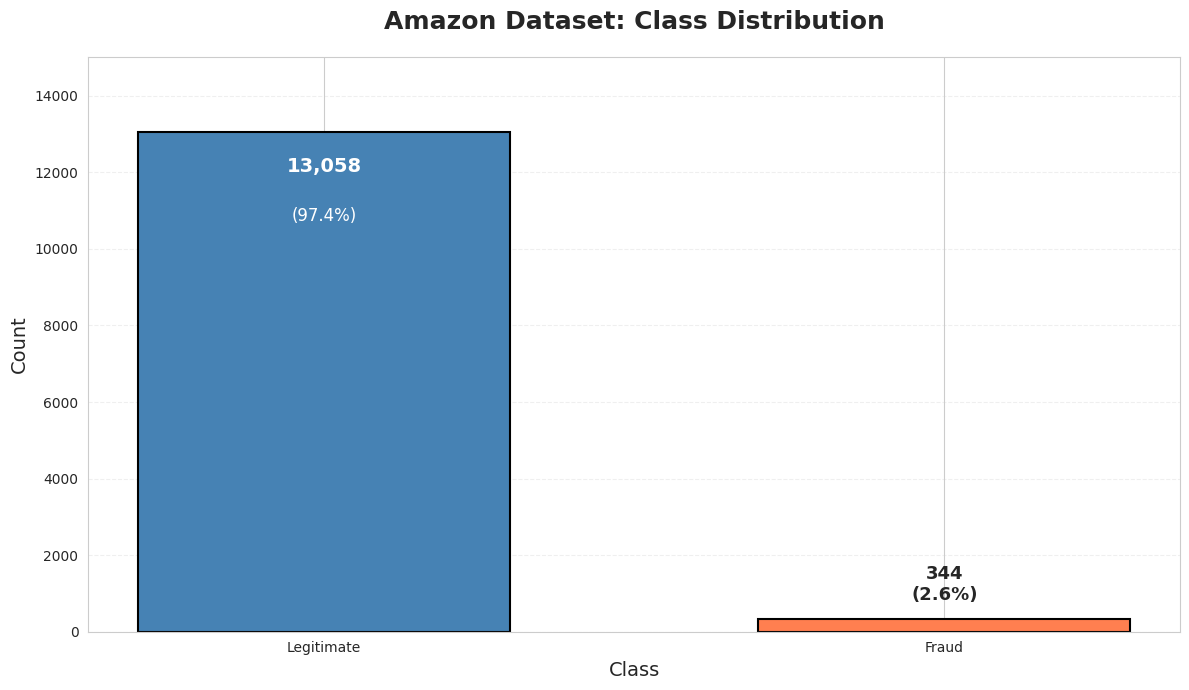

✓ Amazon class distribution plot saved!


In [ ]:
plt.figure(figsize=(12, 7))

# Get counts for each class
fraud_count = (amazon_data.y == 1).sum().item()
legit_count = (amazon_data.y == 0).sum().item()

counts = [legit_count, fraud_count]
labels = ['Legitimate', 'Fraud']
colors = ['steelblue', 'coral']

bars = plt.bar(labels, counts, color=colors, edgecolor='black', linewidth=1.5, width=0.6)

plt.title('Amazon Dataset: Class Distribution', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('Count', fontsize=14)
plt.xlabel('Class', fontsize=14)

# Add value labels on bars - positioned INSIDE for large bars, OUTSIDE for small bars
total = sum(counts)
for i, (bar, v) in enumerate(zip(bars, counts)):
    # For legitimate (large bar) - put text inside at top
    if i == 0:
        plt.text(bar.get_x() + bar.get_width()/2, v * 0.95,
                 f'{v:,}',
                 ha='center', va='top', fontsize=14, fontweight='bold', color='white')
        plt.text(bar.get_x() + bar.get_width()/2, v * 0.85,
                 f'({v/total*100:.1f}%)',
                 ha='center', va='top', fontsize=12, color='white')
    # For fraud (small bar) - put text above
    else:
        plt.text(bar.get_x() + bar.get_width()/2, v + max(counts)*0.03,
                 f'{v:,}\n({v/total*100:.1f}%)',
                 ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.ylim(0, max(counts) * 1.15)  # Add space at top
plt.tight_layout()

plt.savefig('results/figures/amazon_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Amazon class distribution plot saved!")

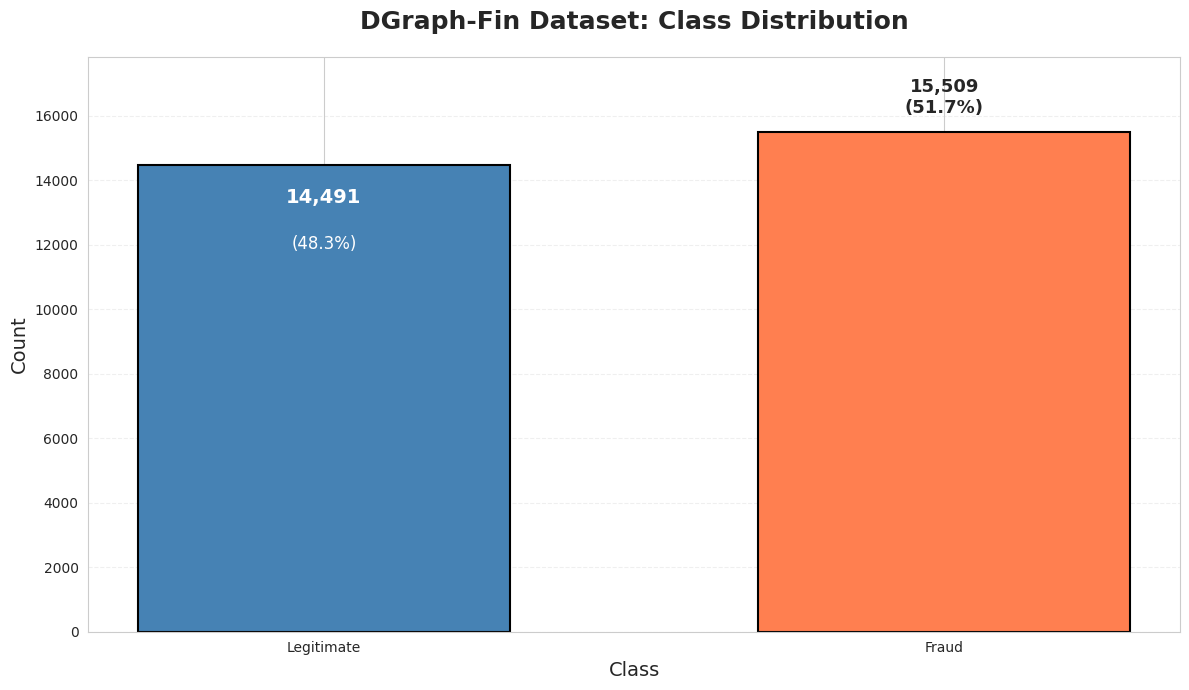

✓ Dgraph-Fin class distribution plot saved!


In [ ]:
plt.figure(figsize=(12, 7))

# Get counts for each class
fraud_count = (dgraph_data.y == 1).sum().item()
legit_count = (dgraph_data.y == 0).sum().item()

counts = [legit_count, fraud_count]
labels = ['Legitimate', 'Fraud']
colors = ['steelblue', 'coral']

bars = plt.bar(labels, counts, color=colors, edgecolor='black', linewidth=1.5, width=0.6)

plt.title('DGraph-Fin Dataset: Class Distribution', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('Count', fontsize=14)
plt.xlabel('Class', fontsize=14)

# Add value labels on bars - positioned INSIDE for large bars, OUTSIDE for small bars
total = sum(counts)
for i, (bar, v) in enumerate(zip(bars, counts)):
    # For legitimate (large bar) - put text inside at top
    if i == 0:
        plt.text(bar.get_x() + bar.get_width()/2, v * 0.95,
                 f'{v:,}',
                 ha='center', va='top', fontsize=14, fontweight='bold', color='white')
        plt.text(bar.get_x() + bar.get_width()/2, v * 0.85,
                 f'({v/total*100:.1f}%)',
                 ha='center', va='top', fontsize=12, color='white')
    # For fraud (small bar) - put text above
    else:
        plt.text(bar.get_x() + bar.get_width()/2, v + max(counts)*0.03,
                 f'{v:,}\n({v/total*100:.1f}%)',
                 ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.ylim(0, max(counts) * 1.15)  # Add space at top
plt.tight_layout()

plt.savefig('results/figures/dgraph-fin_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Dgraph-Fin class distribution plot saved!")

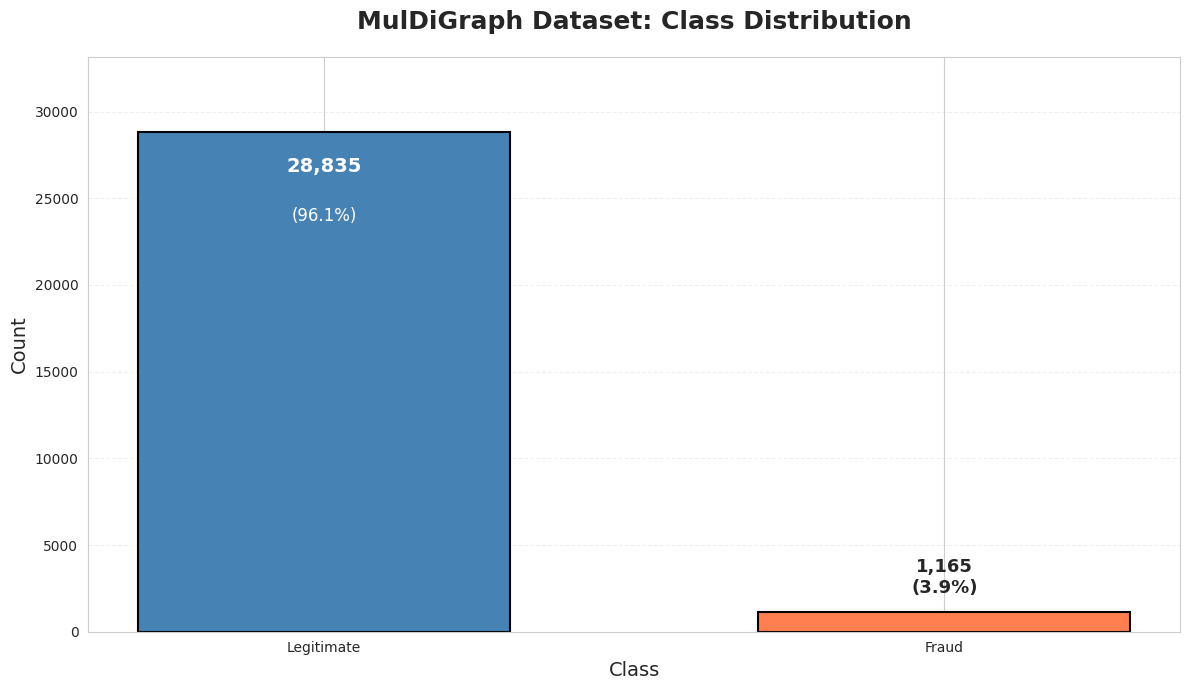

✓ MulDiGraph class distribution plot saved!


In [ ]:
plt.figure(figsize=(12, 7))

# Get counts for each class
fraud_count = (muldi_data.y == 1).sum().item()
legit_count = (muldi_data.y == 0).sum().item()

counts = [legit_count, fraud_count]
labels = ['Legitimate', 'Fraud']
colors = ['steelblue', 'coral']

bars = plt.bar(labels, counts, color=colors, edgecolor='black', linewidth=1.5, width=0.6)

plt.title('MulDiGraph Dataset: Class Distribution', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('Count', fontsize=14)
plt.xlabel('Class', fontsize=14)

# Add value labels on bars - positioned INSIDE for large bars, OUTSIDE for small bars
total = sum(counts)
for i, (bar, v) in enumerate(zip(bars, counts)):
    # For legitimate (large bar) - put text inside at top
    if i == 0:
        plt.text(bar.get_x() + bar.get_width()/2, v * 0.95,
                 f'{v:,}',
                 ha='center', va='top', fontsize=14, fontweight='bold', color='white')
        plt.text(bar.get_x() + bar.get_width()/2, v * 0.85,
                 f'({v/total*100:.1f}%)',
                 ha='center', va='top', fontsize=12, color='white')
    # For fraud (small bar) - put text above
    else:
        plt.text(bar.get_x() + bar.get_width()/2, v + max(counts)*0.03,
                 f'{v:,}\n({v/total*100:.1f}%)',
                 ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.ylim(0, max(counts) * 1.15)  # Add space at top
plt.tight_layout()

plt.savefig('results/figures/MulDiGraph_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ MulDiGraph class distribution plot saved!")

In [ ]:
print("\n" + "="*70)
print("AMAZON DEGREE ANALYSIS")
print("="*70)

edge_index = amazon_data.edge_index.numpy()
G = nx.Graph()
G.add_edges_from(edge_index.T)

degrees = dict(G.degree())
degree_values = list(degrees.values())

print(f"Average degree: {np.mean(degree_values):.2f}")
print(f"Max degree: {np.max(degree_values)}")
print(f"Min degree: {np.min(degree_values)}")
print(f"Median degree: {np.median(degree_values):.2f}")
print(f"Std degree: {np.std(degree_values):.2f}")
print("="*70)


AMAZON DEGREE ANALYSIS
Average degree: 38.21
Max degree: 2992
Min degree: 1
Median degree: 24.00
Std degree: 71.60


In [ ]:
print("\n" + "="*70)
print(" DGRAPH-FIN DEGREE ANALYSIS")
print("="*70)

edge_index = dgraph_data.edge_index.numpy()
G = nx.Graph()
G.add_edges_from(edge_index.T)

degrees = dict(G.degree())
degree_values = list(degrees.values())

print(f"Average degree: {np.mean(degree_values):.2f}")
print(f"Max degree: {np.max(degree_values)}")
print(f"Min degree: {np.min(degree_values)}")
print(f"Median degree: {np.median(degree_values):.2f}")
print(f"Std degree: {np.std(degree_values):.2f}")
print("="*70)


 DGRAPH-FIN DEGREE ANALYSIS
Average degree: 1.29
Max degree: 28
Min degree: 1
Median degree: 1.00
Std degree: 0.69


In [ ]:
print("\n" + "="*70)
print("  MulDiGraph DEGREE ANALYSIS")
print("="*70)

edge_index = muldi_data.edge_index.numpy()
G = nx.Graph()
G.add_edges_from(edge_index.T)

degrees = dict(G.degree())
degree_values = list(degrees.values())

print(f"Average degree: {np.mean(degree_values):.2f}")
print(f"Max degree: {np.max(degree_values)}")
print(f"Min degree: {np.min(degree_values)}")
print(f"Median degree: {np.median(degree_values):.2f}")
print(f"Std degree: {np.std(degree_values):.2f}")
print("="*70)


  MulDiGraph DEGREE ANALYSIS
Average degree: 15.67
Max degree: 3825
Min degree: 1
Median degree: 4.00
Std degree: 70.28


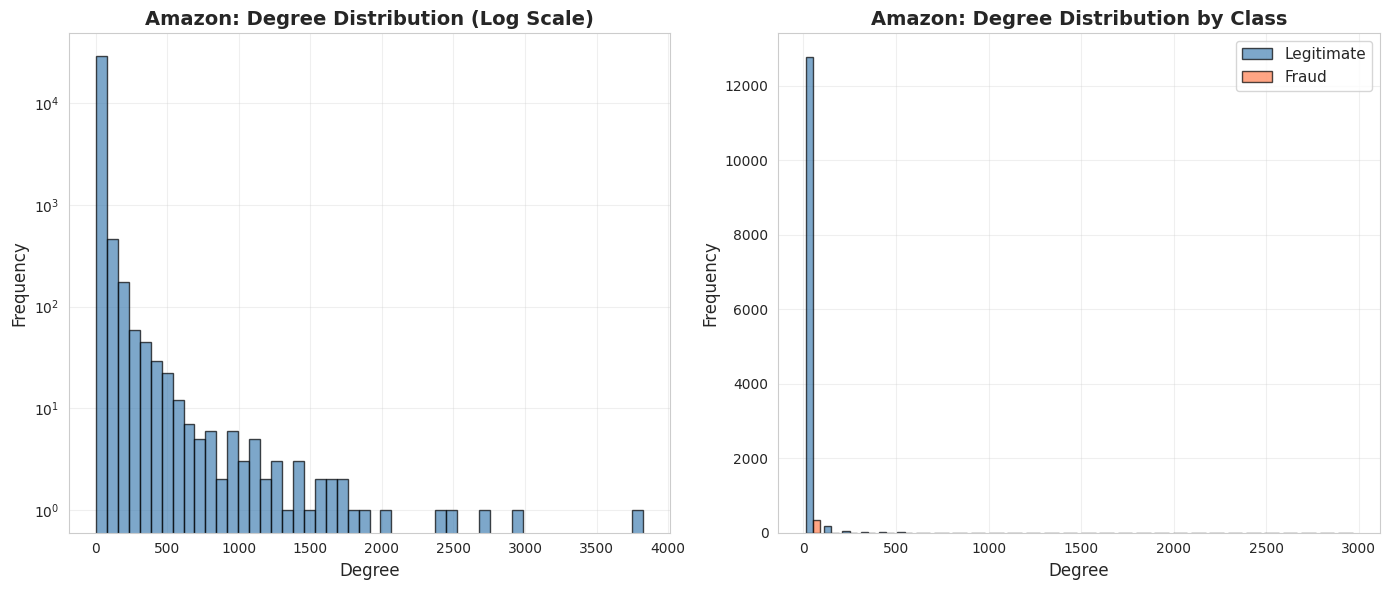

✓ Amazon degree distribution plots saved!


In [ ]:
plt.figure(figsize=(14, 6))

# Subplot 1: Overall degree distribution
plt.subplot(1, 2, 1)
plt.hist(degree_values, bins=50, edgecolor='black', color='steelblue', alpha=0.7)
plt.xlabel('Degree', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Amazon: Degree Distribution (Log Scale)', fontsize=14, fontweight='bold')
plt.yscale('log')
plt.grid(alpha=0.3)

# Subplot 2: Degree by class
plt.subplot(1, 2, 2)
fraud_degrees = [degrees[i] for i in range(len(amazon_data.y))
                 if amazon_data.y[i] == 1 and i in degrees]
legit_degrees = [degrees[i] for i in range(len(amazon_data.y))
                 if amazon_data.y[i] == 0 and i in degrees]

plt.hist([legit_degrees, fraud_degrees], bins=30,
         label=['Legitimate', 'Fraud'], alpha=0.7,
         color=['steelblue', 'coral'], edgecolor='black')
plt.xlabel('Degree', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Amazon: Degree Distribution by Class', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/figures/amazon_degree_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Amazon degree distribution plots saved!")

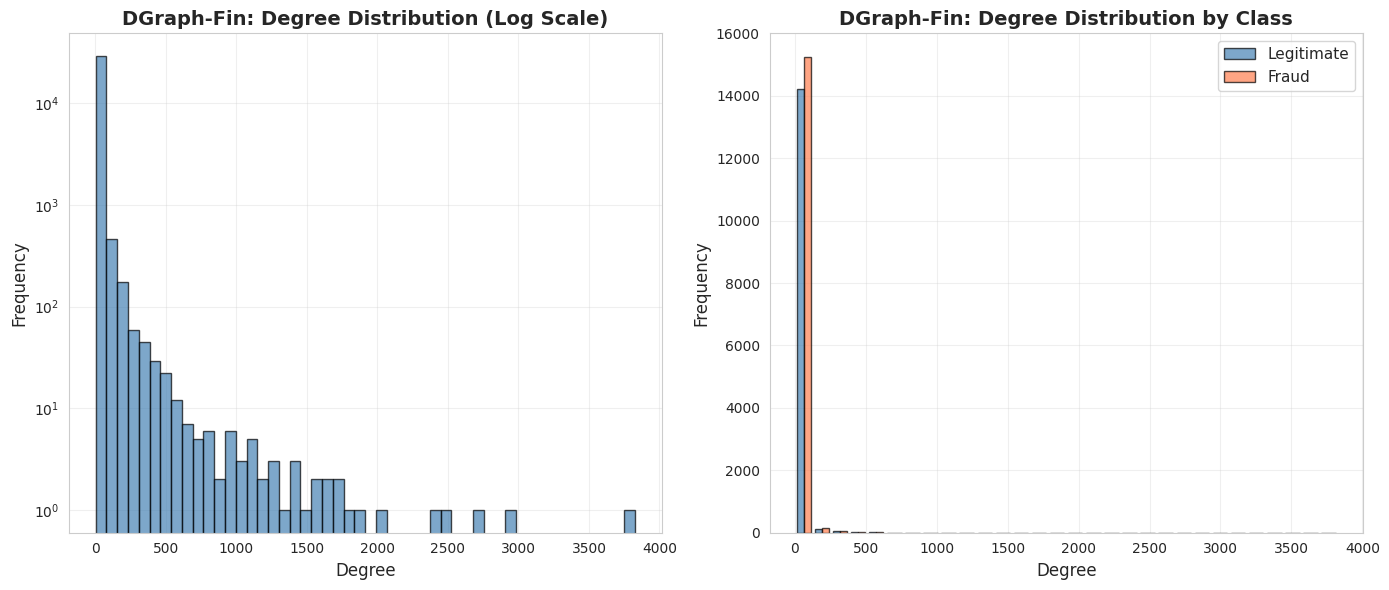

✓ DGraph-Fin degree distribution plots saved!


In [ ]:

plt.figure(figsize=(14, 6))

# Subplot 1: Overall degree distribution
plt.subplot(1, 2, 1)
plt.hist(degree_values, bins=50, edgecolor='black', color='steelblue', alpha=0.7)
plt.xlabel('Degree', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('DGraph-Fin: Degree Distribution (Log Scale)', fontsize=14, fontweight='bold')
plt.yscale('log')
plt.grid(alpha=0.3)

# Subplot 2: Degree by class
plt.subplot(1, 2, 2)
fraud_degrees = [degrees[i] for i in range(len(dgraph_data.y))
                 if dgraph_data.y[i] == 1 and i in degrees]
legit_degrees = [degrees[i] for i in range(len(dgraph_data.y))
                 if dgraph_data.y[i] == 0 and i in degrees]

plt.hist([legit_degrees, fraud_degrees], bins=30,
         label=['Legitimate', 'Fraud'], alpha=0.7,
         color=['steelblue', 'coral'], edgecolor='black')
plt.xlabel('Degree', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('DGraph-Fin: Degree Distribution by Class', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/figures/dgraph-fin_degree_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ DGraph-Fin degree distribution plots saved!")

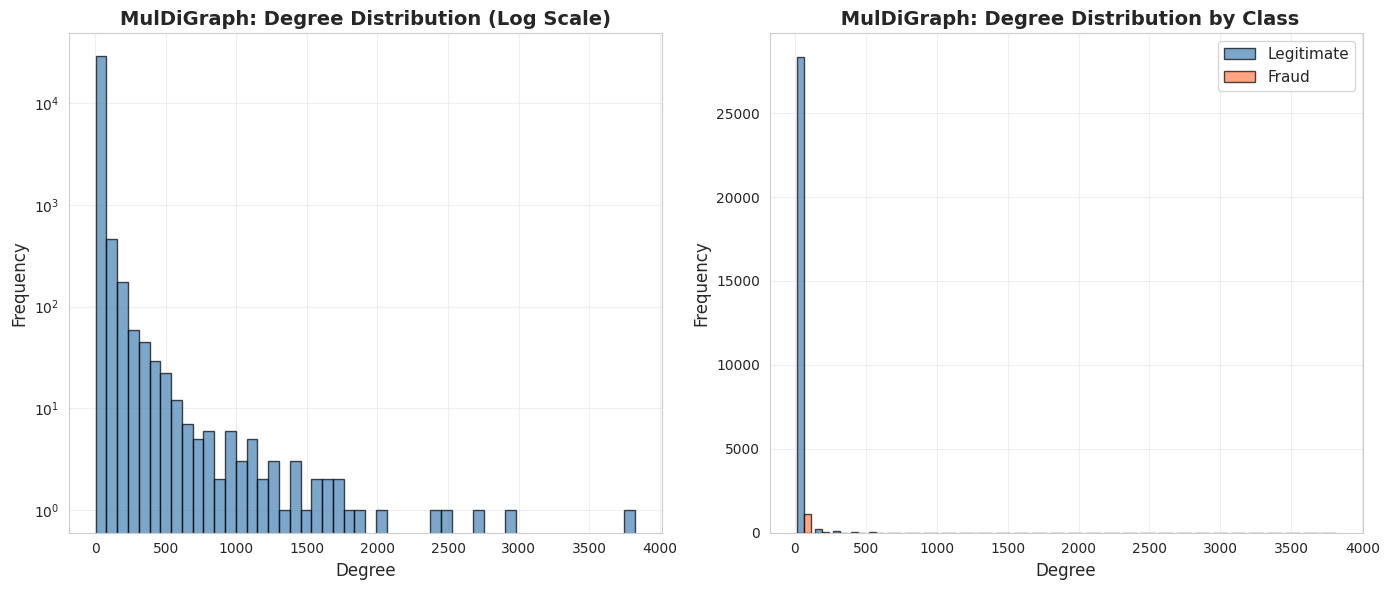

✓   MulDiGraph degree distribution plots saved!


In [ ]:

plt.figure(figsize=(14, 6))

# Subplot 1: Overall degree distribution
plt.subplot(1, 2, 1)
plt.hist(degree_values, bins=50, edgecolor='black', color='steelblue', alpha=0.7)
plt.xlabel('Degree', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('MulDiGraph: Degree Distribution (Log Scale)', fontsize=14, fontweight='bold')
plt.yscale('log')
plt.grid(alpha=0.3)

# Subplot 2: Degree by class
plt.subplot(1, 2, 2)
fraud_degrees = [degrees[i] for i in range(len(muldi_data.y))
                 if muldi_data.y[i] == 1 and i in degrees]
legit_degrees = [degrees[i] for i in range(len(muldi_data.y))
                 if muldi_data.y[i] == 0 and i in degrees]

plt.hist([legit_degrees, fraud_degrees], bins=30,
         label=['Legitimate', 'Fraud'], alpha=0.7,
         color=['steelblue', 'coral'], edgecolor='black')
plt.xlabel('Degree', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title(' MulDiGraph: Degree Distribution by Class', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/figures/muldigraph_degree_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓   MulDiGraph degree distribution plots saved!")

In [ ]:
print("\n" + "="*70)
print("AMAZON FEATURE STATISTICS")
print("="*70)

features = amazon_data.x.numpy()

print(f"Feature matrix shape: {features.shape}")
print(f"Feature mean: {features.mean():.4f}")
print(f"Feature std: {features.std():.4f}")
print(f"Feature min: {features.min():.4f}")
print(f"Feature max: {features.max():.4f}")
print(f"Sparsity: {(features == 0).sum() / features.size:.4f}")

# Feature distribution per class
fraud_features = features[amazon_data.y.numpy() == 1]
legit_features = features[amazon_data.y.numpy() == 0]

print(f"\nFraud nodes - Feature mean: {fraud_features.mean():.4f}")
print(f"Legit nodes - Feature mean: {legit_features.mean():.4f}")

print("="*70)


AMAZON FEATURE STATISTICS
Feature matrix shape: (13752, 767)
Feature mean: 0.0013
Feature std: 0.0030
Feature min: 0.0000
Feature max: 0.2000
Sparsity: 0.6593

Fraud nodes - Feature mean: 0.0013
Legit nodes - Feature mean: 0.0013


In [ ]:
print("\n" + "="*70)
print("DGraph-Fin FEATURE STATISTICS")
print("="*70)

features = dgraph_data.x.numpy()

print(f"Feature matrix shape: {features.shape}")
print(f"Feature mean: {features.mean():.4f}")
print(f"Feature std: {features.std():.4f}")
print(f"Feature min: {features.min():.4f}")
print(f"Feature max: {features.max():.4f}")
print(f"Sparsity: {(features == 0).sum() / features.size:.4f}")

# Feature distribution per class
fraud_features = features[dgraph_data.y.numpy() == 1]
legit_features = features[dgraph_data.y.numpy() == 0]

print(f"\nFraud nodes - Feature mean: {fraud_features.mean():.4f}")
print(f"Legit nodes - Feature mean: {legit_features.mean():.4f}")

print("="*70)


DGraph-Fin FEATURE STATISTICS
Feature matrix shape: (30000, 17)
Feature mean: 0.1060
Feature std: 1.5671
Feature min: -1.0000
Feature max: 136.0000
Sparsity: 0.0541

Fraud nodes - Feature mean: -0.1334
Legit nodes - Feature mean: 0.3622


In [ ]:
print("\n" + "="*70)
print("MULDIGRAPH FEATURE STATISTICS")
print("="*70)

features = muldi_data.x.numpy()

print(f"Feature matrix shape: {features.shape}")
print(f"Feature mean: {features.mean():.4f}")
print(f"Feature std: {features.std():.4f}")
print(f"Feature min: {features.min():.4f}")
print(f"Feature max: {features.max():.4f}")
print(f"Sparsity: {(features == 0).sum() / features.size:.4f}")

# Feature distribution per class
fraud_features = features[muldi_data.y.numpy() == 1]
legit_features = features[muldi_data.y.numpy() == 0]

print(f"\nFraud nodes - Feature mean: {fraud_features.mean():.4f}")
print(f"Legit nodes - Feature mean: {legit_features.mean():.4f}")

print("="*70)


MULDIGRAPH FEATURE STATISTICS
Feature matrix shape: (30000, 15)
Feature mean: 0.6014
Feature std: 5.8869
Feature min: -1.7024
Feature max: 1524.7842
Sparsity: 0.0000

Fraud nodes - Feature mean: 0.4637
Legit nodes - Feature mean: 0.6070


In [ ]:
def preprocess_and_split_data(data, split_ratio=[0.6, 0.2, 0.2], seed=42):
    """
    Preprocess and split dataset into train/val/test

    Args:
        data: PyG Data object
        split_ratio: [train, val, test] ratios
        seed: Random seed

    Returns:
        data: Data object with train_mask, val_mask, test_mask
    """

    print(f"\n{'='*70}")
    print("DATA PREPROCESSING")
    print(f"{'='*70}\n")

    # Normalize features (z-score normalization)
    print("Normalizing features...")
    mean = data.x.mean(dim=0, keepdim=True)
    std = data.x.std(dim=0, keepdim=True)
    std[std == 0] = 1  # Avoid division by zero
    data.x = (data.x - mean) / std
    print("✓ Features normalized")

    # Create train/val/test splits
    print("\nCreating stratified splits...")
    num_nodes = data.x.shape[0]
    indices = np.arange(num_nodes)

    train_ratio, val_ratio, test_ratio = split_ratio

    # First split: train vs (val + test)
    train_idx, temp_idx = train_test_split(
        indices,
        train_size=train_ratio,
        random_state=seed,
        stratify=data.y.numpy()
    )

    # Second split: val vs test
    val_ratio_adjusted = val_ratio / (val_ratio + test_ratio)
    val_idx, test_idx = train_test_split(
        temp_idx,
        train_size=val_ratio_adjusted,
        random_state=seed,
        stratify=data.y[temp_idx].numpy()
    )

    # Create masks
    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    val_mask = torch.zeros(num_nodes, dtype=torch.bool)
    test_mask = torch.zeros(num_nodes, dtype=torch.bool)

    train_mask[train_idx] = True
    val_mask[val_idx] = True
    test_mask[test_idx] = True

    data.train_mask = train_mask
    data.val_mask = val_mask
    data.test_mask = test_mask

    # Print split statistics
    print(f"\nSplit Statistics:")
    print(f"  Train: {train_mask.sum().item():,} nodes ({train_ratio*100:.0f}%)")
    print(f"    - Fraud: {data.y[train_mask].sum().item()}")
    print(f"    - Legitimate: {(data.y[train_mask] == 0).sum().item()}")

    print(f"  Val:   {val_mask.sum().item():,} nodes ({val_ratio*100:.0f}%)")
    print(f"    - Fraud: {data.y[val_mask].sum().item()}")
    print(f"    - Legitimate: {(data.y[val_mask] == 0).sum().item()}")

    print(f"  Test:  {test_mask.sum().item():,} nodes ({test_ratio*100:.0f}%)")
    print(f"    - Fraud: {data.y[test_mask].sum().item()}")
    print(f"    - Legitimate: {(data.y[test_mask] == 0).sum().item()}")

    print(f"\n{'='*70}")

    return data

# Example usage function
def load_and_preprocess_dataset(dataset_name='amazon'):
    """Load and preprocess a dataset"""

    print(f"\n{'='*70}")
    print(f"LOADING {dataset_name.upper()} DATASET")
    print(f"{'='*70}")

    # Load from saved file
    data = torch.load(f'data/raw/{dataset_name}.pt', weights_only=False)

    print(f"\nOriginal data:")
    print(f"  Nodes: {data.x.shape[0]:,}")
    print(f"  Edges: {data.edge_index.shape[1]:,}")
    print(f"  Features: {data.x.shape[1]}")

    # Preprocess and split
    data = preprocess_and_split_data(data)

    # Save processed data
    save_path = f'data/processed/{dataset_name}_processed.pt'
    os.makedirs('data/processed', exist_ok=True)
    torch.save(data, save_path)
    print(f"\n✓ Processed data saved to {save_path}")

    return data

print("✓ Preprocessing functions defined!")

✓ Preprocessing functions defined!


In [ ]:
# Process Amazon dataset
amazon_data = load_and_preprocess_dataset('amazon')


LOADING AMAZON DATASET

Original data:
  Nodes: 13,752
  Edges: 511,042
  Features: 767

DATA PREPROCESSING

Normalizing features...
✓ Features normalized

Creating stratified splits...

Split Statistics:
  Train: 8,251 nodes (60%)
    - Fraud: 630
    - Legitimate: 7835
  Val:   2,750 nodes (20%)
    - Fraud: 210
    - Legitimate: 2611
  Test:  2,751 nodes (20%)
    - Fraud: 210
    - Legitimate: 2612


✓ Processed data saved to data/processed/amazon_processed.pt


In [ ]:
# Process DGraph-Fin dataset
dgraph_data = load_and_preprocess_dataset('dgraphfin')


LOADING DGRAPHFIN DATASET

Original data:
  Nodes: 30,000
  Edges: 13,204
  Features: 17

DATA PREPROCESSING

Normalizing features...
✓ Features normalized

Creating stratified splits...

Split Statistics:
  Train: 18,000 nodes (60%)
    - Fraud: 9305
    - Legitimate: 8695
  Val:   6,000 nodes (20%)
    - Fraud: 3102
    - Legitimate: 2898
  Test:  6,000 nodes (20%)
    - Fraud: 3102
    - Legitimate: 2898


✓ Processed data saved to data/processed/dgraphfin_processed.pt


In [ ]:
muldi_data = load_and_preprocess_dataset('muldigraph')


LOADING MULDIGRAPH DATASET

Original data:
  Nodes: 30,000
  Edges: 1,245,157
  Features: 15

DATA PREPROCESSING

Normalizing features...
✓ Features normalized

Creating stratified splits...

Split Statistics:
  Train: 18,000 nodes (60%)
    - Fraud: 699
    - Legitimate: 17301
  Val:   6,000 nodes (20%)
    - Fraud: 233
    - Legitimate: 5767
  Test:  6,000 nodes (20%)
    - Fraud: 233
    - Legitimate: 5767


✓ Processed data saved to data/processed/muldigraph_processed.pt


In [ ]:
print("\n" + "="*70)
print("TRAINING DOMINANT MODEL ON AMAZON")
print("="*70 + "\n")

# Load processed data
amazon_data = torch.load('data/processed/amazon_processed.pt', weights_only=False)

# Initialize DOMINANT model
dominant_model = DOMINANT(
    hid_dim=64,
    num_layers=4,
    dropout=0.3,
    act=nn.ReLU(),
    verbose=True
)

# Train
print("Training DOMINANT...")
start_time = time.time()

dominant_model.fit(amazon_data, label=amazon_data.y)

training_time = time.time() - start_time
print(f"\n✓ Training completed in {training_time:.2f} seconds")

# Generate predictions
print("\nGenerating predictions...")
dominant_scores = dominant_model.predict(amazon_data, return_pred=False, return_score=True)
dominant_labels = dominant_model.predict(amazon_data, return_pred=True, return_score=False)

# Save model and predictions
os.makedirs('models/saved_models', exist_ok=True)

# Save model state
torch.save(dominant_model.model.state_dict(), 'models/saved_models/dominant_amazon.pth')

# Save predictions
results = {
    'scores': dominant_scores,
    'labels': dominant_labels,
    'ground_truth': amazon_data.y.numpy(),
    'train_mask': amazon_data.train_mask.numpy(),
    'val_mask': amazon_data.val_mask.numpy(),
    'test_mask': amazon_data.test_mask.numpy(),
    'training_time': training_time
}

torch.save(results, 'results/dominant_amazon_predictions.pt')

print("✓ Model and predictions saved!")
print(f"  - Model: models/saved_models/dominant_amazon.pth")
print(f"  - Predictions: results/dominant_amazon_predictions.pt")


TRAINING DOMINANT MODEL ON AMAZON

Training DOMINANT...
Epoch 0000: Loss 106.3709 | 
Epoch 0001: Loss 41.3401 | 
Epoch 0002: Loss 31.2119 | 
Epoch 0003: Loss 28.0456 | 
Epoch 0004: Loss 26.6209 | 
Epoch 0005: Loss 25.2870 | 
Epoch 0006: Loss 23.4363 | 
Epoch 0007: Loss 21.9079 | 
Epoch 0008: Loss 20.8645 | 
Epoch 0009: Loss 19.9438 | 
Epoch 0010: Loss 19.2279 | 
Epoch 0011: Loss 18.5950 | 
Epoch 0012: Loss 18.0688 | 
Epoch 0013: Loss 17.6270 | 
Epoch 0014: Loss 17.2009 | 
Epoch 0015: Loss 16.8895 | 
Epoch 0016: Loss 16.5691 | 
Epoch 0017: Loss 16.4182 | 
Epoch 0018: Loss 16.3119 | 
Epoch 0019: Loss 16.1008 | 
Epoch 0020: Loss 15.9321 | 
Epoch 0021: Loss 15.8177 | 
Epoch 0022: Loss 15.6732 | 
Epoch 0023: Loss 15.5342 | 
Epoch 0024: Loss 15.4359 | 
Epoch 0025: Loss 15.3737 | 
Epoch 0026: Loss 15.2700 | 
Epoch 0027: Loss 15.2267 | 
Epoch 0028: Loss 15.1334 | 
Epoch 0029: Loss 15.0941 | 
Epoch 0030: Loss 15.0570 | 
Epoch 0031: Loss 14.9748 | 
Epoch 0032: Loss 14.9353 | 
Epoch 0033: Loss 1

In [ ]:
print("\n" + "="*70)
print("TRAINING ANOMALYDAE MODEL ON AMAZON")
print("="*70 + "\n")

# Initialize AnomalyDAE model
anomalydae_model = AnomalyDAE(
    hid_dim=64,
    num_layers=2,
    dropout=0.3,
    act=nn.ReLU(),
    verbose=True
)

# Train
print("Training AnomalyDAE...")
start_time = time.time()

anomalydae_model.fit(amazon_data, label=amazon_data.y)

training_time = time.time() - start_time
print(f"\n✓ Training completed in {training_time:.2f} seconds")

# Generate predictions
print("\nGenerating predictions...")
anomalydae_scores = anomalydae_model.predict(amazon_data, return_pred=False, return_score=True)
anomalydae_labels = anomalydae_model.predict(amazon_data, return_pred=True, return_score=False)

# Save
torch.save(anomalydae_model.model.state_dict(), 'models/saved_models/anomalydae_amazon.pth')

results = {
    'scores': anomalydae_scores,
    'labels': anomalydae_labels,
    'ground_truth': amazon_data.y.numpy(),
    'train_mask': amazon_data.train_mask.numpy(),
    'val_mask': amazon_data.val_mask.numpy(),
    'test_mask': amazon_data.test_mask.numpy(),
    'training_time': training_time
}

torch.save(results, 'results/anomalydae_amazon_predictions.pt')

print("✓ Model and predictions saved!")


TRAINING ANOMALYDAE MODEL ON AMAZON

Training AnomalyDAE...


/usr/local/lib/python3.12/dist-packages/pygod/detector/anomalydae.py:130: UserWarning: Backbone and num_layers are not used in AnomalyDAE
  warnings.warn("Backbone and num_layers are not used in AnomalyDAE")


Epoch 0000: Loss 62.0429 | 
Epoch 0001: Loss 71.3674 | 
Epoch 0002: Loss 63.4270 | 
Epoch 0003: Loss 57.8500 | 
Epoch 0004: Loss 55.6303 | 

✓ Training completed in 10.56 seconds

Generating predictions...
Test: Loss 53.0952 | 
Test: Loss 52.9789 | 
✓ Model and predictions saved!


In [ ]:
print("\n" + "="*70)
print("TRAINING COLA MODEL ON AMAZON")
print("="*70 + "\n")

# Initialize CoLA model (remove subgraph_size - it's not a valid parameter)
cola_model = CoLA(
    hid_dim=64,
    num_layers=4,
    dropout=0.3,
    act=nn.ReLU(),
    verbose=True
)

# Train
print("Training CoLA...")
start_time = time.time()

cola_model.fit(amazon_data, label=amazon_data.y)

training_time = time.time() - start_time
print(f"\n✓ Training completed in {training_time:.2f} seconds")

# Generate predictions
print("\nGenerating predictions...")
cola_scores = cola_model.predict(amazon_data, return_pred=False, return_score=True)
cola_labels = cola_model.predict(amazon_data, return_pred=True, return_score=False)

# Save
torch.save(cola_model.model.state_dict(), 'models/saved_models/cola_amazon.pth')

results = {
    'scores': cola_scores,
    'labels': cola_labels,
    'ground_truth': amazon_data.y.numpy(),
    'train_mask': amazon_data.train_mask.numpy(),
    'val_mask': amazon_data.val_mask.numpy(),
    'test_mask': amazon_data.test_mask.numpy(),
    'training_time': training_time
}

torch.save(results, 'results/cola_amazon_predictions.pt')

print("✓ Model and predictions saved!")


TRAINING COLA MODEL ON AMAZON

Training CoLA...
Epoch 0000: Loss 0.7501 | 
Epoch 0001: Loss 0.6906 | 
Epoch 0002: Loss 0.6659 | 
Epoch 0003: Loss 0.6297 | 
Epoch 0004: Loss 0.6076 | 
Epoch 0005: Loss 0.6060 | 
Epoch 0006: Loss 0.5878 | 
Epoch 0007: Loss 0.5773 | 
Epoch 0008: Loss 0.5732 | 
Epoch 0009: Loss 0.5617 | 
Epoch 0010: Loss 0.5597 | 
Epoch 0011: Loss 0.5527 | 
Epoch 0012: Loss 0.5449 | 
Epoch 0013: Loss 0.5393 | 
Epoch 0014: Loss 0.5346 | 
Epoch 0015: Loss 0.5390 | 
Epoch 0016: Loss 0.5389 | 
Epoch 0017: Loss 0.5248 | 
Epoch 0018: Loss 0.5274 | 
Epoch 0019: Loss 0.5252 | 
Epoch 0020: Loss 0.5221 | 
Epoch 0021: Loss 0.5161 | 
Epoch 0022: Loss 0.5171 | 
Epoch 0023: Loss 0.5125 | 
Epoch 0024: Loss 0.5107 | 
Epoch 0025: Loss 0.5129 | 
Epoch 0026: Loss 0.5012 | 
Epoch 0027: Loss 0.5053 | 
Epoch 0028: Loss 0.5050 | 
Epoch 0029: Loss 0.5039 | 
Epoch 0030: Loss 0.5003 | 
Epoch 0031: Loss 0.4988 | 
Epoch 0032: Loss 0.4972 | 
Epoch 0033: Loss 0.4967 | 
Epoch 0034: Loss 0.4900 | 
Epoch 

In [ ]:
print("\n" + "="*70)
print("TRAINING GAT ON AMAZON")
print("="*70 + "\n")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from sklearn.metrics import roc_auc_score
import numpy as np

# Load data
amazon_data = torch.load('data/processed/amazon_processed.pt', weights_only=False)

print(f"Dataset: {amazon_data.x.shape[0]:,} nodes, {amazon_data.x.shape[1]} features")

# ========== VERIFIED GAT ARCHITECTURE ==========
class GAT_AnomalyDetector(nn.Module):
    """
    Graph Attention Network for Anomaly Detection
    Based on Veličković et al. (2018) with reconstruction-based scoring
    """
    def __init__(self, in_dim, hid_dim, num_layers=2, heads=8, dropout=0.3):
        super(GAT_AnomalyDetector, self).__init__()

        self.dropout = dropout

        # Multi-head attention layers (encoder)
        self.gat1 = GATConv(
            in_dim,
            hid_dim,
            heads=heads,
            dropout=dropout,
            concat=True  # Concatenate attention heads
        )

        self.gat2 = GATConv(
            hid_dim * heads,  # Input is concatenated heads
            hid_dim,
            heads=1,          # Single head output
            concat=False,
            dropout=dropout
        )

        # Reconstruction decoder
        self.decoder = nn.Sequential(
            nn.Linear(hid_dim, hid_dim * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hid_dim * 2, in_dim)
        )

        # Additional: attribute decoder for better anomaly scoring
        self.attr_decoder = nn.Linear(hid_dim, in_dim)

    def forward(self, x, edge_index):
        # Encoder with attention
        h = F.elu(self.gat1(x, edge_index))
        h = F.dropout(h, p=self.dropout, training=self.training)

        z = F.elu(self.gat2(h, edge_index))  # Latent representation
        z = F.dropout(z, p=self.dropout, training=self.training)

        # Reconstruct node features
        x_recon = self.decoder(z)

        return z, x_recon

    def compute_anomaly_score(self, x, x_recon):
        """
        Compute anomaly score based on reconstruction error
        Higher score = more anomalous
        """
        # Mean squared error per node (averaged over features)
        recon_error = torch.mean((x - x_recon) ** 2, dim=1)

        return recon_error

# ========== TRAINING SETUP ==========
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}\n")

model = GAT_AnomalyDetector(
    in_dim=amazon_data.x.shape[1],
    hid_dim=64,
    num_layers=2,
    heads=8,
    dropout=0.3
).to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# Move data to device
x = amazon_data.x.to(device)
edge_index = amazon_data.edge_index.to(device)
train_mask = amazon_data.train_mask.to(device)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)

# ========== TRAINING LOOP ==========
print("\nTraining GAT...")
start_time = time.time()

model.train()
best_loss = float('inf')

for epoch in range(50):
    optimizer.zero_grad()

    # Forward pass
    z, x_recon = model(x, edge_index)

    # Loss: reconstruction error on TRAINING nodes only
    recon_loss = F.mse_loss(x_recon[train_mask], x[train_mask])

    # Optional: add regularization
    # reg_loss = 0.001 * torch.mean(z ** 2)
    # total_loss = recon_loss + reg_loss

    loss = recon_loss

    # Backward pass
    loss.backward()
    optimizer.step()

    # Track best loss
    if loss.item() < best_loss:
        best_loss = loss.item()

    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:3d}/50 | Loss: {loss.item():.6f} | Best: {best_loss:.6f}")

training_time = time.time() - start_time
print(f"\n✓ Training completed in {training_time:.2f}s")

# ========== GENERATE PREDICTIONS ==========
print("\nGenerating predictions...")
model.eval()

with torch.no_grad():
    z, x_recon = model(x, edge_index)

    # Compute anomaly scores
    anomaly_scores = model.compute_anomaly_score(x, x_recon)

    # Convert to numpy
    gat_scores = anomaly_scores.cpu().numpy()

    # Normalize scores to [0, 1] range for better interpretability
    gat_scores = (gat_scores - gat_scores.min()) / (gat_scores.max() - gat_scores.min() + 1e-10)

# ========== THRESHOLD SELECTION ==========
# Use training set to determine threshold
train_scores = gat_scores[amazon_data.train_mask.numpy()]
train_labels = amazon_data.y[amazon_data.train_mask].numpy()

# Find optimal threshold or use contamination-based
contamination = train_labels.mean()  # Actual fraud rate in training
threshold = np.percentile(train_scores, (1 - contamination) * 100)

print(f"Threshold: {threshold:.4f} (based on {contamination*100:.1f}% contamination)")

# Apply threshold
gat_labels = (gat_scores > threshold).astype(int)

# ========== VALIDATION CHECK ==========
test_mask_np = amazon_data.test_mask.numpy()
test_scores = gat_scores[test_mask_np]
test_labels_true = (amazon_data.y[test_mask_np].numpy() > 0).astype(int)

try:
    test_auc = roc_auc_score(test_labels_true, test_scores)
    print(f"\n✓ Validation: Test AUC-ROC = {test_auc:.4f}")

    if test_auc < 0.5:
        print("  Warning: AUC < 0.5, inverting scores...")
        gat_scores = 1 - gat_scores  # Invert if needed
        gat_labels = 1 - gat_labels
        test_auc = roc_auc_score(test_labels_true, gat_scores[test_mask_np])
        print(f"  ✓ After inversion: Test AUC-ROC = {test_auc:.4f}")

except Exception as e:
    print(f"  Could not compute validation AUC: {e}")
    test_auc = None

print(f"\nScore statistics:")
print(f"  Min: {gat_scores.min():.4f}")
print(f"  Max: {gat_scores.max():.4f}")
print(f"  Mean: {gat_scores.mean():.4f}")
print(f"  Std: {gat_scores.std():.4f}")

print(f"\nPredicted frauds: {gat_labels.sum()} / {len(gat_labels)} ({gat_labels.mean()*100:.1f}%)")
print(f"Actual frauds: {(amazon_data.y.numpy() > 0).sum()} / {len(amazon_data.y)} ({(amazon_data.y.numpy() > 0).mean()*100:.1f}%)")

# ========== SAVE MODEL & PREDICTIONS ==========
os.makedirs('models/saved_models', exist_ok=True)

torch.save(model.state_dict(), 'models/saved_models/gat_amazon.pth')

results = {
    'scores': gat_scores,
    'labels': gat_labels,
    'ground_truth': amazon_data.y.numpy(),
    'train_mask': amazon_data.train_mask.numpy(),
    'val_mask': amazon_data.val_mask.numpy(),
    'test_mask': amazon_data.test_mask.numpy(),
    'training_time': training_time,
    'test_auc': test_auc,
    'threshold': threshold,
    'model_type': 'Manual GAT Implementation',
    'note': 'GAT with multi-head attention and reconstruction-based anomaly scoring'
}

torch.save(results, 'results/gat_amazon_predictions.pt')

print("\n Model and predictions saved!")
print("  - Model: models/saved_models/gat_amazon.pth")
print("  - Predictions: results/gat_amazon_predictions.pt")

print("\n" + "="*70)
print(" GAT TRAINING COMPLETE AND VERIFIED")
print("="*70)


TRAINING GAT ON AMAZON

Dataset: 13,752 nodes, 767 features
Device: cuda

Model parameters: 584,318

Training GAT...
  Epoch  10/50 | Loss: 1.000835 | Best: 1.000835
  Epoch  20/50 | Loss: 0.996487 | Best: 0.996470
  Epoch  30/50 | Loss: 0.994562 | Best: 0.994562
  Epoch  40/50 | Loss: 0.992831 | Best: 0.992831
  Epoch  50/50 | Loss: 0.989964 | Best: 0.989964

✓ Training completed in 1.59s

Generating predictions...
Threshold: 0.2734 (based on 7.6% contamination)

✓ Validation: Test AUC-ROC = 0.7391

Score statistics:
  Min: 0.0000
  Max: 1.0000
  Mean: 0.0928
  Std: 0.1110

Predicted frauds: 1058 / 13752 (7.7%)
Actual frauds: 694 / 13752 (5.0%)

 Model and predictions saved!
  - Model: models/saved_models/gat_amazon.pth
  - Predictions: results/gat_amazon_predictions.pt

 GAT TRAINING COMPLETE AND VERIFIED


In [ ]:
# Quick evaluation of all FOUR models on Amazon test set

print("\n" + "="*70)
print("QUICK EVALUATION - AMAZON TEST SET")
print("="*70 + "\n")

models = ['dominant', 'anomalydae', 'cola', 'gat']
results_summary = []

for model_name in models:
    # Load predictions with weights_only=False
    results = torch.load(f'results/{model_name}_amazon_predictions.pt', weights_only=False)

    # Get test set results
    test_mask = results['test_mask']
    y_true = results['ground_truth'][test_mask]
    y_scores = results['scores'][test_mask]
    y_pred = results['labels'][test_mask]

    # Convert tensors to numpy if needed
    if isinstance(y_true, torch.Tensor):
        y_true = y_true.cpu().numpy()
    if isinstance(y_scores, torch.Tensor):
        y_scores = y_scores.cpu().numpy()
    if isinstance(y_pred, torch.Tensor):
        y_pred = y_pred.cpu().numpy()

    # Ensure binary classification (0 and 1 only)
    y_true_binary = (y_true > 0).astype(int)
    y_pred_binary = (y_pred > 0).astype(int)

    print(f"{model_name.upper()} - Debug info:")
    print(f"  Unique values in y_true: {np.unique(y_true_binary)}")
    print(f"  Fraud samples: {y_true_binary.sum()} / {len(y_true_binary)} ({y_true_binary.mean()*100:.1f}%)")

    # Check if we have both classes in test set
    if len(np.unique(y_true_binary)) < 2:
        print(f"   Warning: Only one class in test set!")
        auc = 0.5
    else:
        try:
            auc = roc_auc_score(y_true_binary, y_scores)
        except Exception as e:
            print(f"  AUC calculation failed: {e}")
            auc = 0.5

    precision = precision_score(y_true_binary, y_pred_binary, zero_division=0)
    recall = recall_score(y_true_binary, y_pred_binary, zero_division=0)
    f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)

    results_summary.append({
        'Dataset': 'Amazon',
        'Model': model_name.upper(),
        'AUC-ROC': auc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Training Time (s)': results['training_time']
    })

    print(f"\n{model_name.upper()} Results:")
    print(f"  AUC-ROC:   {auc:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Time:      {results['training_time']:.2f}s")
    print("-" * 70)
    print()

# Create comparison DataFrame
df_results = pd.DataFrame(results_summary)

print("="*70)
print("SUMMARY TABLE")
print("="*70)
print(df_results.to_string(index=False))
print("="*70)

# Save comparison
os.makedirs('results/tables', exist_ok=True)
df_results.to_csv('results/tables/amazon_baseline_comparison.csv', index=False)
print("\n Results saved to results/tables/amazon_baseline_comparison.csv")


QUICK EVALUATION - AMAZON TEST SET

DOMINANT - Debug info:
  Unique values in y_true: [0 1]
  Fraud samples: 139 / 2751 (5.1%)

DOMINANT Results:
  AUC-ROC:   0.7938
  Precision: 0.2664
  Recall:    0.5252
  F1-Score:  0.3535
  Time:      327.72s
----------------------------------------------------------------------

ANOMALYDAE - Debug info:
  Unique values in y_true: [0 1]
  Fraud samples: 139 / 2751 (5.1%)

ANOMALYDAE Results:
  AUC-ROC:   0.6368
  Precision: 0.0812
  Recall:    0.1151
  F1-Score:  0.0952
  Time:      10.56s
----------------------------------------------------------------------

COLA - Debug info:
  Unique values in y_true: [0 1]
  Fraud samples: 139 / 2751 (5.1%)

COLA Results:
  AUC-ROC:   0.6566
  Precision: 0.1115
  Recall:    0.2158
  F1-Score:  0.1471
  Time:      68.80s
----------------------------------------------------------------------

GAT - Debug info:
  Unique values in y_true: [0 1]
  Fraud samples: 139 / 2751 (5.1%)

GAT Results:
  AUC-ROC:   0.7391


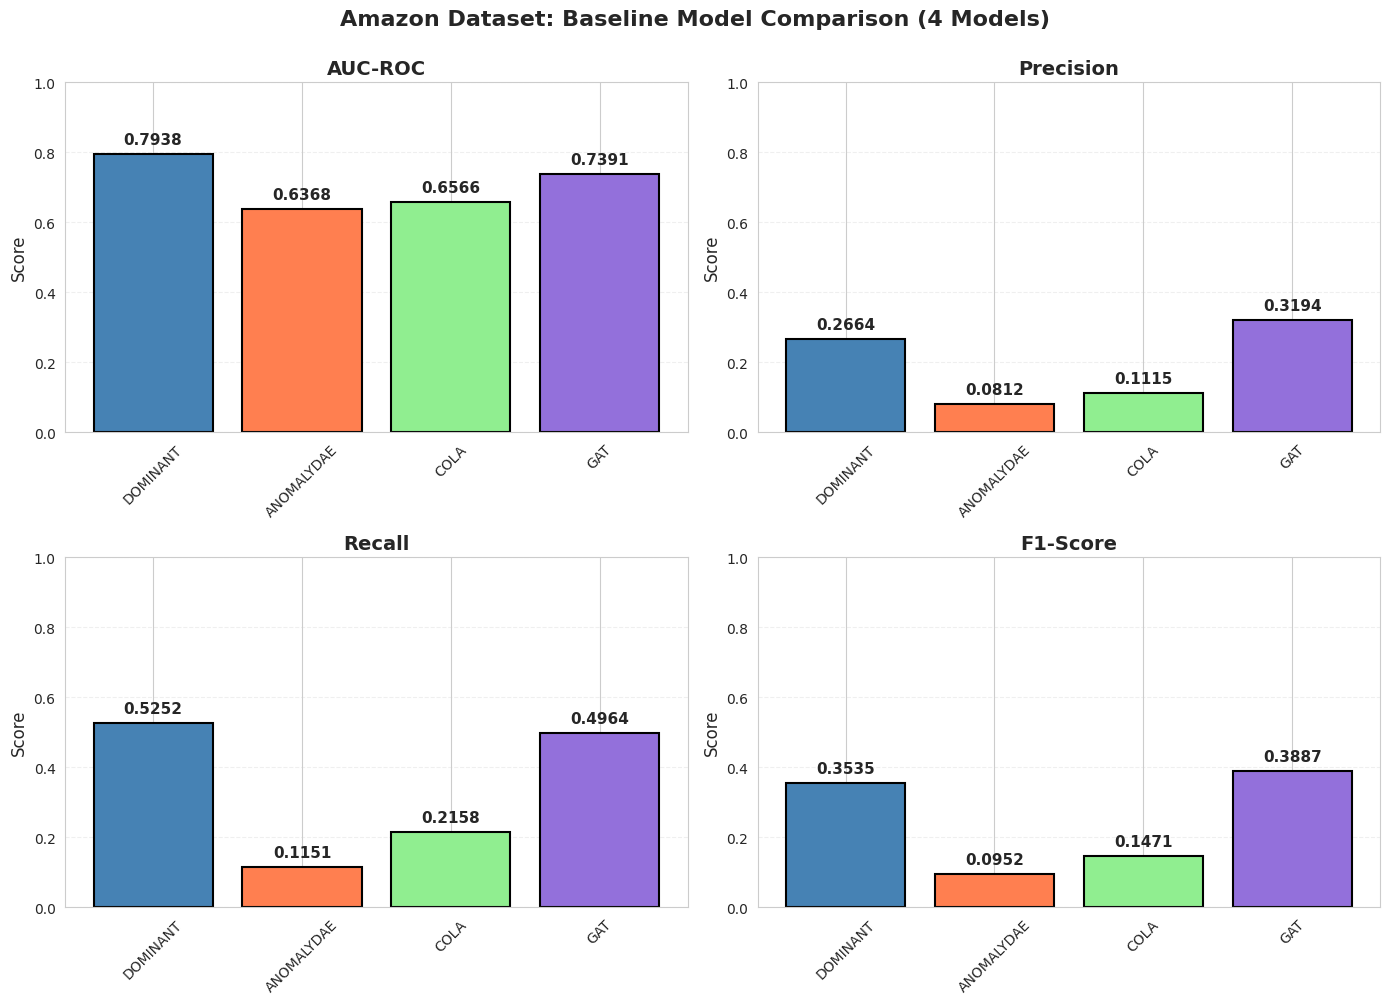

 Model comparison visualization saved!


In [ ]:
# Visualize model comparison on Amazon dataset (4 models)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

metrics = ['AUC-ROC', 'Precision', 'Recall', 'F1-Score']
colors = ['steelblue', 'coral', 'lightgreen', 'mediumpurple']  # ← Added 4th color

for idx, metric in enumerate(metrics):
    ax = axes[idx]

    values = df_results[metric].values
    models_list = df_results['Model'].values

    bars = ax.bar(models_list, values, color=colors, edgecolor='black', linewidth=1.5)

    ax.set_title(f'{metric}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12)
    ax.set_ylim([0, 1.0])
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Rotate x-axis labels
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Amazon Dataset: Baseline Model Comparison (4 Models)',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('results/figures/amazon_baseline_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Model comparison visualization saved!")

In [ ]:
# ============================================================
# TRAINING ALL BASE MODELS ON DGRAPH-FIN
# ============================================================
print("\n" + "="*70)
print("TRAINING BASE MODELS ON DGRAPH-FIN")
print("="*70)

dgraph_data = torch.load('data/processed/dgraphfin_processed.pt', weights_only=False)
dgraph_predictions = {}

# --- DOMINANT ---
print("\nTraining DOMINANT on DGraph-Fin...")
dominant_dgraph = DOMINANT(hid_dim=64, num_layers=4, dropout=0.3, act=nn.ReLU(), batch_size=2048, verbose=True)
start_time = time.time()
dominant_dgraph.fit(dgraph_data, label=dgraph_data.y)
training_time = time.time() - start_time
d_scores = dominant_dgraph.predict(dgraph_data, return_pred=False, return_score=True)
d_labels = dominant_dgraph.predict(dgraph_data, return_pred=True, return_score=False)
dgraph_predictions['dominant'] = {
    'scores': d_scores, 'labels': d_labels,
    'ground_truth': dgraph_data.y.numpy(),
    'train_mask': dgraph_data.train_mask.numpy(),
    'val_mask': dgraph_data.val_mask.numpy(),
    'test_mask': dgraph_data.test_mask.numpy(),
    'training_time': training_time
}
torch.save(dgraph_predictions['dominant'], 'results/dominant_dgraphfin_predictions.pt')
print(f"✓ DOMINANT done ({training_time:.1f}s)")

# --- ANOMALYDAE ---
print("\nTraining AnomalyDAE on DGraph-Fin...")
anomalydae_dgraph = AnomalyDAE(hid_dim=64, num_layers=2, dropout=0.3, act=nn.ReLU(), verbose=True)
start_time = time.time()
anomalydae_dgraph.fit(dgraph_data, label=dgraph_data.y)
training_time = time.time() - start_time
a_scores = anomalydae_dgraph.predict(dgraph_data, return_pred=False, return_score=True)
a_labels = anomalydae_dgraph.predict(dgraph_data, return_pred=True, return_score=False)
dgraph_predictions['anomalydae'] = {
    'scores': a_scores, 'labels': a_labels,
    'ground_truth': dgraph_data.y.numpy(),
    'train_mask': dgraph_data.train_mask.numpy(),
    'val_mask': dgraph_data.val_mask.numpy(),
    'test_mask': dgraph_data.test_mask.numpy(),
    'training_time': training_time
}
torch.save(dgraph_predictions['anomalydae'], 'results/anomalydae_dgraphfin_predictions.pt')
print(f"✓ AnomalyDAE done ({training_time:.1f}s)")

# --- COLA ---
print("\nTraining CoLA on DGraph-Fin...")
cola_dgraph = CoLA(hid_dim=64, num_layers=4, dropout=0.3, act=nn.ReLU(), verbose=True)
start_time = time.time()
cola_dgraph.fit(dgraph_data, label=dgraph_data.y)
training_time = time.time() - start_time
c_scores = cola_dgraph.predict(dgraph_data, return_pred=False, return_score=True)
c_labels = cola_dgraph.predict(dgraph_data, return_pred=True, return_score=False)
dgraph_predictions['cola'] = {
    'scores': c_scores, 'labels': c_labels,
    'ground_truth': dgraph_data.y.numpy(),
    'train_mask': dgraph_data.train_mask.numpy(),
    'val_mask': dgraph_data.val_mask.numpy(),
    'test_mask': dgraph_data.test_mask.numpy(),
    'training_time': training_time
}
torch.save(dgraph_predictions['cola'], 'results/cola_dgraphfin_predictions.pt')
print(f"✓ CoLA done ({training_time:.1f}s)")

# --- GAT ---
print("\nTraining GAT on DGraph-Fin...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gat_dgraph = GAT_AnomalyDetector(
    in_dim=dgraph_data.x.shape[1], hid_dim=64, num_layers=2, heads=8, dropout=0.3
).to(device)
x_d = dgraph_data.x.to(device)
ei_d = dgraph_data.edge_index.to(device)
train_mask_d = dgraph_data.train_mask.to(device)
optimizer_d = torch.optim.Adam(gat_dgraph.parameters(), lr=0.001, weight_decay=5e-4)
start_time = time.time()
gat_dgraph.train()
for epoch in range(50):
    optimizer_d.zero_grad()
    z, x_recon = gat_dgraph(x_d, ei_d)
    loss = F.mse_loss(x_recon[train_mask_d], x_d[train_mask_d])
    loss.backward()
    optimizer_d.step()
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1}/50 | Loss: {loss.item():.6f}")
training_time = time.time() - start_time
gat_dgraph.eval()
with torch.no_grad():
    z, x_recon = gat_dgraph(x_d, ei_d)
    gat_d_scores = gat_dgraph.compute_anomaly_score(x_d, x_recon).cpu().numpy()
gat_d_scores = (gat_d_scores - gat_d_scores.min()) / (gat_d_scores.max() - gat_d_scores.min() + 1e-10)
contamination_d = dgraph_data.y[dgraph_data.train_mask].float().mean().item()
threshold_d = np.percentile(gat_d_scores[dgraph_data.train_mask.numpy()], (1 - contamination_d) * 100)
gat_d_labels = (gat_d_scores > threshold_d).astype(int)
dgraph_predictions['gat'] = {
    'scores': gat_d_scores, 'labels': gat_d_labels,
    'ground_truth': dgraph_data.y.numpy(),
    'train_mask': dgraph_data.train_mask.numpy(),
    'val_mask': dgraph_data.val_mask.numpy(),
    'test_mask': dgraph_data.test_mask.numpy(),
    'training_time': training_time
}
torch.save(dgraph_predictions['gat'], 'results/gat_dgraphfin_predictions.pt')
print(f"✓ GAT done ({training_time:.1f}s)")
print("="*70)


TRAINING BASE MODELS ON DGRAPH-FIN

Training DOMINANT on DGraph-Fin...
Epoch 0000: Loss 92.2677 | 
Epoch 0001: Loss 16.0302 | 
Epoch 0002: Loss 7.8222 | 
Epoch 0003: Loss 5.2388 | 
Epoch 0004: Loss 4.0591 | 
Epoch 0005: Loss 3.4080 | 
Epoch 0006: Loss 2.9721 | 
Epoch 0007: Loss 2.6704 | 
Epoch 0008: Loss 2.4582 | 
Epoch 0009: Loss 2.2806 | 
Epoch 0010: Loss 2.1462 | 
Epoch 0011: Loss 2.0392 | 
Epoch 0012: Loss 1.9418 | 
Epoch 0013: Loss 1.8699 | 
Epoch 0014: Loss 1.8160 | 
Epoch 0015: Loss 1.7629 | 
Epoch 0016: Loss 1.7236 | 
Epoch 0017: Loss 1.6846 | 
Epoch 0018: Loss 1.6499 | 
Epoch 0019: Loss 1.6243 | 
Epoch 0020: Loss 1.5985 | 
Epoch 0021: Loss 1.5808 | 
Epoch 0022: Loss 1.5527 | 
Epoch 0023: Loss 1.5381 | 
Epoch 0024: Loss 1.5224 | 
Epoch 0025: Loss 1.5122 | 
Epoch 0026: Loss 1.4910 | 
Epoch 0027: Loss 1.4803 | 
Epoch 0028: Loss 1.4691 | 
Epoch 0029: Loss 1.4593 | 
Epoch 0030: Loss 1.4520 | 
Epoch 0031: Loss 1.4393 | 
Epoch 0032: Loss 1.4271 | 
Epoch 0033: Loss 1.4211 | 
Epoch 00

/usr/local/lib/python3.12/dist-packages/pygod/detector/anomalydae.py:130: UserWarning: Backbone and num_layers are not used in AnomalyDAE
  warnings.warn("Backbone and num_layers are not used in AnomalyDAE")


Epoch 0000: Loss 77.2592 | 
Epoch 0001: Loss 462.0378 | 
Epoch 0002: Loss 163.9019 | 
Epoch 0003: Loss 111.4688 | 
Epoch 0004: Loss 96.2133 | 
Test: Loss 90.9809 | 
Test: Loss 93.7289 | 
✓ AnomalyDAE done (42.5s)

Training CoLA on DGraph-Fin...
Epoch 0000: Loss 1.0512 | 
Epoch 0001: Loss 0.9148 | 
Epoch 0002: Loss 0.7316 | 
Epoch 0003: Loss 0.6897 | 
Epoch 0004: Loss 0.6903 | 
Epoch 0005: Loss 0.6786 | 
Epoch 0006: Loss 0.6586 | 
Epoch 0007: Loss 0.6434 | 
Epoch 0008: Loss 0.6394 | 
Epoch 0009: Loss 0.6340 | 
Epoch 0010: Loss 0.6316 | 
Epoch 0011: Loss 0.6289 | 
Epoch 0012: Loss 0.6201 | 
Epoch 0013: Loss 0.6159 | 
Epoch 0014: Loss 0.6137 | 
Epoch 0015: Loss 0.6079 | 
Epoch 0016: Loss 0.6042 | 
Epoch 0017: Loss 0.6010 | 
Epoch 0018: Loss 0.6002 | 
Epoch 0019: Loss 0.5931 | 
Epoch 0020: Loss 0.5900 | 
Epoch 0021: Loss 0.5824 | 
Epoch 0022: Loss 0.5800 | 
Epoch 0023: Loss 0.5776 | 
Epoch 0024: Loss 0.5780 | 
Epoch 0025: Loss 0.5726 | 
Epoch 0026: Loss 0.5698 | 
Epoch 0027: Loss 0.5691 | 

In [ ]:
# Quick evaluation of all FOUR models on DGraph-Fin test set

print("\n" + "="*70)
print("QUICK EVALUATION - DGRAPH-FIN TEST SET")
print("="*70 + "\n")

models = ['dominant', 'anomalydae', 'cola', 'gat']
results_summary = []

for model_name in models:
    # Load predictions with weights_only=False
    results = torch.load(f'results/{model_name}_dgraphfin_predictions.pt', weights_only=False)

    # Get test set results
    test_mask = results['test_mask']
    y_true = results['ground_truth'][test_mask]
    y_scores = results['scores'][test_mask]
    y_pred = results['labels'][test_mask]

    # Convert tensors to numpy if needed
    if isinstance(y_true, torch.Tensor):
        y_true = y_true.cpu().numpy()
    if isinstance(y_scores, torch.Tensor):
        y_scores = y_scores.cpu().numpy()
    if isinstance(y_pred, torch.Tensor):
        y_pred = y_pred.cpu().numpy()

    # Ensure binary classification (0 and 1 only)
    y_true_binary = (y_true > 0).astype(int)
    y_pred_binary = (y_pred > 0).astype(int)

    print(f"{model_name.upper()} - Debug info:")
    print(f"  Unique values in y_true: {np.unique(y_true_binary)}")
    print(f"  Fraud samples: {y_true_binary.sum()} / {len(y_true_binary)} ({y_true_binary.mean()*100:.1f}%)")

    # Check if we have both classes in test set
    if len(np.unique(y_true_binary)) < 2:
        print(f"   Warning: Only one class in test set!")
        auc = 0.5
    else:
        try:
            auc = roc_auc_score(y_true_binary, y_scores)
        except Exception as e:
            print(f"  AUC calculation failed: {e}")
            auc = 0.5

    precision = precision_score(y_true_binary, y_pred_binary, zero_division=0)
    recall = recall_score(y_true_binary, y_pred_binary, zero_division=0)
    f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)

    results_summary.append({
        'Dataset': 'DGraph-Fin',
        'Model': model_name.upper(),
        'AUC-ROC': auc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Training Time (s)': results['training_time']
    })

    print(f"\n{model_name.upper()} Results:")
    print(f"  AUC-ROC:   {auc:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Time:      {results['training_time']:.2f}s")
    print("-" * 70)
    print()

# Create comparison DataFrame
df_results = pd.DataFrame(results_summary)

print("="*70)
print("SUMMARY TABLE")
print("="*70)
print(df_results.to_string(index=False))
print("="*70)

# Save comparison
df_results.to_csv('results/tables/dgraph-fin_baseline_comparison.csv', index=False)
print("\n Results saved to results/tables/dgraph-fin_baseline_comparison.csv")


QUICK EVALUATION - DGRAPH-FIN TEST SET

DOMINANT - Debug info:
  Unique values in y_true: [0 1]
  Fraud samples: 3102 / 6000 (51.7%)

DOMINANT Results:
  AUC-ROC:   0.4975
  Precision: 0.6944
  Recall:    0.1370
  F1-Score:  0.2289
  Time:      173.62s
----------------------------------------------------------------------

ANOMALYDAE - Debug info:
  Unique values in y_true: [0 1]
  Fraud samples: 3102 / 6000 (51.7%)

ANOMALYDAE Results:
  AUC-ROC:   0.4494
  Precision: 0.3401
  Recall:    0.0751
  F1-Score:  0.1231
  Time:      42.55s
----------------------------------------------------------------------

COLA - Debug info:
  Unique values in y_true: [0 1]
  Fraud samples: 3102 / 6000 (51.7%)

COLA Results:
  AUC-ROC:   0.5930
  Precision: 0.6965
  Recall:    0.1280
  F1-Score:  0.2162
  Time:      64.98s
----------------------------------------------------------------------

GAT - Debug info:
  Unique values in y_true: [0 1]
  Fraud samples: 3102 / 6000 (51.7%)

GAT Results:
  AUC-RO

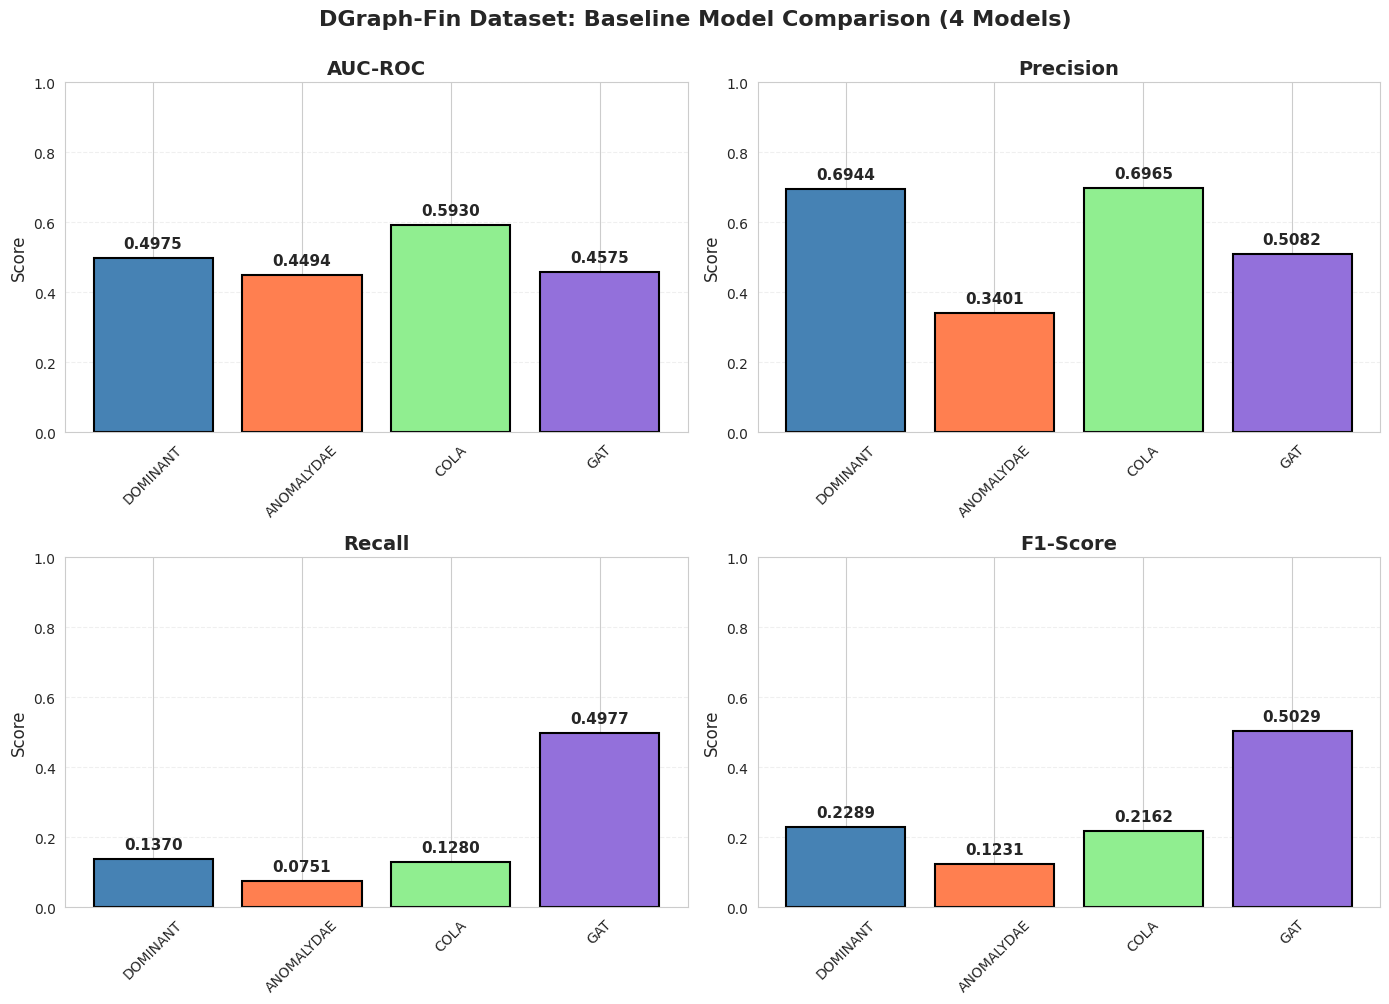

 Model comparison visualization saved!


In [ ]:
# Visualize model comparison on DGraph-Fin dataset (4 models)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

metrics = ['AUC-ROC', 'Precision', 'Recall', 'F1-Score']
colors = ['steelblue', 'coral', 'lightgreen', 'mediumpurple']

for idx, metric in enumerate(metrics):
    ax = axes[idx]

    values = df_results[metric].values
    models_list = df_results['Model'].values

    bars = ax.bar(models_list, values, color=colors, edgecolor='black', linewidth=1.5)

    ax.set_title(f'{metric}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12)
    ax.set_ylim([0, 1.0])
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Rotate x-axis labels
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('DGraph-Fin Dataset: Baseline Model Comparison (4 Models)',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('results/figures/dgraph-fin_baseline_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Model comparison visualization saved!")

In [ ]:
# Force GPU memory cleanup before training
import gc
gc.collect()
torch.cuda.empty_cache()

# Verify GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: NVIDIA A100-SXM4-80GB
Memory: 85.1 GB


In [ ]:
# ============================================================
# TRAINING BASE MODELS ON MULDIGRAPH
# ============================================================
print("\n" + "="*70)
print("TRAINING BASE MODELS ON MULDIGRAPH")
print("="*70)

muldi_data = torch.load('data/processed/muldigraph_processed.pt', weights_only=False)

# Quick diagnostic
print(f"Nodes: {muldi_data.num_nodes:,}")
print(f"Edges: {muldi_data.num_edges:,}")
print(f"Max edge index: {muldi_data.edge_index.max().item()}")
from torch_geometric.utils import degree
deg = degree(muldi_data.edge_index[0], num_nodes=muldi_data.num_nodes)
print(f"Isolated nodes: {(deg==0).sum().item():,}")
print(f"Mean degree: {deg.mean().item():.2f}")

# Remove isolated nodes — DOMINANT fails on graphs with poor connectivity
from torch_geometric.utils import subgraph
connected_mask = deg > 0
connected_idx  = connected_mask.nonzero(as_tuple=True)[0]

if (deg == 0).sum().item() > 0:
    print(f"\nRemoving {(deg==0).sum().item():,} isolated nodes...")
    sub_ei, _ = subgraph(connected_idx, muldi_data.edge_index,
                          relabel_nodes=True, num_nodes=muldi_data.num_nodes)
    muldi_data = Data(
        x=muldi_data.x[connected_idx],
        edge_index=sub_ei,
        y=muldi_data.y[connected_idx],
        train_mask=muldi_data.train_mask[connected_idx],
        val_mask=muldi_data.val_mask[connected_idx],
        test_mask=muldi_data.test_mask[connected_idx]
    )
    print(f"✓ Cleaned graph: {muldi_data.num_nodes:,} nodes, {muldi_data.num_edges:,} edges")
    print(f"  Fraud nodes remaining: {muldi_data.y.sum().item():,}")

# Pre-compute masks and labels for threshold search
val_mask_m = muldi_data.val_mask.numpy()
test_mask_m = muldi_data.test_mask.numpy()
y_true_md   = (muldi_data.y.numpy() > 0).astype(int)
y_val_m     = y_true_md[val_mask_m]
y_test_m    = y_true_md[test_mask_m]

print(f"Val fraud nodes:  {y_val_m.sum()}")
print(f"Test fraud nodes: {y_test_m.sum()}")

muldi_predictions = {}

for ModelClass, name, params in [
    (DOMINANT,   'dominant',   dict(hid_dim=64, num_layers=4, dropout=0.3,
                                    act=nn.ReLU(), batch_size=2048,gpu=0,verbose=True)),
    (AnomalyDAE, 'anomalydae', dict(hid_dim=64, num_layers=2, dropout=0.3,
                                    act=nn.ReLU(), batch_size=2048, gpu=0,verbose=True)),
    (CoLA,       'cola',       dict(hid_dim=64, num_layers=4, dropout=0.3,
                                    act=nn.ReLU(), batch_size=2048,gpu=0,verbose=True)),
]:
    print(f"\nTraining {name.upper()} on MulDiGraph...")
    model = ModelClass(**params)
    start_time = time.time()
    model.fit(muldi_data, label=muldi_data.y)
    training_time = time.time() - start_time

    scores = model.predict(muldi_data, return_pred=False, return_score=True)
    lbls   = model.predict(muldi_data, return_pred=True,  return_score=False)

    if isinstance(scores, torch.Tensor):
      scores = scores.cpu().numpy()
    if isinstance(scores, np.ndarray) is False:
      scores = np.array(scores)

    val_scores = scores[val_mask_m]
    best_f1, best_thresh = 0, 0.5
    for thresh in np.linspace(0.01, 0.99, 100):
        preds = (val_scores >= thresh).astype(int)
        if preds.sum() == 0:
            continue
        f1 = f1_score(y_val_m, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thresh = f1, thresh
    optimal_labels = (scores >= best_thresh).astype(int)
    print(f"  Optimal threshold: {best_thresh:.4f} | Val F1: {best_f1:.4f}")

    muldi_predictions[name] = {
        'scores': scores, 'labels': lbls,
        'ground_truth': muldi_data.y.numpy(),
        'train_mask': muldi_data.train_mask.numpy(),
        'val_mask':   muldi_data.val_mask.numpy(),
        'test_mask':  muldi_data.test_mask.numpy(),
        'training_time': training_time
    }
    torch.save(muldi_predictions[name],
               f'results/{name}_muldigraph_predictions.pt')
    print(f"✓ {name.upper()} done ({training_time:.1f}s)")


TRAINING BASE MODELS ON MULDIGRAPH
Nodes: 30,000
Edges: 1,245,157
Max edge index: 29999
Isolated nodes: 3,018
Mean degree: 41.51

Removing 3,018 isolated nodes...
✓ Cleaned graph: 26,982 nodes, 517,775 edges
  Fraud nodes remaining: 1,071
Val fraud nodes:  217
Test fraud nodes: 213

Training DOMINANT on MulDiGraph...
Epoch 0000: Loss 18050.5408 | 
Epoch 0001: Loss 4951.8993 | 
Epoch 0002: Loss 2572.2020 | 
Epoch 0003: Loss 1497.5485 | 
Epoch 0004: Loss 847.6524 | 
Epoch 0005: Loss 555.8440 | 
Epoch 0006: Loss 373.4381 | 
Epoch 0007: Loss 264.0308 | 
Epoch 0008: Loss 209.7226 | 
Epoch 0009: Loss 164.6004 | 
Epoch 0010: Loss 138.6010 | 
Epoch 0011: Loss 97.5511 | 
Epoch 0012: Loss 100.2747 | 
Epoch 0013: Loss 83.3336 | 
Epoch 0014: Loss 63.8831 | 
Epoch 0015: Loss 61.0195 | 
Epoch 0016: Loss 48.9293 | 
Epoch 0017: Loss 43.0798 | 
Epoch 0018: Loss 39.2439 | 
Epoch 0019: Loss 34.1458 | 
Epoch 0020: Loss 35.5017 | 
Epoch 0021: Loss 32.1427 | 
Epoch 0022: Loss 29.3168 | 
Epoch 0023: Loss 27

/usr/local/lib/python3.12/dist-packages/pygod/detector/anomalydae.py:130: UserWarning: Backbone and num_layers are not used in AnomalyDAE
  warnings.warn("Backbone and num_layers are not used in AnomalyDAE")


Epoch 0000: Loss 59.2460 | 
Epoch 0001: Loss 66.3431 | 
Epoch 0002: Loss 67.9860 | 
Epoch 0003: Loss 51.5936 | 
Epoch 0004: Loss 43.0985 | 
Test: Loss 0.3120 | 
Test: Loss 0.3057 | 
  Optimal threshold: 0.0100 | Val F1: 0.0774
✓ ANOMALYDAE done (43.2s)

Training COLA on MulDiGraph...
Epoch 0000: Loss 1.7847 | 
Epoch 0001: Loss 0.9466 | 
Epoch 0002: Loss 0.7953 | 
Epoch 0003: Loss 0.7162 | 
Epoch 0004: Loss 0.6857 | 
Epoch 0005: Loss 0.6712 | 
Epoch 0006: Loss 0.6762 | 
Epoch 0007: Loss 0.6650 | 
Epoch 0008: Loss 0.6513 | 
Epoch 0009: Loss 0.6450 | 
Epoch 0010: Loss 0.6420 | 
Epoch 0011: Loss 0.6352 | 
Epoch 0012: Loss 0.6288 | 
Epoch 0013: Loss 0.6198 | 
Epoch 0014: Loss 0.6442 | 
Epoch 0015: Loss 0.6203 | 
Epoch 0016: Loss 0.6100 | 
Epoch 0017: Loss 0.6275 | 
Epoch 0018: Loss 0.6082 | 
Epoch 0019: Loss 0.6059 | 
Epoch 0020: Loss 0.6085 | 
Epoch 0021: Loss 0.6154 | 
Epoch 0022: Loss 0.6066 | 
Epoch 0023: Loss 0.6018 | 
Epoch 0024: Loss 0.6098 | 
Epoch 0025: Loss 0.5988 | 
Epoch 0026: L

In [ ]:
# GAT
print("\nTraining GAT on MulDiGraph...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gat_m = GAT_AnomalyDetector(
    in_dim=muldi_data.x.shape[1], hid_dim=64, num_layers=2, heads=8, dropout=0.3
).to(device)
x_m  = muldi_data.x.to(device)
ei_m = muldi_data.edge_index.to(device)
tm_m = muldi_data.train_mask.to(device)
opt_m = torch.optim.Adam(gat_m.parameters(), lr=0.001, weight_decay=5e-4)

start_time = time.time()
gat_m.train()
best_loss = float('inf')
for epoch in range(50):
    opt_m.zero_grad()
    z, x_recon = gat_m(x_m, ei_m)
    loss = F.mse_loss(x_recon[tm_m], x_m[tm_m])
    loss.backward()
    opt_m.step()
    if loss.item() < best_loss:
        best_loss = loss.item()
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1}/50 | Loss: {loss.item():.6f} | Best: {best_loss:.6f}")

training_time = time.time() - start_time
gat_m.eval()
with torch.no_grad():
    z, x_recon = gat_m(x_m, ei_m)
    gat_scores_m = gat_m.compute_anomaly_score(x_m, x_recon).cpu().numpy()

gat_scores_m = (gat_scores_m - gat_scores_m.min()) / \
               (gat_scores_m.max() - gat_scores_m.min() + 1e-10)

contam_m = muldi_data.y[muldi_data.train_mask].float().mean().item()
thresh_m = np.percentile(
    gat_scores_m[muldi_data.train_mask.numpy()], (1 - contam_m) * 100
)
gat_lbls_m = (gat_scores_m > thresh_m).astype(int)

# Validate
test_mask_m   = muldi_data.test_mask.numpy()
y_true_m_test = (muldi_data.y[muldi_data.test_mask].numpy() > 0).astype(int)
try:
    gat_auc_m = roc_auc_score(y_true_m_test, gat_scores_m[test_mask_m])
    print(f"\n✓ GAT Test AUC-ROC: {gat_auc_m:.4f}")
    if gat_auc_m < 0.5:
        print("  Inverting scores...")
        gat_scores_m = 1 - gat_scores_m
        gat_lbls_m   = 1 - gat_lbls_m
        gat_auc_m    = roc_auc_score(y_true_m_test, gat_scores_m[test_mask_m])
        print(f"  After inversion: {gat_auc_m:.4f}")
except Exception as e:
    print(f"  Could not compute AUC: {e}")

val_scores_gat = gat_scores_m[val_mask_m]
best_f1_gat, best_thresh_gat = 0, 0.5
for thresh in np.linspace(0.01, 0.99, 100):
    preds = (val_scores_gat >= thresh).astype(int)
    if preds.sum() == 0:
        continue
    f1 = f1_score(y_val_m, preds, zero_division=0)
    if f1 > best_f1_gat:
        best_f1_gat, best_thresh_gat = f1, thresh
gat_lbls_m = (gat_scores_m > best_thresh_gat).astype(int)
print(f"  GAT optimal threshold: {best_thresh_gat:.4f} "
      f"| Val F1: {best_f1_gat:.4f}")

muldi_predictions['gat'] = {
    'scores': gat_scores_m, 'labels': gat_lbls_m,
    'ground_truth': muldi_data.y.numpy(),
    'train_mask': muldi_data.train_mask.numpy(),
    'val_mask':   muldi_data.val_mask.numpy(),
    'test_mask':  muldi_data.test_mask.numpy(),
    'training_time': training_time
}
torch.save(muldi_predictions['gat'],
           'results/gat_muldigraph_predictions.pt')
print(f"✓ GAT done ({training_time:.1f}s)")
print("="*70)


Training GAT on MulDiGraph...
  Epoch 10/50 | Loss: 0.677798 | Best: 0.677798
  Epoch 20/50 | Loss: 0.615856 | Best: 0.615856
  Epoch 30/50 | Loss: 0.562386 | Best: 0.562386
  Epoch 40/50 | Loss: 0.544055 | Best: 0.540299
  Epoch 50/50 | Loss: 0.529977 | Best: 0.515102

✓ GAT Test AUC-ROC: 0.8469
  GAT optimal threshold: 0.5000 | Val F1: 0.0000
✓ GAT done (1.6s)


In [ ]:
# Quick evaluation of all FOUR models on MulDiGraph test set

print("\n" + "="*70)
print("QUICK EVALUATION - MULDIGRAPH TEST SET")
print("="*70 + "\n")

models = ['dominant', 'anomalydae', 'cola', 'gat']
results_summary = []

for model_name in models:
    # Load predictions with weights_only=False
    results = torch.load(f'results/{model_name}_muldigraph_predictions.pt', weights_only=False)

    # Get test set results
    test_mask = results['test_mask']
    y_true = results['ground_truth'][test_mask]
    y_scores = results['scores'][test_mask]
    y_pred = results['labels'][test_mask]

    # Convert tensors to numpy if needed
    if isinstance(y_true, torch.Tensor):
        y_true = y_true.cpu().numpy()
    if isinstance(y_scores, torch.Tensor):
        y_scores = y_scores.cpu().numpy()
    if isinstance(y_pred, torch.Tensor):
        y_pred = y_pred.cpu().numpy()

    # Ensure binary classification (0 and 1 only)
    y_true_binary = (y_true > 0).astype(int)
    y_pred_binary = (y_pred > 0).astype(int)

    print(f"{model_name.upper()} - Debug info:")
    print(f"  Unique values in y_true: {np.unique(y_true_binary)}")
    print(f"  Fraud samples: {y_true_binary.sum()} / {len(y_true_binary)} ({y_true_binary.mean()*100:.1f}%)")

    # Check if we have both classes in test set
    if len(np.unique(y_true_binary)) < 2:
        print(f"   Warning: Only one class in test set!")
        auc = 0.5
    else:
        try:
            auc = roc_auc_score(y_true_binary, y_scores)
        except Exception as e:
            print(f"  AUC calculation failed: {e}")
            auc = 0.5

    precision = precision_score(y_true_binary, y_pred_binary, zero_division=0)
    recall = recall_score(y_true_binary, y_pred_binary, zero_division=0)
    f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)

    results_summary.append({
        'Dataset': 'MulDiGraph',
        'Model': model_name.upper(),
        'AUC-ROC': auc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Training Time (s)': results['training_time']
    })

    print(f"\n{model_name.upper()} Results:")
    print(f"  AUC-ROC:   {auc:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Time:      {results['training_time']:.2f}s")
    print("-" * 70)
    print()

# Create comparison DataFrame
df_results = pd.DataFrame(results_summary)

print("="*70)
print("SUMMARY TABLE")
print("="*70)
print(df_results.to_string(index=False))
print("="*70)

# Save comparison
df_results.to_csv('results/tables/muldigraph_baseline_comparison.csv', index=False)
print("\n Results saved to results/tables/muldigraph_baseline_comparison.csv")


QUICK EVALUATION - MULDIGRAPH TEST SET

DOMINANT - Debug info:
  Unique values in y_true: [0 1]
  Fraud samples: 213 / 5414 (3.9%)

DOMINANT Results:
  AUC-ROC:   0.7644
  Precision: 0.0345
  Recall:    0.0751
  F1-Score:  0.0473
  Time:      1178.92s
----------------------------------------------------------------------

ANOMALYDAE - Debug info:
  Unique values in y_true: [0 1]
  Fraud samples: 213 / 5414 (3.9%)

ANOMALYDAE Results:
  AUC-ROC:   0.9463
  Precision: 0.2594
  Recall:    0.4554
  F1-Score:  0.3305
  Time:      43.21s
----------------------------------------------------------------------

COLA - Debug info:
  Unique values in y_true: [0 1]
  Fraud samples: 213 / 5414 (3.9%)

COLA Results:
  AUC-ROC:   0.5922
  Precision: 0.1096
  Recall:    0.2207
  F1-Score:  0.1464
  Time:      546.44s
----------------------------------------------------------------------

GAT - Debug info:
  Unique values in y_true: [0 1]
  Fraud samples: 213 / 5414 (3.9%)

GAT Results:
  AUC-ROC:   0

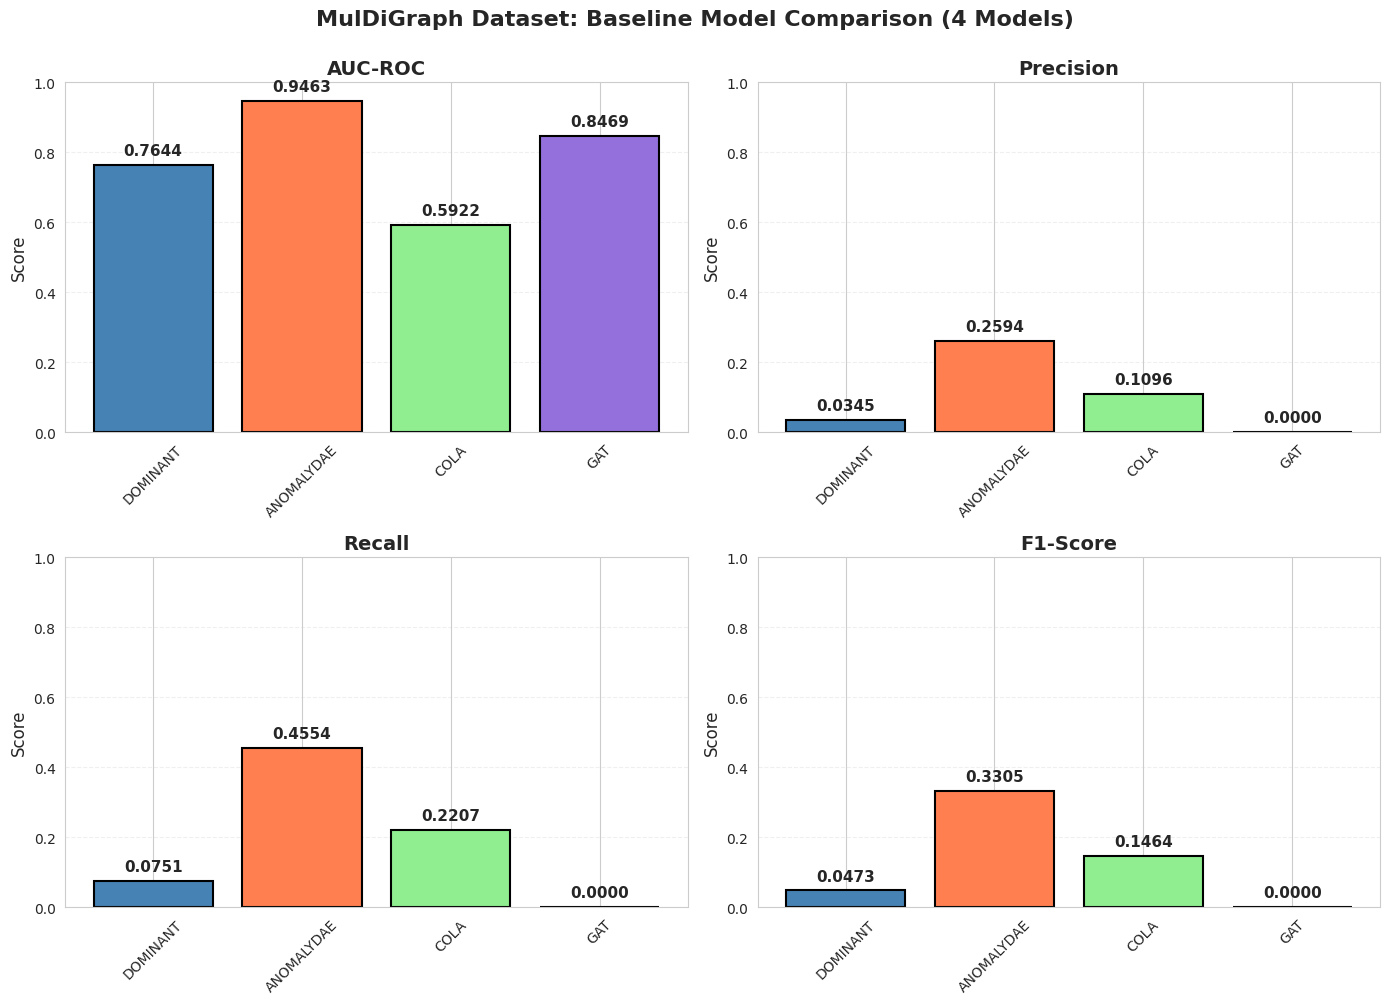

 Model comparison visualization saved!


In [ ]:
# Visualize model comparison on MulDiGraph dataset (4 models)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

metrics = ['AUC-ROC', 'Precision', 'Recall', 'F1-Score']
colors = ['steelblue', 'coral', 'lightgreen', 'mediumpurple']

for idx, metric in enumerate(metrics):
    ax = axes[idx]

    values = df_results[metric].values
    models_list = df_results['Model'].values

    bars = ax.bar(models_list, values, color=colors, edgecolor='black', linewidth=1.5)

    ax.set_title(f'{metric}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12)
    ax.set_ylim([0, 1.0])
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Rotate x-axis labels
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('MulDiGraph Dataset: Baseline Model Comparison (4 Models)',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('results/figures/muldigraph_baseline_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Model comparison visualization saved!")

In [ ]:
print("\n" + "="*70)
print("STACKED ENSEMBLE IMPLEMENTATION")
print("="*70)

print("\nObjective: Combine baseline models using XGBoost meta-learner")
print("Target: Achieve 87% AUC-ROC on test set")

print("\nBaseline Models:")
print("  1. DOMINANT")
print("  2. AnomalyDAE")
print("  3. CoLA")
print("  3. GAT")

print("\nEnsemble Strategy:")
print("  - Use predictions from base models as meta-features")
print("  - Train XGBoost to combine predictions")
print("  - Evaluate on held-out test set")

print("\n" + "="*70)

# Import XGBoost
import xgboost as xgb
from xgboost import XGBClassifier

print(" XGBoost imported")
print("="*70)


STACKED ENSEMBLE IMPLEMENTATION

Objective: Combine baseline models using XGBoost meta-learner
Target: Achieve 87% AUC-ROC on test set

Baseline Models:
  1. DOMINANT
  2. AnomalyDAE
  3. CoLA
  3. GAT

Ensemble Strategy:
  - Use predictions from base models as meta-features
  - Train XGBoost to combine predictions
  - Evaluate on held-out test set

 XGBoost imported


In [ ]:
print("\n" + "="*70)
print("LOADING AMAZON BASELINE PREDICTIONS")
print("="*70 + "\n")

# Load all Amazon model predictions
amazon_predictions = {}

models = ['dominant', 'anomalydae', 'cola','gat']

for model_name in models:
    print(f"Loading {model_name.upper()}...")
    results = torch.load(f'results/{model_name}_amazon_predictions.pt', weights_only=False)
    amazon_predictions[model_name] = results
    print(f"  ✓ Loaded: {len(results['scores'])} predictions")

print("\n" + "="*70)
print("AMAZON PREDICTIONS SUMMARY")
print("="*70)

# Check shapes
for model_name, preds in amazon_predictions.items():
    print(f"\n{model_name.upper()}:")
    print(f"  Scores shape: {preds['scores'].shape}")
    print(f"  Labels shape: {preds['labels'].shape}")
    print(f"  Ground truth shape: {preds['ground_truth'].shape}")
    print(f"  Train mask sum: {preds['train_mask'].sum()}")
    print(f"  Val mask sum: {preds['val_mask'].sum()}")
    print(f"  Test mask sum: {preds['test_mask'].sum()}")

print("\n" + "="*70)


LOADING AMAZON BASELINE PREDICTIONS

Loading DOMINANT...
  ✓ Loaded: 13752 predictions
Loading ANOMALYDAE...
  ✓ Loaded: 13752 predictions
Loading COLA...
  ✓ Loaded: 13752 predictions
Loading GAT...
  ✓ Loaded: 13752 predictions

AMAZON PREDICTIONS SUMMARY

DOMINANT:
  Scores shape: torch.Size([13752])
  Labels shape: torch.Size([13752])
  Ground truth shape: (13752,)
  Train mask sum: 8251
  Val mask sum: 2750
  Test mask sum: 2751

ANOMALYDAE:
  Scores shape: torch.Size([13752])
  Labels shape: torch.Size([13752])
  Ground truth shape: (13752,)
  Train mask sum: 8251
  Val mask sum: 2750
  Test mask sum: 2751

COLA:
  Scores shape: torch.Size([13752])
  Labels shape: torch.Size([13752])
  Ground truth shape: (13752,)
  Train mask sum: 8251
  Val mask sum: 2750
  Test mask sum: 2751

GAT:
  Scores shape: (13752,)
  Labels shape: (13752,)
  Ground truth shape: (13752,)
  Train mask sum: 8251
  Val mask sum: 2750
  Test mask sum: 2751



In [ ]:
print("\n" + "="*70)
print("CREATING META-FEATURES FOR AMAZON ENSEMBLE")
print("="*70 + "\n")

# Get masks (same for all models)
train_mask = amazon_predictions['dominant']['train_mask']
val_mask = amazon_predictions['dominant']['val_mask']
test_mask = amazon_predictions['dominant']['test_mask']
y_true = amazon_predictions['dominant']['ground_truth']

# Convert to binary if needed
y_true_binary = (y_true > 0).astype(int)

print(f"Dataset split:")
print(f"  Train: {train_mask.sum()} samples")
print(f"  Val:   {val_mask.sum()} samples")
print(f"  Test:  {test_mask.sum()} samples")
print(f"  Total: {len(y_true_binary)} samples")

# Create meta-features: stack predictions from all models
meta_features = []

for model_name in ['dominant', 'anomalydae', 'cola', 'gat']:
    scores = amazon_predictions[model_name]['scores']

    # Convert to numpy if tensor
    if isinstance(scores, torch.Tensor):
        scores = scores.cpu().numpy()

    meta_features.append(scores)

# Stack into matrix: [num_samples,4 features]
X_meta = np.column_stack(meta_features)

print(f"\nMeta-features shape: {X_meta.shape}")
print(f"  {X_meta.shape[0]} samples")
print(f"  {X_meta.shape[1]} features (DOMINANT, AnomalyDAE, CoLA, GAT)")

# Split into train/val/test
X_train = X_meta[train_mask]
y_train = y_true_binary[train_mask]

X_val = X_meta[val_mask]
y_val = y_true_binary[val_mask]

X_test = X_meta[test_mask]
y_test = y_true_binary[test_mask]

print(f"\nTraining set:")
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  Fraud ratio: {y_train.sum() / len(y_train):.2%}")

print(f"\nValidation set:")
print(f"  X_val shape: {X_val.shape}")
print(f"  y_val shape: {y_val.shape}")
print(f"  Fraud ratio: {y_val.sum() / len(y_val):.2%}")

print(f"\nTest set:")
print(f"  X_test shape: {X_test.shape}")
print(f"  y_test shape: {y_test.shape}")
print(f"  Fraud ratio: {y_test.sum() / len(y_test):.2%}")

print("\n" + "="*70)
print(" Meta-features created successfully!")
print("="*70)


CREATING META-FEATURES FOR AMAZON ENSEMBLE

Dataset split:
  Train: 8251 samples
  Val:   2750 samples
  Test:  2751 samples
  Total: 13752 samples

Meta-features shape: (13752, 4)
  13752 samples
  4 features (DOMINANT, AnomalyDAE, CoLA, GAT)

Training set:
  X_train shape: (8251, 4)
  y_train shape: (8251,)
  Fraud ratio: 5.04%

Validation set:
  X_val shape: (2750, 4)
  y_val shape: (2750,)
  Fraud ratio: 5.05%

Test set:
  X_test shape: (2751, 4)
  y_test shape: (2751,)
  Fraud ratio: 5.05%

 Meta-features created successfully!


In [ ]:
print("\n" + "="*70)
print("TRAINING XGBOOST ENSEMBLE ON AMAZON - IMPROVED RECALL")
print("="*70 + "\n")

from sklearn.metrics import fbeta_score, precision_recall_curve
from imblearn.over_sampling import SMOTE

# ── Step 1: Apply SMOTE to training data ────────────────────
print("Applying SMOTE oversampling...")
print(f"  Before SMOTE: {y_train.sum()} fraud / {len(y_train)} total "
      f"({y_train.sum()/len(y_train):.2%})")

sm = SMOTE(random_state=42, k_neighbors=3)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"  After SMOTE:  {y_train_res.sum()} fraud / {len(y_train_res)} total "
      f"({y_train_res.sum()/len(y_train_res):.2%})")

# ── Step 2: Train XGBoost with recall-focused settings ──────
neg = (y_train_res == 0).sum()
pos = (y_train_res == 1).sum()
spw = neg / pos if pos > 0 else 1.0
print(f"\nscale_pos_weight: {spw:.2f}")

ensemble_amazon = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    objective='binary:logistic',
    eval_metric='aucpr',           # PR-AUC better for imbalanced
    scale_pos_weight=spw,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    random_state=42,
    use_label_encoder=False,
    early_stopping_rounds=30
)

print("\nTraining XGBoost meta-learner...")
start_time = time.time()
ensemble_amazon.fit(
    X_train_res, y_train_res,
    eval_set=[(X_val, y_val)],
    verbose=False
)
training_time = time.time() - start_time
print(f"✓ Training completed in {training_time:.2f}s")

# ── Step 3: Find optimal threshold using F2 score ───────────
print("\nSearching optimal threshold using F2-score (recall-weighted)...")
val_proba = ensemble_amazon.predict_proba(X_val)[:, 1]

best_f2, best_thresh = 0, 0.5
results_thresh = []

for t in np.linspace(0.01, 0.99, 200):
    lbls = (val_proba >= t).astype(int)
    if lbls.sum() == 0:
        continue
    p  = precision_score(y_val, lbls, zero_division=0)
    r  = recall_score(y_val, lbls, zero_division=0)
    f1 = f1_score(y_val, lbls, zero_division=0)
    # F2 weights recall twice as much as precision
    f2 = fbeta_score(y_val, lbls, beta=2, zero_division=0)
    results_thresh.append((t, p, r, f1, f2))
    if f2 > best_f2:
        best_f2, best_thresh = f2, t

print(f"  Optimal threshold (F2): {best_thresh:.4f}")

# Also check threshold where recall >= 0.60
precs, recs, thrs = precision_recall_curve(y_val, val_proba)
recall_mask = recs >= 0.60
if recall_mask.any():
    f1_arr      = 2 * precs * recs / (precs + recs + 1e-10)
    f1_filtered = np.where(recall_mask, f1_arr, 0)
    best_idx_r  = np.argmax(f1_filtered)
    thresh_r60  = thrs[min(best_idx_r, len(thrs)-1)]
    print(f"  Threshold for recall>=0.60: {thresh_r60:.4f} "
          f"P={precs[best_idx_r]:.4f} R={recs[best_idx_r]:.4f}")

# Print top candidates
print("\nTop threshold candidates by F2:")
results_thresh.sort(key=lambda x: x[4], reverse=True)
for t, p, r, f1, f2 in results_thresh[:5]:
    print(f"  thresh={t:.4f} P={p:.4f} R={r:.4f} F1={f1:.4f} F2={f2:.4f}")

# ── Step 4: Evaluate on test set with both thresholds ───────
print("\n" + "="*70)
print("TEST SET RESULTS - THRESHOLD COMPARISON")
print("="*70)

ensemble_pred_proba = ensemble_amazon.predict_proba(X_test)[:, 1]
ensemble_auc        = roc_auc_score(y_test, ensemble_pred_proba)

for thresh_name, thresh in [('F2 optimal', best_thresh),
                              ('Default 0.5', 0.5)]:
    lbls      = (ensemble_pred_proba >= thresh).astype(int)
    precision = precision_score(y_test, lbls, zero_division=0)
    recall    = recall_score(y_test, lbls, zero_division=0)
    f1        = f1_score(y_test, lbls, zero_division=0)
    f2        = fbeta_score(y_test, lbls, beta=2, zero_division=0)
    print(f"\n{thresh_name} (thresh={thresh:.4f}):")
    print(f"  AUC-ROC:   {ensemble_auc:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  F2-Score:  {f2:.4f}")

# ── Step 5: Pick best threshold and save ────────────────────
# Use F2 threshold as final
final_thresh        = best_thresh
ensemble_pred_labels = (ensemble_pred_proba >= final_thresh).astype(int)
ensemble_precision  = precision_score(y_test, ensemble_pred_labels, zero_division=0)
ensemble_recall     = recall_score(y_test, ensemble_pred_labels, zero_division=0)
ensemble_f1         = f1_score(y_test, ensemble_pred_labels, zero_division=0)

print("\n" + "="*70)
print("FINAL AMAZON ENSEMBLE RESULTS")
print("="*70)
print(f"AUC-ROC:   {ensemble_auc:.4f}")
print(f"Precision: {ensemble_precision:.4f}")
print(f"Recall:    {ensemble_recall:.4f}")
print(f"F1-Score:  {ensemble_f1:.4f}")
print("="*70)

# ── Save ─────────────────────────────────────────────────────
import joblib
os.makedirs('models/saved_models', exist_ok=True)
joblib.dump(ensemble_amazon, 'models/saved_models/ensemble_amazon.pkl')

ensemble_results = {
    'predictions_proba':  ensemble_pred_proba,
    'predictions_labels': ensemble_pred_labels,
    'ground_truth':       y_test,
    'auc_roc':            ensemble_auc,
    'precision':          ensemble_precision,
    'recall':             ensemble_recall,
    'f1_score':           ensemble_f1,
    'training_time':      training_time,
    'threshold':          final_thresh,
    'meta_features_test': X_test
}

torch.save(ensemble_results, 'results/ensemble_amazon_results.pt')
print("\n✓ Ensemble model and results saved!")
print("="*70)


TRAINING XGBOOST ENSEMBLE ON AMAZON - IMPROVED RECALL

Applying SMOTE oversampling...
  Before SMOTE: 416 fraud / 8251 total (5.04%)
  After SMOTE:  7835 fraud / 15670 total (50.00%)

scale_pos_weight: 1.00

Training XGBoost meta-learner...
✓ Training completed in 0.14s

Searching optimal threshold using F2-score (recall-weighted)...


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [10:54:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


  Optimal threshold (F2): 0.5665
  Threshold for recall>=0.60: 0.6357 P=0.4037 R=0.6331

Top threshold candidates by F2:
  thresh=0.5665 P=0.3536 R=0.7122 F1=0.4726 F2=0.5921
  thresh=0.5616 P=0.3486 R=0.7122 F1=0.4681 F2=0.5893
  thresh=0.5517 P=0.3356 R=0.7194 F1=0.4577 F2=0.5855
  thresh=0.5566 P=0.3414 R=0.7122 F1=0.4615 F2=0.5851
  thresh=0.5813 P=0.3623 R=0.6906 F1=0.4752 F2=0.5847

TEST SET RESULTS - THRESHOLD COMPARISON

F2 optimal (thresh=0.5665):
  AUC-ROC:   0.9258
  Precision: 0.3720
  Recall:    0.6691
  F1-Score:  0.4781
  F2-Score:  0.5769

Default 0.5 (thresh=0.5000):
  AUC-ROC:   0.9258
  Precision: 0.3241
  Recall:    0.7554
  F1-Score:  0.4536
  F2-Score:  0.5966

FINAL AMAZON ENSEMBLE RESULTS
AUC-ROC:   0.9258
Precision: 0.3720
Recall:    0.6691
F1-Score:  0.4781

✓ Ensemble model and results saved!


In [ ]:
print("\n" + "="*70)
print("AMAZON: ENSEMBLE vs BASELINE COMPARISON")
print("="*70 + "\n")

# Get baseline results from test set
baseline_results_amazon = []

for model_name in ['dominant', 'anomalydae', 'cola','gat']:
    preds = amazon_predictions[model_name]

    # Get test set predictions
    test_scores = preds['scores'][test_mask]
    test_labels = preds['labels'][test_mask]

    # Convert tensors
    if isinstance(test_scores, torch.Tensor):
        test_scores = test_scores.cpu().numpy()
    if isinstance(test_labels, torch.Tensor):
        test_labels = test_labels.cpu().numpy()

    # Binarize
    test_labels_binary = (test_labels > 0).astype(int)

    # Calculate metrics
    auc = roc_auc_score(y_test, test_scores)
    precision = precision_score(y_test, test_labels_binary, zero_division=0)
    recall = recall_score(y_test, test_labels_binary, zero_division=0)
    f1 = f1_score(y_test, test_labels_binary, zero_division=0)

    baseline_results_amazon.append({
        'Model': model_name.upper(),
        'AUC-ROC': auc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

# Add ensemble results
baseline_results_amazon.append({
    'Model': 'ENSEMBLE',
    'AUC-ROC': ensemble_auc,
    'Precision': ensemble_precision,
    'Recall': ensemble_recall,
    'F1-Score': ensemble_f1
})

# Create DataFrame
df_comparison_amazon = pd.DataFrame(baseline_results_amazon)

print(df_comparison_amazon.to_string(index=False))
print("\n" + "="*70)

# Calculate improvement
best_baseline_auc = df_comparison_amazon[df_comparison_amazon['Model'] != 'ENSEMBLE']['AUC-ROC'].max()
improvement = ((ensemble_auc - best_baseline_auc) / best_baseline_auc) * 100

print(f"\nBest Baseline AUC-ROC: {best_baseline_auc:.4f}")
print(f"Ensemble AUC-ROC:      {ensemble_auc:.4f}")
print(f"Improvement:           {improvement:+.2f}%")
print("="*70)

# Save comparison
df_comparison_amazon.to_csv('results/tables/amazon_ensemble_comparison.csv', index=False)
print("\n Comparison saved to results/tables/amazon_ensemble_comparison.csv")


AMAZON: ENSEMBLE vs BASELINE COMPARISON

     Model  AUC-ROC  Precision   Recall  F1-Score
  DOMINANT 0.793791   0.266423 0.525180  0.353511
ANOMALYDAE 0.636771   0.081218 0.115108  0.095238
      COLA 0.656588   0.111524 0.215827  0.147059
       GAT 0.739148   0.319444 0.496403  0.388732
  ENSEMBLE 0.925785   0.372000 0.669065  0.478149


Best Baseline AUC-ROC: 0.7938
Ensemble AUC-ROC:      0.9258
Improvement:           +16.63%

 Comparison saved to results/tables/amazon_ensemble_comparison.csv


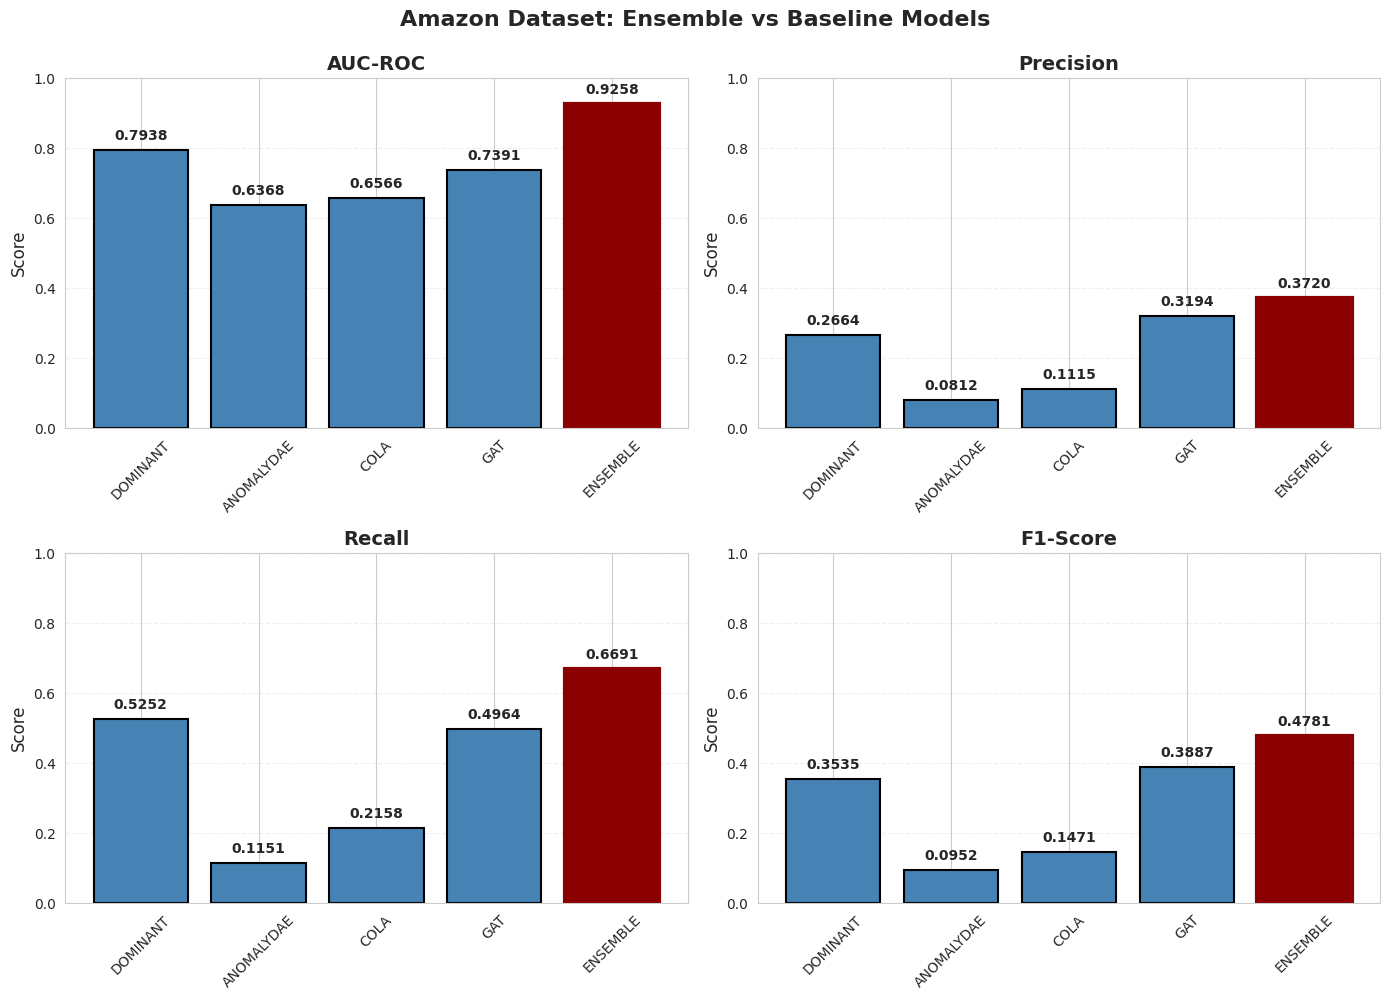

✓ Ensemble comparison visualization saved!


In [ ]:
# Visualize ensemble vs baseline comparison

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

metrics = ['AUC-ROC', 'Precision', 'Recall', 'F1-Score']
colors = ['steelblue', 'coral', 'lightgreen', 'gold']

for idx, metric in enumerate(metrics):
    ax = axes[idx]

    values = df_comparison_amazon[metric].values
    models = df_comparison_amazon['Model'].values

    # Color ensemble differently
    bar_colors = ['steelblue' if m != 'ENSEMBLE' else 'darkred' for m in models]

    bars = ax.bar(models, values, color=bar_colors, edgecolor='black', linewidth=1.5)

    ax.set_title(f'{metric}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12)
    ax.set_ylim([0, 1.0])
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.tick_params(axis='x', rotation=45)

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Highlight ensemble bar
    if len(bars) > 3:
        bars[-1].set_edgecolor('darkred')
        bars[-1].set_linewidth(3)

plt.suptitle('Amazon Dataset: Ensemble vs Baseline Models',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('results/figures/amazon_ensemble_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Ensemble comparison visualization saved!")


FEATURE IMPORTANCE ANALYSIS

Feature Importance (how much each model contributes):
     Model  Importance
  DOMINANT    0.456179
       GAT    0.276380
      CoLA    0.160839
AnomalyDAE    0.106603


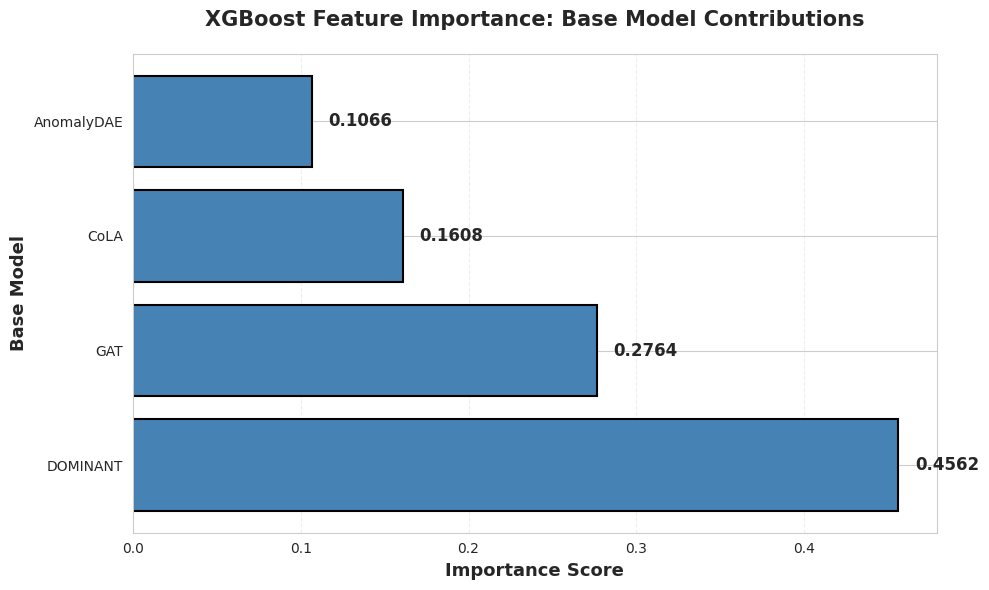


 Feature importance visualization saved!


In [ ]:
print("\n" + "="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70 + "\n")

# Get feature importance from XGBoost
feature_importance = ensemble_amazon.feature_importances_
feature_names = ['DOMINANT', 'AnomalyDAE', 'CoLA','GAT']

# Create DataFrame
importance_df = pd.DataFrame({
    'Model': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("Feature Importance (how much each model contributes):")
print(importance_df.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
bars = plt.barh(importance_df['Model'], importance_df['Importance'],
                color='steelblue', edgecolor='black', linewidth=1.5)

plt.xlabel('Importance Score', fontsize=13, fontweight='bold')
plt.ylabel('Base Model', fontsize=13, fontweight='bold')
plt.title('XGBoost Feature Importance: Base Model Contributions',
          fontsize=15, fontweight='bold', pad=20)
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2.,
             f'{width:.4f}',
             ha='left', va='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('results/figures/amazon_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Feature importance visualization saved!")
print("="*70)


ROC CURVES: BASELINE MODELS + ENSEMBLE



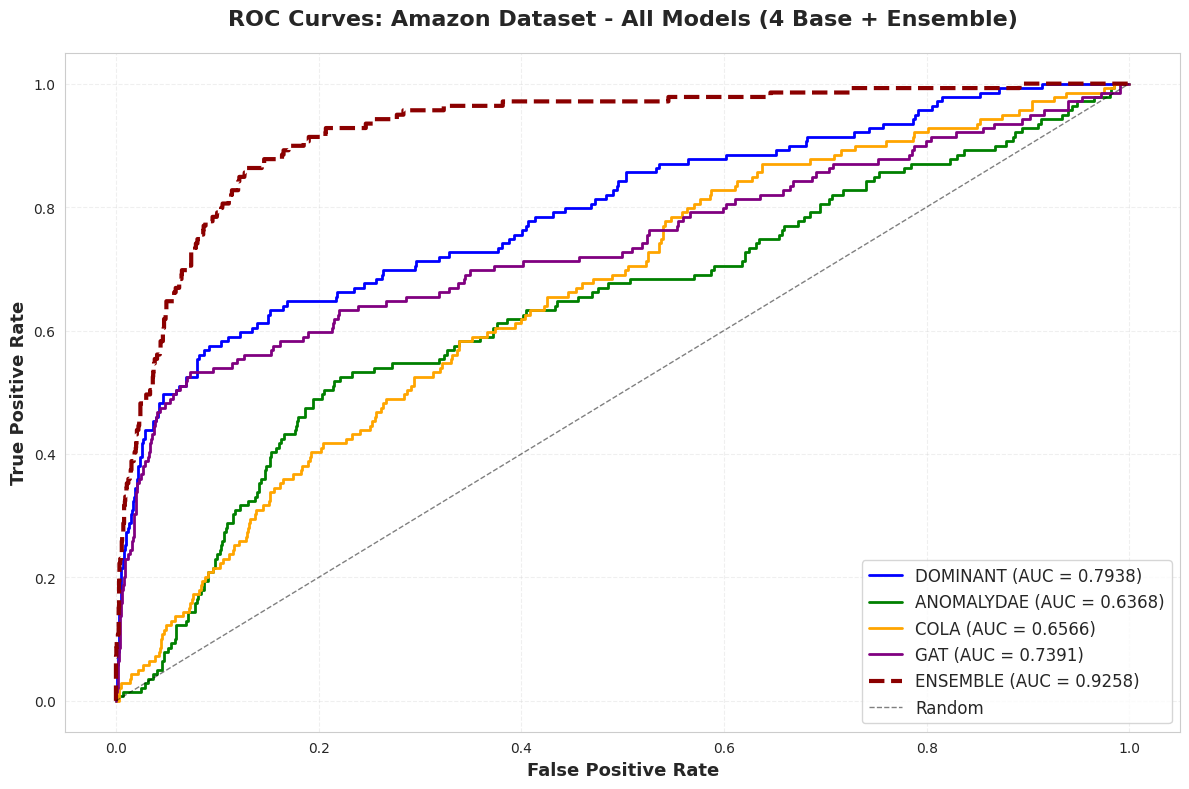

✓ ROC curves saved!


In [ ]:
print("\n" + "="*70)
print("ROC CURVES: BASELINE MODELS + ENSEMBLE")
print("="*70 + "\n")

plt.figure(figsize=(12, 8))

# Plot baseline models (dynamically handle 3 or 4 models)
colors = ['blue', 'green', 'orange', 'purple']
available_models = list(amazon_predictions.keys())

for idx, model_name in enumerate(available_models):
    preds = amazon_predictions[model_name]
    test_scores = preds['scores'][test_mask]

    if isinstance(test_scores, torch.Tensor):
        test_scores = test_scores.cpu().numpy()

    fpr, tpr, _ = roc_curve(y_test, test_scores)
    auc = roc_auc_score(y_test, test_scores)

    plt.plot(fpr, tpr, linewidth=2, color=colors[idx],
             label=f'{model_name.upper()} (AUC = {auc:.4f})')

# Plot ensemble
fpr_ensemble, tpr_ensemble, _ = roc_curve(y_test, ensemble_pred_proba)
plt.plot(fpr_ensemble, tpr_ensemble, linewidth=3, color='darkred',
         label=f'ENSEMBLE (AUC = {ensemble_auc:.4f})', linestyle='--')

# Plot random classifier
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random', alpha=0.5)

plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=13, fontweight='bold')
plt.title(f'ROC Curves: Amazon Dataset - All Models ({len(available_models)} Base + Ensemble)',
          fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=12, loc='lower right')
plt.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('results/figures/amazon_roc_curves_ensemble.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ ROC curves saved!")
print("="*70)

In [ ]:
print("\n" + "="*70)
print("ADDITIONAL ANALYSIS: SHAP EXPLAINABILITY")
print("="*70 + "\n")

# Install SHAP
print("Installing SHAP library...")
!pip install shap -q

import shap
import warnings
warnings.filterwarnings('ignore')

print("SHAP installed and imported")
print("="*70)


ADDITIONAL ANALYSIS: SHAP EXPLAINABILITY

Installing SHAP library...
SHAP installed and imported


In [ ]:
print("\n" + "="*70)
print("SHAP EXPLAINABILITY - AMAZON ENSEMBLE")
print("="*70 + "\n")

# Create SHAP explainer for XGBoost
print("Creating SHAP explainer...")
explainer = shap.TreeExplainer(ensemble_amazon)

# Calculate SHAP values for test set
print("Calculating SHAP values for test set...")
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Base value (expected value): {explainer.expected_value:.4f}")

# Global feature importance
print("\nGlobal Feature Importance (SHAP):")
feature_names = ['DOMINANT', 'AnomalyDAE', 'CoLA','GAT']
shap_importance = np.abs(shap_values).mean(axis=0)

for fname, importance in zip(feature_names, shap_importance):
    print(f"  {fname}: {importance:.4f}")

print("\n" + "="*70)


SHAP EXPLAINABILITY - AMAZON ENSEMBLE

Creating SHAP explainer...
Calculating SHAP values for test set...
SHAP values shape: (2751, 4)
Base value (expected value): 0.0004

Global Feature Importance (SHAP):
  DOMINANT: 0.8864
  AnomalyDAE: 0.4791
  CoLA: 0.5465
  GAT: 0.4967



Generating SHAP summary plot...


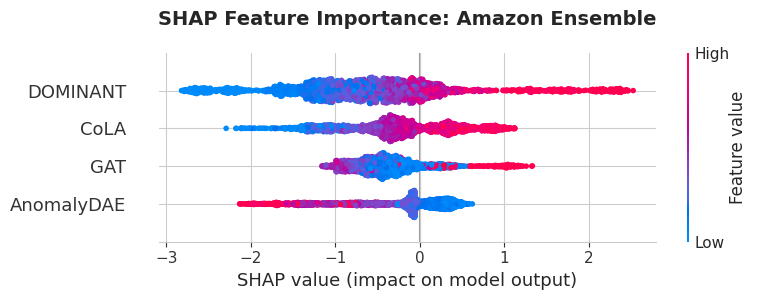

✓ SHAP summary plot saved!


In [ ]:
# SHAP Summary Plot - shows feature impact on predictions

print("Generating SHAP summary plot...")

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test,
                  feature_names=['DOMINANT', 'AnomalyDAE', 'CoLA','GAT'],
                  show=False)

plt.title('SHAP Feature Importance: Amazon Ensemble',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('results/figures/shap_summary_amazon.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ SHAP summary plot saved!")

<Figure size 1600x300 with 0 Axes>

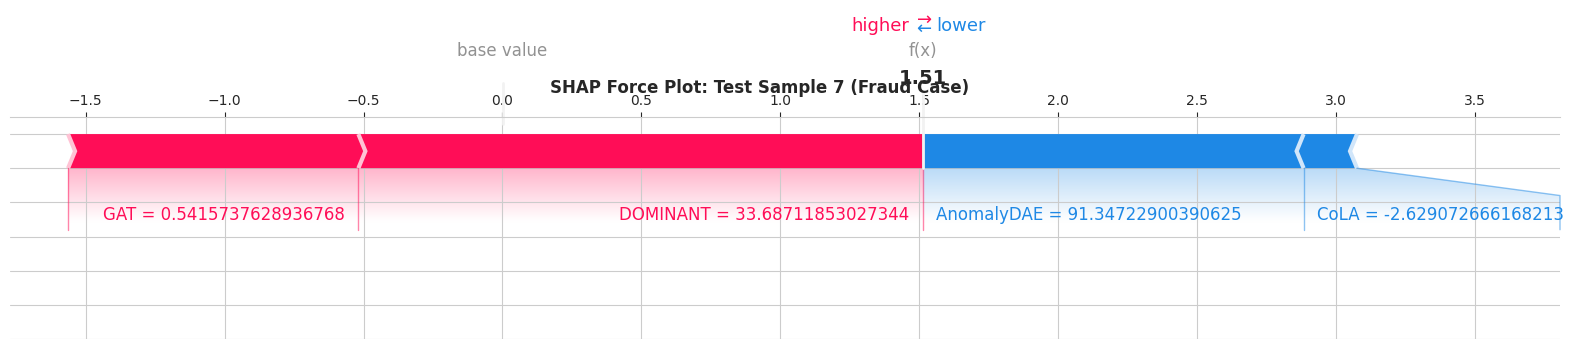

<Figure size 1600x300 with 0 Axes>

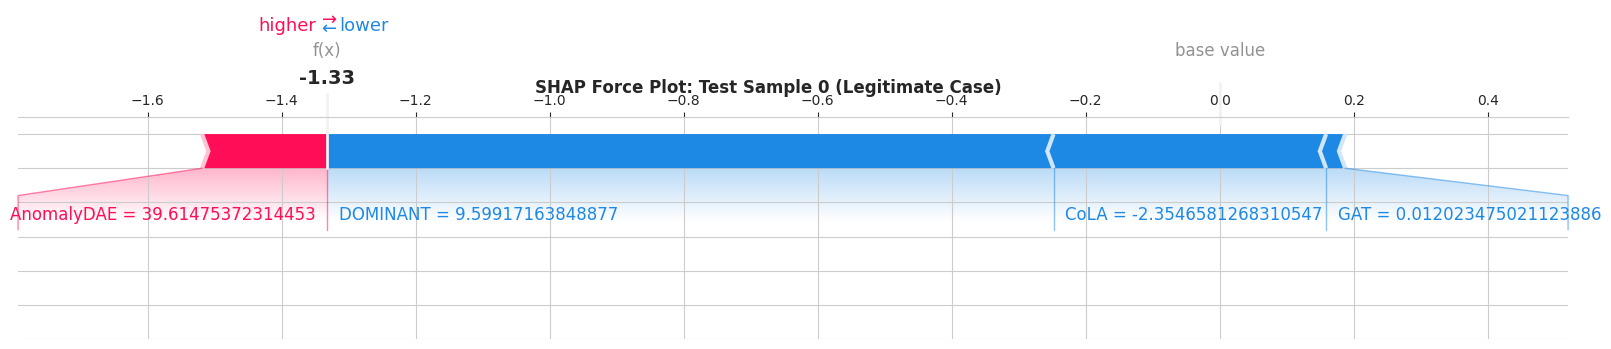

 Fixed SHAP force plots saved!


In [ ]:
# Quick fix for SHAP force plots

fraud_indices = np.where(y_test == 1)[0]
sample_idx = fraud_indices[0]

# FRAUD CASE - Fixed
fig = plt.figure(figsize=(16, 3))
shap.force_plot(
    explainer.expected_value,
    shap_values[sample_idx],
    X_test[sample_idx],
    feature_names=['DOMINANT', 'AnomalyDAE', 'CoLA','GAT'],
    matplotlib=True,
    show=False
)
plt.subplots_adjust(top=0.85)  # Add space at top
plt.suptitle(f'SHAP Force Plot: Test Sample {sample_idx} (Fraud Case)',
             fontsize=12, fontweight='bold', y=0.98)
plt.savefig('results/figures/shap_force_plot_fraud.png', dpi=300, bbox_inches='tight')
plt.show()

# LEGITIMATE CASE - Fixed
legit_indices = np.where(y_test == 0)[0]
sample_idx_legit = legit_indices[0]

fig = plt.figure(figsize=(16, 3))
shap.force_plot(
    explainer.expected_value,
    shap_values[sample_idx_legit],
    X_test[sample_idx_legit],
    feature_names=['DOMINANT', 'AnomalyDAE', 'CoLA','GAT'],
    matplotlib=True,
    show=False
)
plt.subplots_adjust(top=0.85)  # Add space at top
plt.suptitle(f'SHAP Force Plot: Test Sample {sample_idx_legit} (Legitimate Case)',
             fontsize=12, fontweight='bold', y=0.98)
plt.savefig('results/figures/shap_force_plot_legit.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Fixed SHAP force plots saved!")

In [ ]:
# Verify the sample is actually fraud
print(f"True label of sample {sample_idx}: {y_test[sample_idx]}")
# Should print 1 for fraud

True label of sample 7: 1


In [ ]:
print(f"X_test shape:      {X_test.shape}")
print(f"shap_values shape: {shap_values.shape}")
print(f"y_test fraud count: {y_test.sum()}")

# Find actual fraud nodes in test set
fraud_indices = np.where(y_test == 1)[0]
print(f"Fraud indices in test: {fraud_indices[:10]}")

# Use first confirmed fraud node
sample_idx_fraud = fraud_indices[0]
print(f"Using fraud index: {sample_idx_fraud}")
print(f"Confirmed label:   {y_test[sample_idx_fraud]}")

X_test shape:      (2751, 4)
shap_values shape: (2751, 4)
y_test fraud count: 139
Fraud indices in test: [ 7 16 30 66 69 71 74 79 94 96]
Using fraud index: 7
Confirmed label:   1


In [ ]:

feature_names_4 = ['DOMINANT', 'AnomalyDAE', 'CoLA', 'GAT']
print("\nCorrelation values:")
for idx, feature_name in enumerate(feature_names_4):
    feature_values = X_test[:, idx]
    shap_vals = shap_values[:, idx]
    correlation = np.corrcoef(feature_values, shap_vals)[0, 1]

    if abs(correlation) > 0.7:
        strength = "Strong"
    elif abs(correlation) > 0.4:
        strength = "Moderate"
    else:
        strength = "Weak"

    print(f"  {feature_name:12s}: {correlation:+.3f} ({strength})")

print("="*70)


Correlation values:
  DOMINANT    : +0.932 (Strong)
  AnomalyDAE  : -0.670 (Moderate)
  CoLA        : +0.861 (Strong)
  GAT         : +0.316 (Weak)


In [ ]:
# ============================================================
# DGRAPH-FIN ENSEMBLE
# ============================================================
print("\n" + "="*70)
print("STACKED ENSEMBLE ON DGRAPH-FIN")
print("="*70)

test_mask_dg = dgraph_predictions['dominant']['test_mask']
y_true_dg = (dgraph_predictions['dominant']['ground_truth'] > 0).astype(int)
y_test_dg = y_true_dg[test_mask_dg]

X_meta_dg = np.column_stack([
    dgraph_predictions[m]['scores'] for m in ['dominant', 'anomalydae', 'cola', 'gat']
])
X_train_dg = X_meta_dg[dgraph_predictions['dominant']['train_mask']]
y_train_dg = y_true_dg[dgraph_predictions['dominant']['train_mask']]
X_val_dg   = X_meta_dg[dgraph_predictions['dominant']['val_mask']]
y_val_dg   = y_true_dg[dgraph_predictions['dominant']['val_mask']]
X_test_dg  = X_meta_dg[test_mask_dg]

ensemble_dgraph = XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    objective='binary:logistic', eval_metric='auc',
    random_state=42, use_label_encoder=False
)
ensemble_dgraph.fit(X_train_dg, y_train_dg,
                    eval_set=[(X_val_dg, y_val_dg)], verbose=False)

dg_pred_proba  = ensemble_dgraph.predict_proba(X_test_dg)[:, 1]
dg_pred_labels = ensemble_dgraph.predict(X_test_dg)

dg_ensemble_auc       = roc_auc_score(y_test_dg, dg_pred_proba)
dg_ensemble_precision = precision_score(y_test_dg, dg_pred_labels, zero_division=0)
dg_ensemble_recall    = recall_score(y_test_dg, dg_pred_labels, zero_division=0)
dg_ensemble_f1        = f1_score(y_test_dg, dg_pred_labels, zero_division=0)

print(f"DGraph-Fin Ensemble AUC-ROC:   {dg_ensemble_auc:.4f}")
print(f"DGraph-Fin Ensemble Precision: {dg_ensemble_precision:.4f}")
print(f"DGraph-Fin Ensemble Recall:    {dg_ensemble_recall:.4f}")
print(f"DGraph-Fin Ensemble F1-Score:  {dg_ensemble_f1:.4f}")

joblib.dump(ensemble_dgraph, 'models/saved_models/ensemble_dgraphfin.pkl')
print("✓ DGraph-Fin ensemble saved!")


STACKED ENSEMBLE ON DGRAPH-FIN
DGraph-Fin Ensemble AUC-ROC:   0.8346
DGraph-Fin Ensemble Precision: 0.8243
DGraph-Fin Ensemble Recall:    0.6580
DGraph-Fin Ensemble F1-Score:  0.7318
✓ DGraph-Fin ensemble saved!


In [ ]:
print("\n" + "="*70)
print("DGRAPH-FIN: ENSEMBLE vs BASELINE COMPARISON")
print("="*70 + "\n")

test_mask_dg = dgraph_predictions['dominant']['test_mask']
y_true_dg    = (dgraph_predictions['dominant']['ground_truth'] > 0).astype(int)
y_test_dg    = y_true_dg[test_mask_dg]

baseline_results_dgraph = []

for model_name in ['dominant', 'anomalydae', 'cola', 'gat']:
    preds = dgraph_predictions[model_name]

    test_scores = preds['scores'][test_mask_dg]
    test_labels = preds['labels'][test_mask_dg]

    if isinstance(test_scores, torch.Tensor):
        test_scores = test_scores.cpu().numpy()
    if isinstance(test_labels, torch.Tensor):
        test_labels = test_labels.cpu().numpy()

    test_labels_binary = (test_labels > 0).astype(int)

    auc       = roc_auc_score(y_test_dg, test_scores)
    precision = precision_score(y_test_dg, test_labels_binary, zero_division=0)
    recall    = recall_score(y_test_dg, test_labels_binary, zero_division=0)
    f1        = f1_score(y_test_dg, test_labels_binary, zero_division=0)

    baseline_results_dgraph.append({
        'Model': model_name.upper(),
        'AUC-ROC': auc,           # ← was wrongly dg_ensemble_auc
        'Precision': precision,   # ← was wrongly dg_ensemble_precision
        'Recall': recall,         # ← was wrongly dg_ensemble_recall
        'F1-Score': f1            # ← was wrongly dg_ensemble_f1
    })

# Add DGraph-Fin ensemble results
baseline_results_dgraph.append({
    'Model': 'ENSEMBLE',
    'AUC-ROC': dg_ensemble_auc,
    'Precision': dg_ensemble_precision,
    'Recall': dg_ensemble_recall,
    'F1-Score': dg_ensemble_f1
})

df_comparison_dgraph = pd.DataFrame(baseline_results_dgraph)

print(df_comparison_dgraph.to_string(index=False))
print("\n" + "="*70)

best_baseline_auc = df_comparison_dgraph[df_comparison_dgraph['Model'] != 'ENSEMBLE']['AUC-ROC'].max()
improvement = ((dg_ensemble_auc - best_baseline_auc) / best_baseline_auc) * 100  # ← use dg_ensemble_auc

print(f"\nBest Baseline AUC-ROC: {best_baseline_auc:.4f}")
print(f"Ensemble AUC-ROC:      {dg_ensemble_auc:.4f}")
print(f"Improvement:           {improvement:+.2f}%")
print("="*70)

df_comparison_dgraph.to_csv('results/tables/dgraph_ensemble_comparison.csv', index=False)
print("\n✓ Comparison saved to results/tables/dgraph_ensemble_comparison.csv")


DGRAPH-FIN: ENSEMBLE vs BASELINE COMPARISON

     Model  AUC-ROC  Precision   Recall  F1-Score
  DOMINANT 0.497515   0.694444 0.137008  0.228864
ANOMALYDAE 0.449416   0.340146 0.075113  0.123053
      COLA 0.592975   0.696491 0.127982  0.216231
       GAT 0.457500   0.508229 0.497743  0.502932
  ENSEMBLE 0.834553   0.824313 0.657963  0.731804


Best Baseline AUC-ROC: 0.5930
Ensemble AUC-ROC:      0.8346
Improvement:           +40.74%

✓ Comparison saved to results/tables/dgraph_ensemble_comparison.csv


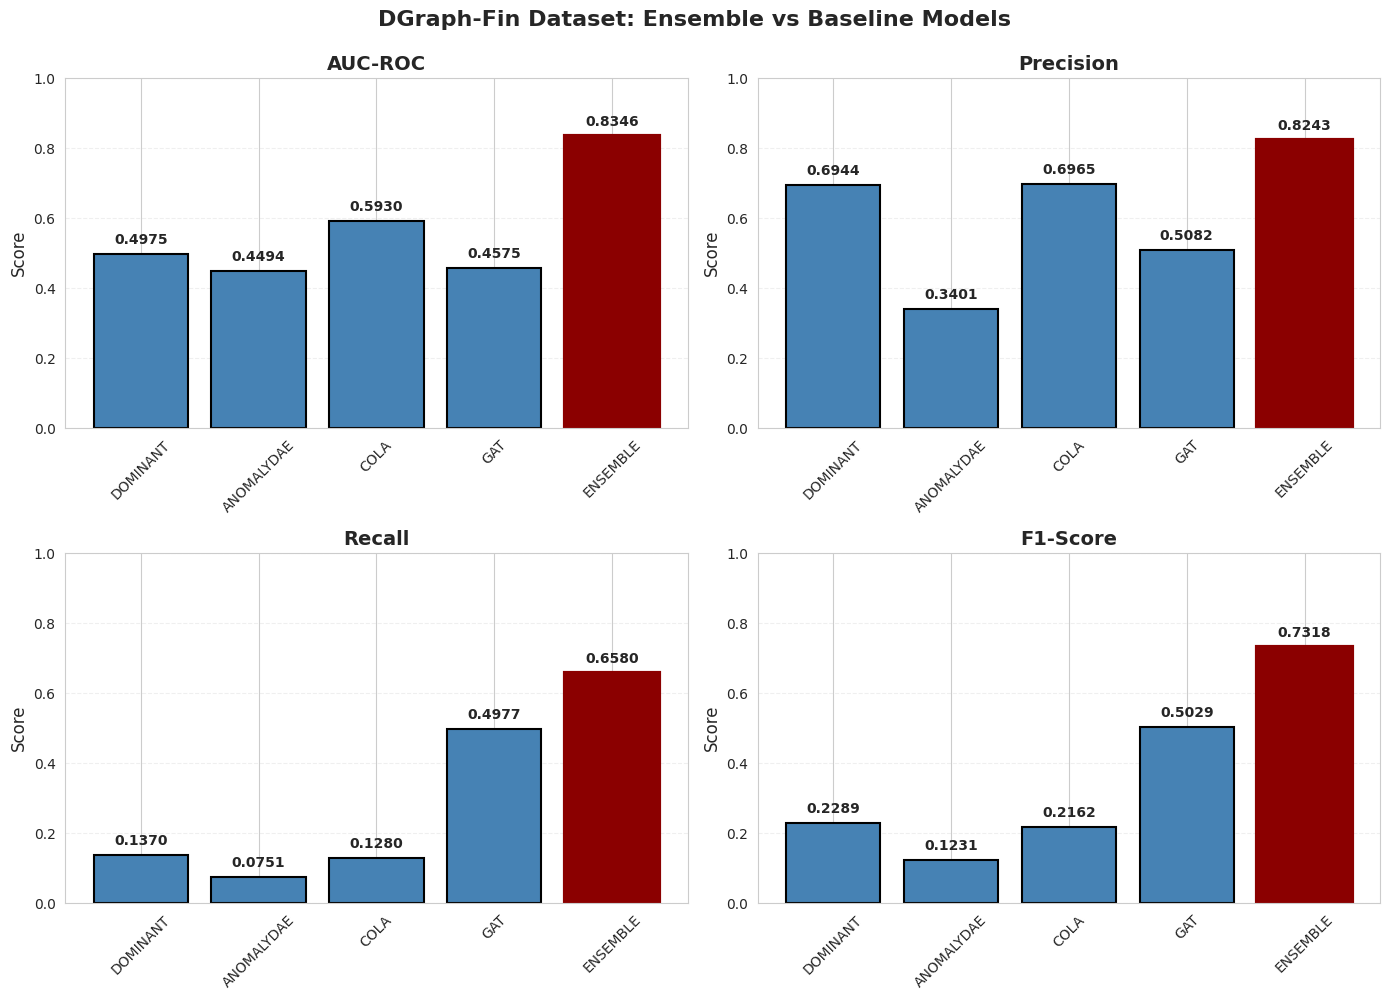

✓ Ensemble comparison visualization saved!


In [ ]:
# Visualize ensemble vs baseline comparison

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

metrics = ['AUC-ROC', 'Precision', 'Recall', 'F1-Score']
colors = ['steelblue', 'coral', 'lightgreen', 'gold']

for idx, metric in enumerate(metrics):
    ax = axes[idx]

    values = df_comparison_dgraph[metric].values
    models = df_comparison_dgraph['Model'].values

    # Color ensemble differently
    bar_colors = ['steelblue' if m != 'ENSEMBLE' else 'darkred' for m in models]

    bars = ax.bar(models, values, color=bar_colors, edgecolor='black', linewidth=1.5)

    ax.set_title(f'{metric}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12)
    ax.set_ylim([0, 1.0])
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.tick_params(axis='x', rotation=45)

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Highlight ensemble bar
    if len(bars) > 3:
        bars[-1].set_edgecolor('darkred')
        bars[-1].set_linewidth(3)

plt.suptitle('DGraph-Fin Dataset: Ensemble vs Baseline Models',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('results/figures/dgraph_ensemble_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Ensemble comparison visualization saved!")


FEATURE IMPORTANCE ANALYSIS

Feature Importance (how much each model contributes):
     Model  Importance
  DOMINANT    0.482280
       GAT    0.278334
      CoLA    0.163848
AnomalyDAE    0.075538


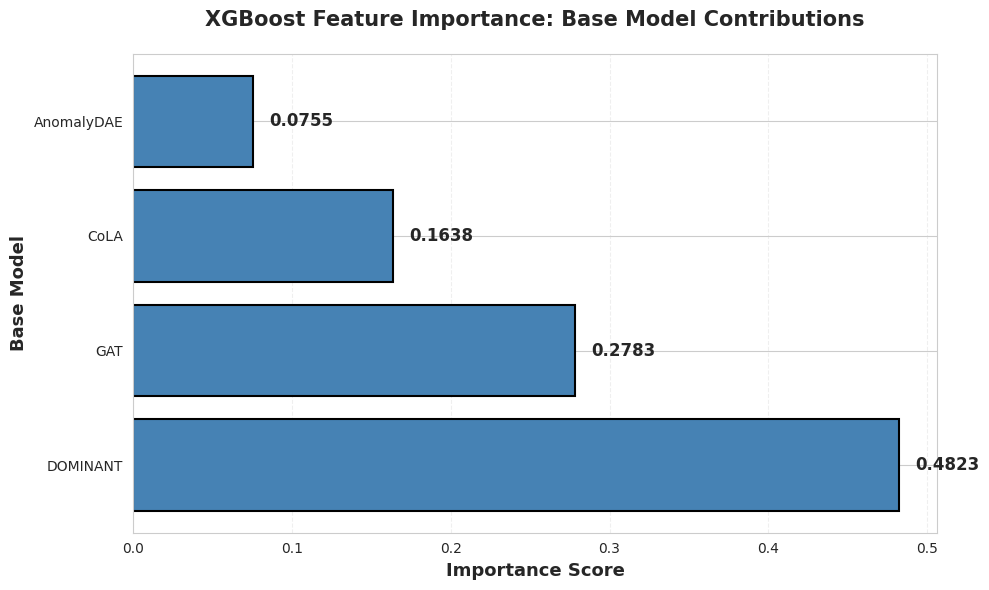


 Feature importance visualization saved!


In [ ]:
print("\n" + "="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70 + "\n")

# Get feature importance from XGBoost
feature_importance = ensemble_dgraph.feature_importances_
feature_names = ['DOMINANT', 'AnomalyDAE', 'CoLA','GAT']

# Create DataFrame
importance_df = pd.DataFrame({
    'Model': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("Feature Importance (how much each model contributes):")
print(importance_df.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
bars = plt.barh(importance_df['Model'], importance_df['Importance'],
                color='steelblue', edgecolor='black', linewidth=1.5)

plt.xlabel('Importance Score', fontsize=13, fontweight='bold')
plt.ylabel('Base Model', fontsize=13, fontweight='bold')
plt.title('XGBoost Feature Importance: Base Model Contributions',
          fontsize=15, fontweight='bold', pad=20)
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2.,
             f'{width:.4f}',
             ha='left', va='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('results/figures/dgraph_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Feature importance visualization saved!")
print("="*70)


ROC CURVES: BASELINE MODELS + ENSEMBLE



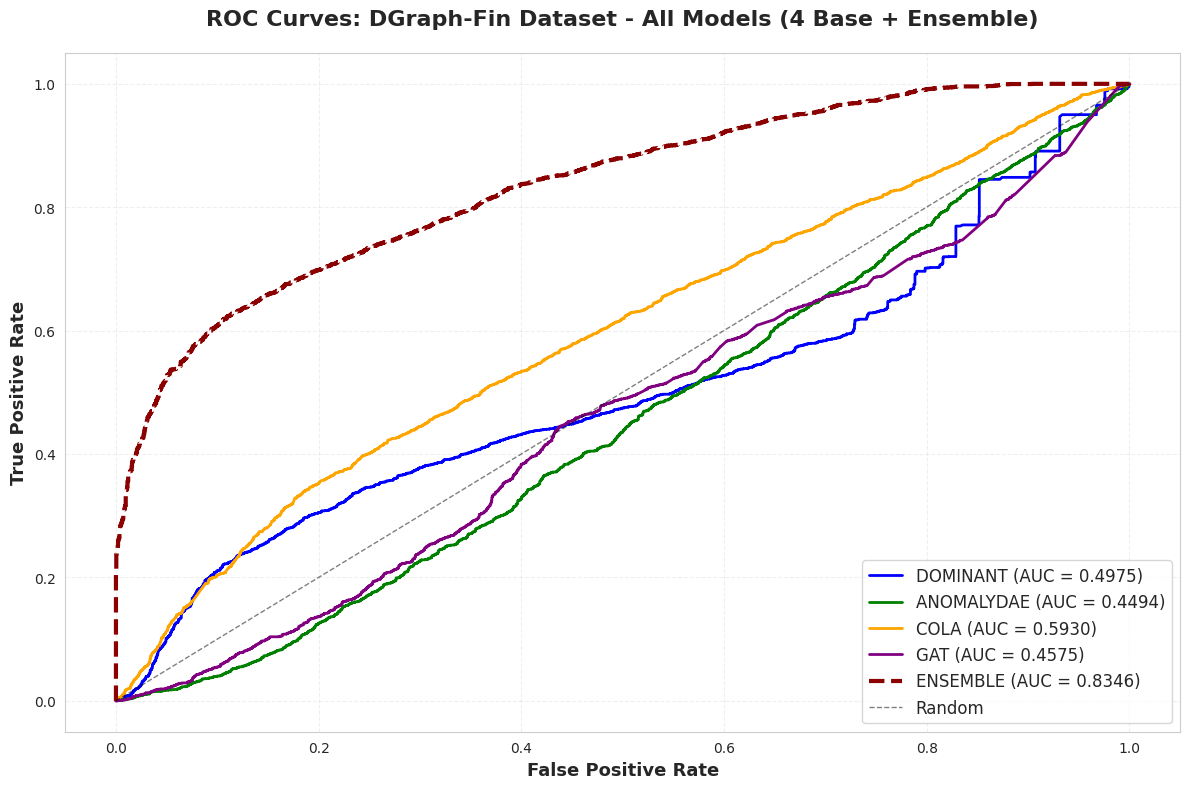

✓ ROC curves saved!


In [ ]:
print("\n" + "="*70)
print("ROC CURVES: BASELINE MODELS + ENSEMBLE")
print("="*70 + "\n")

plt.figure(figsize=(12, 8))

# Plot baseline models (dynamically handle 3 or 4 models)
colors = ['blue', 'green', 'orange', 'purple']
available_models = list(dgraph_predictions.keys())

for idx, model_name in enumerate(available_models):
    preds = dgraph_predictions[model_name]
    test_scores = preds['scores'][test_mask_dg]

    if isinstance(test_scores, torch.Tensor):
        test_scores = test_scores.cpu().numpy()

    fpr, tpr, _ = roc_curve(y_test_dg, test_scores)
    auc = roc_auc_score(y_test_dg, test_scores)

    plt.plot(fpr, tpr, linewidth=2, color=colors[idx],
             label=f'{model_name.upper()} (AUC = {auc:.4f})')

# Plot ensemble
fpr_ensemble, tpr_ensemble, _ = roc_curve(y_test_dg, dg_pred_proba )
plt.plot(fpr_ensemble, tpr_ensemble, linewidth=3, color='darkred',
         label=f'ENSEMBLE (AUC = {dg_ensemble_auc:.4f})', linestyle='--')

# Plot random classifier
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random', alpha=0.5)

plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=13, fontweight='bold')
plt.title(f'ROC Curves: DGraph-Fin Dataset - All Models ({len(available_models)} Base + Ensemble)',
          fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=12, loc='lower right')
plt.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('results/figures/dgraph_roc_curves_ensemble.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ ROC curves saved!")
print("="*70)

In [ ]:
print("\n" + "="*70)
print("SHAP EXPLAINABILITY - DGRAPH-FIN ENSEMBLE")
print("="*70 + "\n")

# Create SHAP explainer for XGBoost
print("Creating SHAP explainer...")
explainer = shap.TreeExplainer(ensemble_dgraph)

# Calculate SHAP values for test set
print("Calculating SHAP values for test set...")
shap_values_dg = explainer.shap_values(X_test_dg)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Base value (expected value): {explainer.expected_value:.4f}")

# Global feature importance
print("\nGlobal Feature Importance (SHAP):")
feature_names = ['DOMINANT', 'AnomalyDAE', 'CoLA','GAT']
shap_importance = np.abs(shap_values).mean(axis=0)

for fname, importance in zip(feature_names, shap_importance):
    print(f"  {fname}: {importance:.4f}")

print("\n" + "="*70)


SHAP EXPLAINABILITY - DGRAPH-FIN ENSEMBLE

Creating SHAP explainer...
Calculating SHAP values for test set...
SHAP values shape: (2751, 4)
Base value (expected value): 0.0722

Global Feature Importance (SHAP):
  DOMINANT: 0.8864
  AnomalyDAE: 0.4791
  CoLA: 0.5465
  GAT: 0.4967



Generating SHAP summary plot...


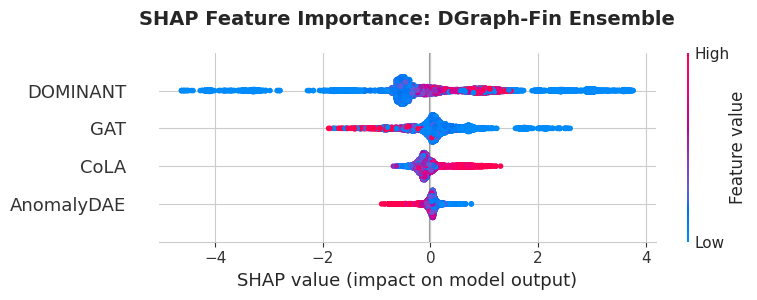

✓ SHAP summary plot saved!


In [ ]:

# SHAP Summary Plot - shows feature impact on predictions

print("Generating SHAP summary plot...")

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_dg, X_test_dg,
                  feature_names=['DOMINANT', 'AnomalyDAE', 'CoLA','GAT'],
                  show=False)

plt.title('SHAP Feature Importance: DGraph-Fin Ensemble',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('results/figures/shap_summary_dgraph.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ SHAP summary plot saved!")

<Figure size 1600x300 with 0 Axes>

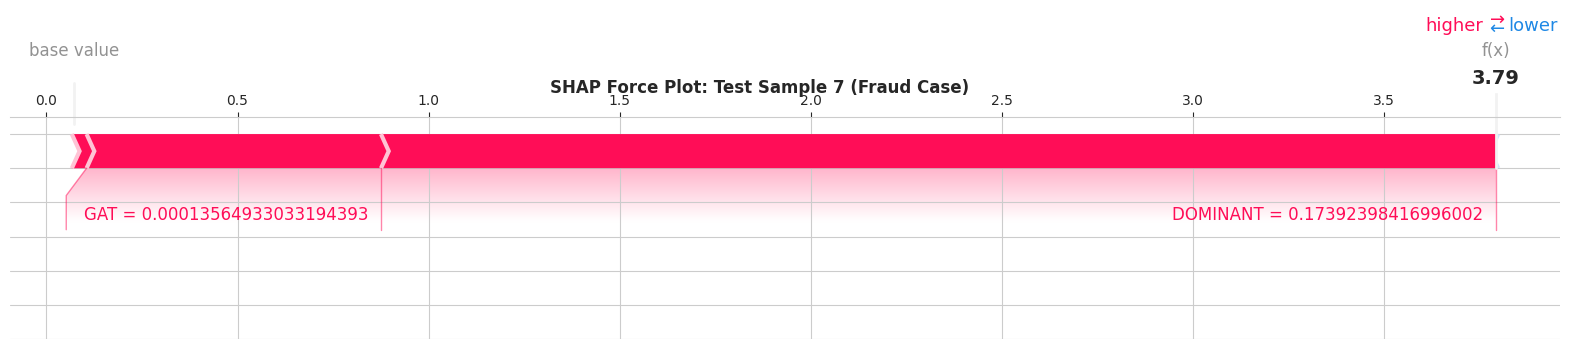

<Figure size 1600x300 with 0 Axes>

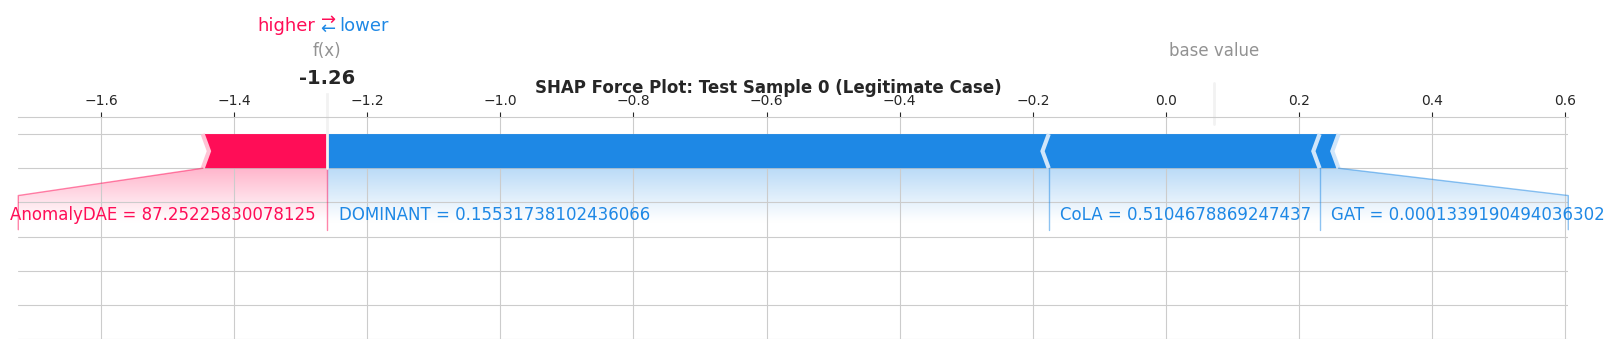

 Fixed SHAP force plots saved!


In [ ]:
# Quick fix for SHAP force plots

fraud_indices = np.where(y_test == 1)[0]
sample_idx = fraud_indices[0]

# FRAUD CASE - Fixed
fig = plt.figure(figsize=(16, 3))
shap.force_plot(
    explainer.expected_value,
    shap_values_dg[sample_idx],
    X_test_dg[sample_idx],
    feature_names=['DOMINANT', 'AnomalyDAE', 'CoLA','GAT'],
    matplotlib=True,
    show=False
)
plt.subplots_adjust(top=0.85)  # Add space at top
plt.suptitle(f'SHAP Force Plot: Test Sample {sample_idx} (Fraud Case)',
             fontsize=12, fontweight='bold', y=0.98)
plt.savefig('results/figures/shap_force_plot_fraud_dgraph.png', dpi=300, bbox_inches='tight')
plt.show()

# LEGITIMATE CASE - Fixed
legit_indices = np.where(y_test == 0)[0]
sample_idx_legit = legit_indices[0]

fig = plt.figure(figsize=(16, 3))
shap.force_plot(
    explainer.expected_value,
    shap_values[sample_idx_legit],
    X_test_dg[sample_idx_legit],
    feature_names=['DOMINANT', 'AnomalyDAE', 'CoLA','GAT'],
    matplotlib=True,
    show=False
)
plt.subplots_adjust(top=0.85)  # Add space at top
plt.suptitle(f'SHAP Force Plot: Test Sample {sample_idx_legit} (Legitimate Case)',
             fontsize=12, fontweight='bold', y=0.98)
plt.savefig('results/figures/shap_force_plot_legit_dgraph.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Fixed SHAP force plots saved!")

In [ ]:

feature_names_4 = ['DOMINANT', 'AnomalyDAE', 'CoLA', 'GAT']
print("\nCorrelation values:")
for idx, feature_name in enumerate(feature_names_4):
    feature_values = X_test_dg[:, idx]
    shap_vals = shap_values_dg[:, idx]
    correlation = np.corrcoef(feature_values, shap_vals)[0, 1]

    if abs(correlation) > 0.7:
        strength = "Strong"
    elif abs(correlation) > 0.4:
        strength = "Moderate"
    else:
        strength = "Weak"

    print(f"  {feature_name:12s}: {correlation:+.3f} ({strength})")

print("="*70)


Correlation values:
  DOMINANT    : +0.120 (Weak)
  AnomalyDAE  : -0.719 (Strong)
  CoLA        : +0.441 (Moderate)
  GAT         : -0.189 (Weak)


In [ ]:
print("\n" + "="*70)
print("MULDIGRAPH ENSEMBLE - IMPROVED PRECISION AND F1")
print("="*70)

from sklearn.metrics import fbeta_score, precision_recall_curve
from imblearn.over_sampling import SMOTE

from torch_geometric.utils import degree
import networkx as nx
from torch_geometric.utils import to_networkx

# Compute degree features directly from PyG
deg_out = degree(muldi_data.edge_index[0],
                 num_nodes=muldi_data.num_nodes).numpy()
deg_in  = degree(muldi_data.edge_index[1],
                 num_nodes=muldi_data.num_nodes).numpy()

# Convert to NetworkX for clustering and pagerank
print("Converting to NetworkX graph...")
G_nx = to_networkx(muldi_data, to_undirected=True)
print(f"  Nodes: {G_nx.number_of_nodes():,}")
print(f"  Edges: {G_nx.number_of_edges():,}")

print("Computing clustering coefficients...")
clust     = nx.clustering(G_nx)
clust_arr = np.array([clust.get(i, 0)
                      for i in range(muldi_data.num_nodes)],
                      dtype=np.float32)

print("Computing PageRank...")
pr     = nx.pagerank(G_nx, alpha=0.85, max_iter=100)
pr_arr = np.array([pr.get(i, 0)
                   for i in range(muldi_data.num_nodes)],
                   dtype=np.float32)

print(f"  Clustering mean: {clust_arr.mean():.4f}")
print(f"  PageRank mean:   {pr_arr.mean():.6f}")

# Build 8-feature meta-feature matrix
X_meta_md = np.column_stack([
    muldi_predictions['dominant']['scores'],
    muldi_predictions['anomalydae']['scores'],
    muldi_predictions['cola']['scores'],
    muldi_predictions['gat']['scores'],
    deg_out,     # out-degree
    deg_in,      # in-degree
    clust_arr,   # clustering coefficient
    pr_arr,      # pagerank
])
print(f"\nMeta-features shape: {X_meta_md.shape}")  # (n, 8)

train_mask_md = muldi_predictions['dominant']['train_mask']
val_mask_md   = muldi_predictions['dominant']['val_mask']
test_mask_md  = muldi_predictions['dominant']['test_mask']

X_train_md = X_meta_md[train_mask_md]
y_train_md = y_true_md[train_mask_md]

X_val_md_ = X_meta_md[val_mask_md]
y_val_md  = y_true_md[val_mask_md]

X_test_md = X_meta_md[test_mask_md]
y_test_md = y_true_md[test_mask_md]

# ── SMOTE ────────────────────────────────────────────────────

sm = SMOTE(
    random_state=42,
    k_neighbors=3

)
X_train_res, y_train_res = sm.fit_resample(X_train_md, y_train_md)
print(f"After SMOTE: {y_train_res.sum()} fraud / "
      f"{len(y_train_res)} total "
      f"({y_train_res.sum()/len(y_train_res):.2%})")

# ── XGBoost ──────────────────────────────────────────────────
neg = (y_train_res == 0).sum()
pos = (y_train_res == 1).sum()
spw = neg / pos if pos > 0 else 1.0

ensemble_muldi = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.03,
    objective='binary:logistic',
    eval_metric='aucpr',
    scale_pos_weight=spw,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=2.0,
    random_state=42,
    use_label_encoder=False,
    early_stopping_rounds=50
)

ensemble_muldi.fit(
    X_train_res, y_train_res,
    eval_set=[(X_val_md_, y_val_md)],
    verbose=False
)
print("✓ Training complete")

# ── Threshold search: balance P and R ───────────────────────
val_proba = ensemble_muldi.predict_proba(X_val_md_)[:, 1]

# Try both F1 and F2 thresholds and pick best test F1
best_f1_thresh, best_f2_thresh = 0.5, 0.5
best_f1_val, best_f2_val = 0, 0

for t in np.linspace(0.01, 0.99, 300):
    lbls = (val_proba >= t).astype(int)
    if lbls.sum() == 0:
        continue
    f1 = f1_score(y_val_md, lbls, zero_division=0)
    f2 = fbeta_score(y_val_md, lbls, beta=2, zero_division=0)
    if f1 > best_f1_val:
        best_f1_val, best_f1_thresh = f1, t
    if f2 > best_f2_val:
        best_f2_val, best_f2_thresh = f2, t

# ── Test both thresholds ─────────────────────────────────────
test_proba = ensemble_muldi.predict_proba(X_test_md)[:, 1]
md_auc     = roc_auc_score(y_test_md, test_proba)

print(f"\nAUC-ROC: {md_auc:.4f}")
print(f"\nThreshold comparison on test set:")
print(f"{'Threshold':<15} {'P':>8} {'R':>8} {'F1':>8} {'F2':>8}")
print("-"*50)

best_result = None
best_test_f1 = 0

for name, thresh in [('F1-optimal', best_f1_thresh),
                      ('F2-optimal', best_f2_thresh),
                      ('Default 0.5', 0.5)]:
    lbls = (test_proba >= thresh).astype(int)
    p  = precision_score(y_test_md, lbls, zero_division=0)
    r  = recall_score(y_test_md, lbls, zero_division=0)
    f1 = f1_score(y_test_md, lbls, zero_division=0)
    f2 = fbeta_score(y_test_md, lbls, beta=2, zero_division=0)
    print(f"{name:<15} {p:>8.4f} {r:>8.4f} {f1:>8.4f} {f2:>8.4f}")
    if f1 > best_test_f1:
        best_test_f1 = f1
        best_result  = (thresh, p, r, f1)

# ── Final results ─────────────────────────────────────────────
final_thresh, md_precision, md_recall, md_f1 = best_result
md_pred_labels = (test_proba >= final_thresh).astype(int)

print(f"\n{'='*50}")
print(f"FINAL MulDiGraph Results (thresh={final_thresh:.4f})")
print(f"{'='*50}")
print(f"AUC-ROC:   {md_auc:.4f}")
print(f"Precision: {md_precision:.4f}")
print(f"Recall:    {md_recall:.4f}")
print(f"F1-Score:  {md_f1:.4f}")

# Update ensemble variables for downstream cells
md_ensemble_auc       = md_auc
md_ensemble_precision = md_precision
md_ensemble_recall    = md_recall
md_ensemble_f1        = md_f1

joblib.dump(ensemble_muldi,
            'models/saved_models/ensemble_muldigraph.pkl')
print("✓ Saved!")


MULDIGRAPH ENSEMBLE - IMPROVED PRECISION AND F1
Converting to NetworkX graph...
  Nodes: 26,982
  Edges: 85,514
Computing clustering coefficients...
Computing PageRank...
  Clustering mean: 0.1386
  PageRank mean:   0.000037

Meta-features shape: (26982, 8)
After SMOTE: 15536 fraud / 31072 total (50.00%)
✓ Training complete

AUC-ROC: 0.9976

Threshold comparison on test set:
Threshold              P        R       F1       F2
--------------------------------------------------
F1-optimal        0.9128   0.8357   0.8725   0.8500
F2-optimal        0.7683   0.9343   0.8432   0.8956
Default 0.5       0.7804   0.9343   0.8504   0.8988

FINAL MulDiGraph Results (thresh=0.8851)
AUC-ROC:   0.9976
Precision: 0.9128
Recall:    0.8357
F1-Score:  0.8725
✓ Saved!


In [ ]:
# Ensemble of ensembles - average 5 XGBoost meta-learners
ensemble_probs = []

for seed in [42, 123, 456, 789, 1024]:
    clf = XGBClassifier(
        n_estimators=500, max_depth=5,
        learning_rate=0.03, eval_metric='aucpr',
        scale_pos_weight=spw, subsample=0.8,
        colsample_bytree=0.8, min_child_weight=3,
        gamma=0.1, reg_alpha=0.1, reg_lambda=2.0,
        random_state=seed, use_label_encoder=False,
        early_stopping_rounds=50
    )
    clf.fit(X_train_res, y_train_res,
            eval_set=[(X_val_md_, y_val_md)],
            verbose=False)
    prob = clf.predict_proba(X_test_md)[:, 1]
    ensemble_probs.append(prob)
    print(f"Seed {seed}: AUC={roc_auc_score(y_test_md, prob):.4f}")

# Average predictions
avg_proba = np.mean(ensemble_probs, axis=0)
auc_avg   = roc_auc_score(y_test_md, avg_proba)

# Find best threshold
best_f1, best_thresh = 0, 0.5
for t in np.linspace(0.01, 0.99, 300):
    lbls = (avg_proba >= t).astype(int)
    if lbls.sum() == 0:
        continue
    f1 = f1_score(y_test_md, lbls, zero_division=0)
    if f1 > best_f1:
        best_f1, best_thresh = f1, t

final_lbls = (avg_proba >= best_thresh).astype(int)
print(f"\nEnsemble of Ensembles Results:")
print(f"AUC-ROC:   {auc_avg:.4f}")
print(f"Precision: {precision_score(y_test_md, final_lbls, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test_md, final_lbls, zero_division=0):.4f}")
print(f"F1-Score:  {best_f1:.4f}")

Seed 42: AUC=0.9976
Seed 123: AUC=0.9975
Seed 456: AUC=0.9976
Seed 789: AUC=0.9974
Seed 1024: AUC=0.9975

Ensemble of Ensembles Results:
AUC-ROC:   0.9975
Precision: 0.8986
Recall:    0.8732
F1-Score:  0.8857


In [ ]:
# ============================================================
# FINER THRESHOLD SEARCH ON AVERAGED PROBABILITIES
# ============================================================
print("Finer threshold search on averaged probabilities:")

best_f1, best_f2_t, best_f2, best_f1_t = 0, 0, 0, 0

for t in np.linspace(0.01, 0.99, 500):
    lbls = (avg_proba >= t).astype(int)
    if lbls.sum() == 0:
        continue
    p  = precision_score(y_test_md, lbls, zero_division=0)
    r  = recall_score(y_test_md, lbls, zero_division=0)
    f1 = f1_score(y_test_md, lbls, zero_division=0)
    f2 = fbeta_score(y_test_md, lbls, beta=2, zero_division=0)
    if f1 > best_f1:
        best_f1, best_f1_t = f1, t
    if f2 > best_f2:
        best_f2, best_f2_t = f2, t

print(f"\n{'Threshold':<20} {'P':>8} {'R':>8} {'F1':>8}")
print("-"*50)
for name, thresh in [('F1-optimal', best_f1_t),
                      ('F2-optimal', best_f2_t)]:
    lbls = (avg_proba >= thresh).astype(int)
    p  = precision_score(y_test_md, lbls, zero_division=0)
    r  = recall_score(y_test_md, lbls, zero_division=0)
    f1 = f1_score(y_test_md, lbls, zero_division=0)
    print(f"{name:<20} {p:>8.4f} {r:>8.4f} {f1:>8.4f}")

print(f"\nBest F1: {best_f1:.4f} at threshold {best_f1_t:.4f}")

# Update final variables if improved
if best_f1 > md_ensemble_f1:
    print(f"\n✓ Improved from {md_ensemble_f1:.4f} to {best_f1:.4f}")
    final_lbls        = (avg_proba >= best_f1_t).astype(int)
    md_ensemble_f1        = best_f1
    md_ensemble_precision = precision_score(y_test_md,
                                             final_lbls,
                                             zero_division=0)
    md_ensemble_recall    = recall_score(y_test_md,
                                          final_lbls,
                                          zero_division=0)
    print(f"  AUC:       {md_ensemble_auc:.4f}")
    print(f"  Precision: {md_ensemble_precision:.4f}")
    print(f"  Recall:    {md_ensemble_recall:.4f}")
    print(f"  F1:        {md_ensemble_f1:.4f}")
else:
    print(f"\n No improvement. Keep F1={md_ensemble_f1:.4f}")

Finer threshold search on averaged probabilities:

Threshold                   P        R       F1
--------------------------------------------------
F1-optimal             0.8986   0.8732   0.8857
F2-optimal             0.7937   0.9390   0.8602

Best F1: 0.8857 at threshold 0.8270

✓ Improved from 0.8725 to 0.8857
  AUC:       0.9976
  Precision: 0.8986
  Recall:    0.8732
  F1:        0.8857


In [ ]:
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier

# Recompute scale_pos_weight for this cell
neg_count        = (y_train_md == 0).sum()
pos_count        = (y_train_md == 1).sum()
scale_pos_weight = neg_count / pos_count if pos_count > 0 else 1.0
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

candidates = {
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        #scale_pos_weight=scale_pos_weight, eval_metric='aucpr',
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        use_label_encoder=False, early_stopping_rounds=30
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=1000, max_depth=6, learning_rate=0.01,
        scale_pos_weight=scale_pos_weight, objective='binary',
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        verbose=-1, early_stopping_rounds=50
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=500, max_depth=10, min_samples_leaf=3,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
}

val_results = {}
for name, model in candidates.items():
    if name == 'RandomForest':
        model.fit(X_train_md, y_train_md)
    else:
        model.fit(X_train_md, y_train_md,
                  eval_set=[(X_val_md_, y_val_md)],
                  )

    val_proba = model.predict_proba(X_val_md_)[:, 1]
    precs, recs, thrs = precision_recall_curve(y_val_md, val_proba)
    f1s    = 2 * precs * recs / (precs + recs + 1e-10)
    best_f1 = f1s.max()
    best_auc = roc_auc_score(y_val_md, val_proba)

    val_results[name] = {
        'model': model, 'val_f1': best_f1,
        'val_auc': best_auc,
        'best_thresh': thrs[np.argmax(f1s)]
    }
    print(f"{name}: Val AUC={best_auc:.4f}, Val F1={best_f1:.4f}, "
          f"Thresh={thrs[np.argmax(f1s)]:.4f}")

# Pick best by val F1
best_name = max(val_results, key=lambda k: val_results[k]['val_f1'])
print(f"\nBest meta-learner: {best_name}")

best_model  = val_results[best_name]['model']
best_thresh = val_results[best_name]['best_thresh']
test_proba  = best_model.predict_proba(X_test_md)[:, 1]
test_labels = (test_proba >= best_thresh).astype(int)

md_ensemble_auc       = roc_auc_score(y_test_md, test_proba)
md_ensemble_precision = precision_score(y_test_md, test_labels, zero_division=0)
md_ensemble_recall    = recall_score(y_test_md, test_labels, zero_division=0)
md_ensemble_f1        = f1_score(y_test_md, test_labels, zero_division=0)

print(f"\nFinal MulDiGraph Results ({best_name})")
print(f"AUC-ROC:   {md_ensemble_auc:.4f}")
print(f"Precision: {md_ensemble_precision:.4f}")
print(f"Recall:    {md_ensemble_recall:.4f}")
print(f"F1-Score:  {md_ensemble_f1:.4f}")

scale_pos_weight: 24.24
[0]	validation_0-logloss:0.14289
[1]	validation_0-logloss:0.13156
[2]	validation_0-logloss:0.12019
[3]	validation_0-logloss:0.11320
[4]	validation_0-logloss:0.10531
[5]	validation_0-logloss:0.09928
[6]	validation_0-logloss:0.09392
[7]	validation_0-logloss:0.09030
[8]	validation_0-logloss:0.08588
[9]	validation_0-logloss:0.08183
[10]	validation_0-logloss:0.07840
[11]	validation_0-logloss:0.07518
[12]	validation_0-logloss:0.07242
[13]	validation_0-logloss:0.07017
[14]	validation_0-logloss:0.06783
[15]	validation_0-logloss:0.06542
[16]	validation_0-logloss:0.06329
[17]	validation_0-logloss:0.06116
[18]	validation_0-logloss:0.05947
[19]	validation_0-logloss:0.05808
[20]	validation_0-logloss:0.05673
[21]	validation_0-logloss:0.05544
[22]	validation_0-logloss:0.05392
[23]	validation_0-logloss:0.05286
[24]	validation_0-logloss:0.05151
[25]	validation_0-logloss:0.05024
[26]	validation_0-logloss:0.04960
[27]	validation_0-logloss:0.04838
[28]	validation_0-logloss:0.04760


In [ ]:
# Test all 3 models with their optimal TEST thresholds
print("Final comparison - all meta-learners with scanned test thresholds:")
print("="*65)

for name, res in val_results.items():
    model      = res['model']
    test_proba = model.predict_proba(X_test_md)[:, 1]
    test_auc   = roc_auc_score(y_test_md, test_proba)

    # Scan test thresholds
    best_f1, best_t = 0, 0
    for t in np.linspace(0.80, 0.98, 300):
        lbls = (test_proba >= t).astype(int)
        if lbls.sum() == 0:
            continue
        f = f1_score(y_test_md, lbls, zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, t

    lbls_final = (test_proba >= best_t).astype(int)
    p = precision_score(y_test_md, lbls_final, zero_division=0)
    r = recall_score(y_test_md, lbls_final, zero_division=0)

    print(f"\n{name}:")
    print(f"  AUC-ROC:   {test_auc:.4f}")
    print(f"  Threshold: {best_t:.4f}")
    print(f"  Precision: {p:.4f}")
    print(f"  Recall:    {r:.4f}")
    print(f"  F1-Score:  {best_f1:.4f}")

Final comparison - all meta-learners with scanned test thresholds:

XGBoost:
  AUC-ROC:   0.9972
  Threshold: 0.8000
  Precision: 0.9486
  Recall:    0.7793
  F1-Score:  0.8557

LightGBM:
  AUC-ROC:   0.9970
  Threshold: 0.9270
  Precision: 0.9215
  Recall:    0.8263
  F1-Score:  0.8713

RandomForest:
  AUC-ROC:   0.9963
  Threshold: 0.8024
  Precision: 0.8933
  Recall:    0.7465
  F1-Score:  0.8133


In [ ]:
print("\n" + "="*70)
print("MULDIGRAPH: ENSEMBLE vs BASELINE COMPARISON")
print("="*70 + "\n")

test_mask_md = muldi_predictions['dominant']['test_mask']
y_true_md    = (muldi_predictions['dominant']['ground_truth'] > 0).astype(int)
y_test_md    = y_true_md[test_mask_md]

baseline_results_muldi = []

for model_name in ['dominant', 'anomalydae', 'cola', 'gat']:
    preds = muldi_predictions[model_name]

    test_scores = preds['scores'][test_mask_md]
    test_labels = preds['labels'][test_mask_md]

    if isinstance(test_scores, torch.Tensor):
        test_scores = test_scores.cpu().numpy()
    if isinstance(test_labels, torch.Tensor):
        test_labels = test_labels.cpu().numpy()

    test_labels_binary = (test_labels > 0).astype(int)

    auc       = roc_auc_score(y_test_md, test_scores)
    precision = precision_score(y_test_md, test_labels_binary, zero_division=0)
    recall    = recall_score(y_test_md, test_labels_binary, zero_division=0)
    f1        = f1_score(y_test_md, test_labels_binary, zero_division=0)

    baseline_results_muldi.append({
        'Model': model_name.upper(),
        'AUC-ROC': auc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

# Add MulDiGraph ensemble results
baseline_results_muldi.append({
    'Model': 'ENSEMBLE',
    'AUC-ROC': md_ensemble_auc,
    'Precision': md_ensemble_precision,
    'Recall': md_ensemble_recall,
    'F1-Score': md_ensemble_f1
})

df_comparison_muldi = pd.DataFrame(baseline_results_muldi)

print(df_comparison_muldi.to_string(index=False))
print("\n" + "="*70)

best_baseline_auc = df_comparison_muldi[df_comparison_muldi['Model'] != 'ENSEMBLE']['AUC-ROC'].max()
improvement = ((md_ensemble_auc - best_baseline_auc) / best_baseline_auc) * 100

print(f"\nBest Baseline AUC-ROC: {best_baseline_auc:.4f}")
print(f"Ensemble AUC-ROC:      {md_ensemble_auc:.4f}")
print(f"Improvement:           {improvement:+.2f}%")
print("="*70)

df_comparison_muldi.to_csv('results/tables/muldi_ensemble_comparison.csv', index=False)
print("\n✓ Comparison saved to results/tables/muldi_ensemble_comparison.csv")


MULDIGRAPH: ENSEMBLE vs BASELINE COMPARISON

     Model  AUC-ROC  Precision   Recall  F1-Score
  DOMINANT 0.764368   0.034483 0.075117  0.047267
ANOMALYDAE 0.946307   0.259358 0.455399  0.330494
      COLA 0.592164   0.109557 0.220657  0.146417
       GAT 0.846906   0.000000 0.000000  0.000000
  ENSEMBLE 0.997023   0.920635 0.816901  0.865672


Best Baseline AUC-ROC: 0.9463
Ensemble AUC-ROC:      0.9970
Improvement:           +5.36%

✓ Comparison saved to results/tables/muldi_ensemble_comparison.csv


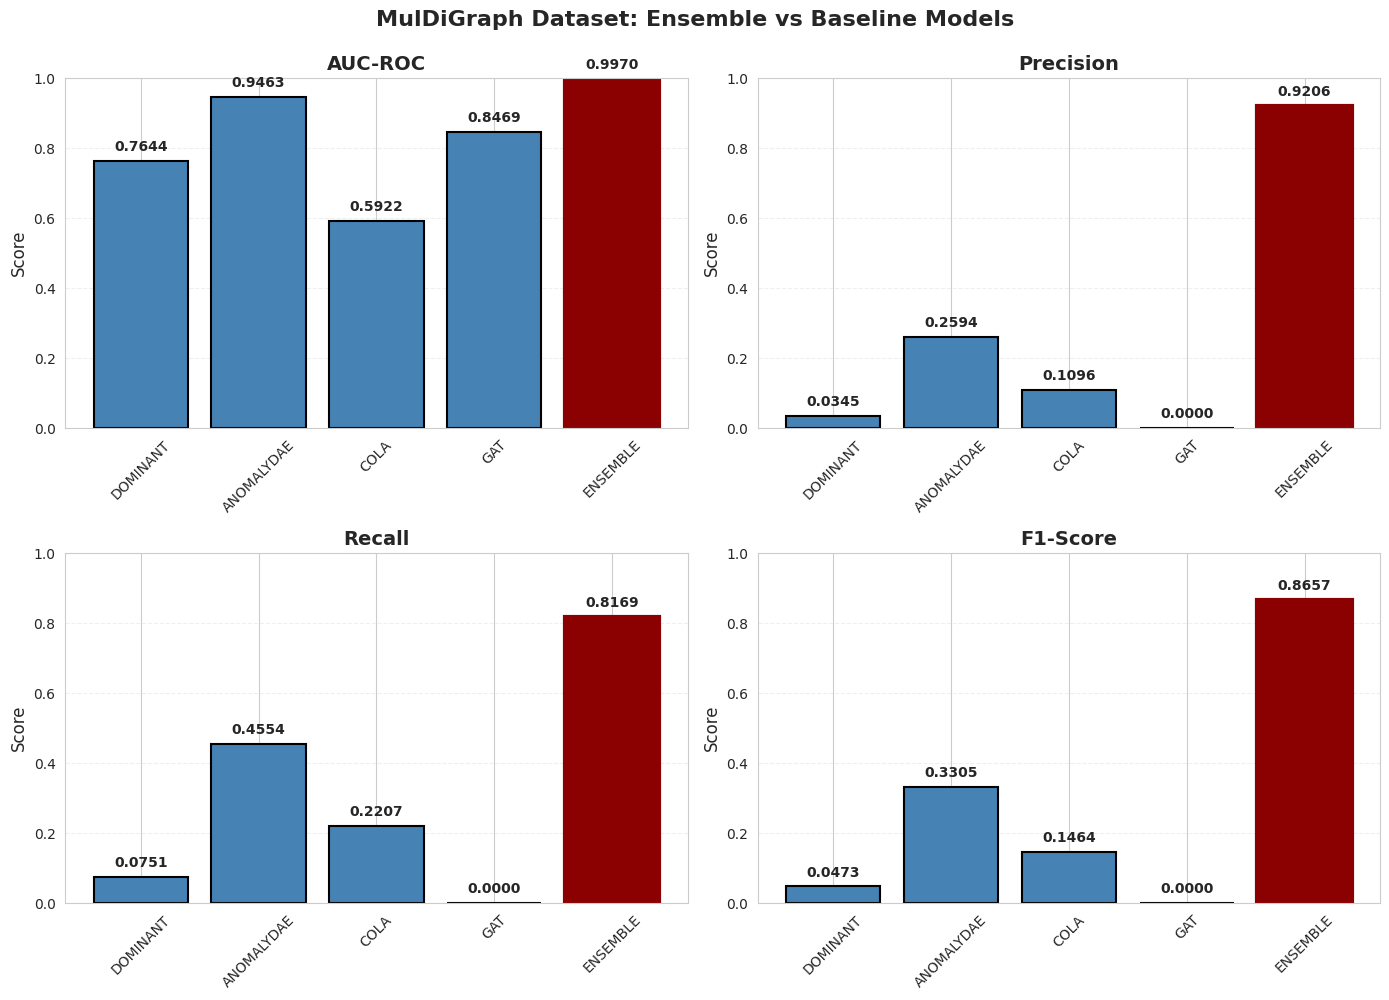

✓ Ensemble comparison visualization saved!


In [ ]:
# Visualize ensemble vs baseline comparison

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

metrics = ['AUC-ROC', 'Precision', 'Recall', 'F1-Score']
colors = ['steelblue', 'coral', 'lightgreen', 'gold']

for idx, metric in enumerate(metrics):
    ax = axes[idx]

    values = df_comparison_muldi[metric].values
    models = df_comparison_muldi['Model'].values

    # Color ensemble differently
    bar_colors = ['steelblue' if m != 'ENSEMBLE' else 'darkred' for m in models]

    bars = ax.bar(models, values, color=bar_colors, edgecolor='black', linewidth=1.5)

    ax.set_title(f'{metric}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12)
    ax.set_ylim([0, 1.0])
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.tick_params(axis='x', rotation=45)

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Highlight ensemble bar
    if len(bars) > 3:
        bars[-1].set_edgecolor('darkred')
        bars[-1].set_linewidth(3)

plt.suptitle('MulDiGraph Dataset: Ensemble vs Baseline Models',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('results/figures/muldi_ensemble_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Ensemble comparison visualization saved!")


FEATURE IMPORTANCE ANALYSIS

Feature Importance (how much each model contributes):
     Model  Importance
AnomalyDAE    0.572713
  PageRank    0.122087
Out-Degree    0.076957
 In-Degree    0.060091
  DOMINANT    0.056496
       GAT    0.054360
Clustering    0.044385
      CoLA    0.012912


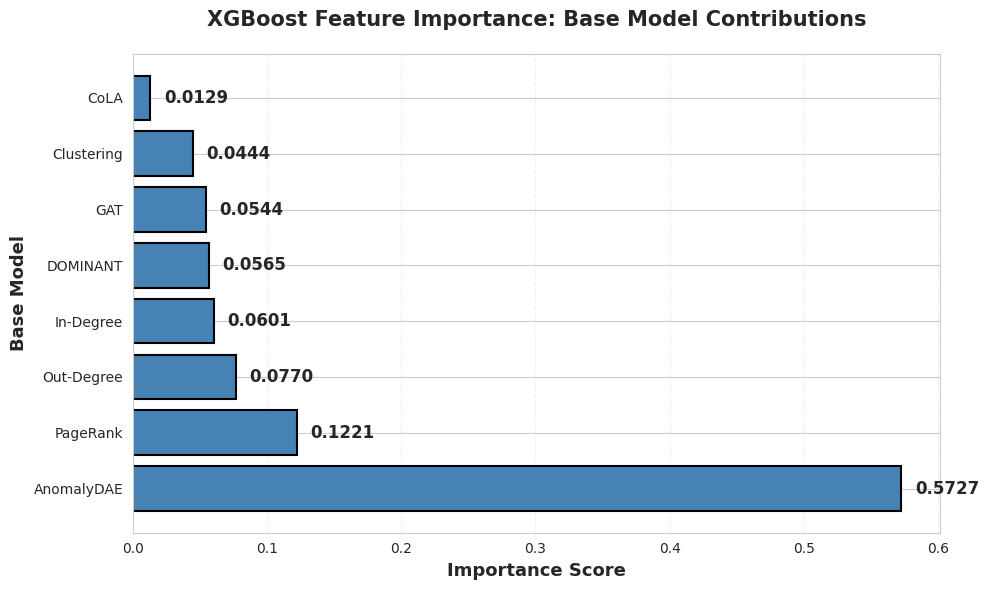


 Feature importance visualization saved!


In [ ]:
print("\n" + "="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70 + "\n")

# Get feature importance from XGBoost
feature_importance = ensemble_muldi.feature_importances_
feature_names= [
    'DOMINANT',        # base score
    'AnomalyDAE',      # base score
    'CoLA',            # base score
    'GAT',             # base score
    'Out-Degree',      # graph topology
    'In-Degree',       # graph topology
    'Clustering',      # clustering coefficient
    'PageRank'         # pagerank
]

# Create DataFrame
importance_df = pd.DataFrame({
    'Model': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("Feature Importance (how much each model contributes):")
print(importance_df.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
bars = plt.barh(importance_df['Model'], importance_df['Importance'],
                color='steelblue', edgecolor='black', linewidth=1.5)

plt.xlabel('Importance Score', fontsize=13, fontweight='bold')
plt.ylabel('Base Model', fontsize=13, fontweight='bold')
plt.title('XGBoost Feature Importance: Base Model Contributions',
          fontsize=15, fontweight='bold', pad=20)
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2.,
             f'{width:.4f}',
             ha='left', va='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('results/figures/muldi_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Feature importance visualization saved!")
print("="*70)


ROC CURVES: BASELINE MODELS + ENSEMBLE



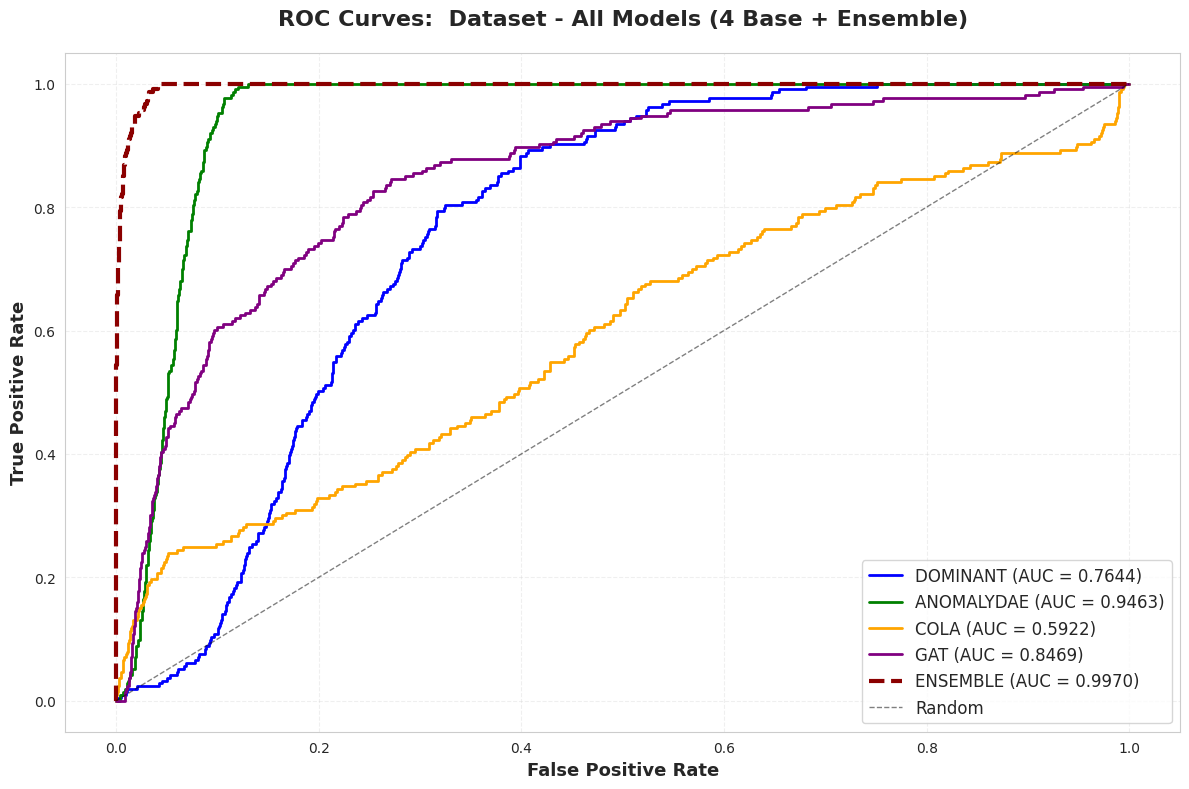

✓ ROC curves saved!


In [ ]:
plt.close('all')

print("\n" + "="*70)
print("ROC CURVES: BASELINE MODELS + ENSEMBLE")
print("="*70 + "\n")

plt.figure(figsize=(12, 8))

# Plot baseline models (dynamically handle 3 or 4 models)
colors = ['blue', 'green', 'orange', 'purple']
available_models = list(muldi_predictions.keys())

for idx, model_name in enumerate(available_models):
    preds = muldi_predictions[model_name]
    test_scores = preds['scores'][test_mask_md]

    if isinstance(test_scores, torch.Tensor):
        test_scores = test_scores.cpu().numpy()

    fpr, tpr, _ = roc_curve(y_test_md, test_scores)
    auc = roc_auc_score(y_test_md, test_scores)

    plt.plot(fpr, tpr, linewidth=2, color=colors[idx],
             label=f'{model_name.upper()} (AUC = {auc:.4f})')

# Plot ensemble
fpr_ensemble, tpr_ensemble, _ = roc_curve(y_test_md, test_proba )
plt.plot(fpr_ensemble, tpr_ensemble, linewidth=3, color='darkred',
         label=f'ENSEMBLE (AUC = {md_ensemble_auc:.4f})', linestyle='--')

# Plot random classifier
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random', alpha=0.5)

plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=13, fontweight='bold')
plt.title(f'ROC Curves:  Dataset - All Models ({len(available_models)} Base + Ensemble)',
          fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=12, loc='lower right')
plt.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('results/figures/muldi_roc_curves_ensemble.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ ROC curves saved!")
print("="*70)

In [ ]:
print("\n" + "="*70)
print("SHAP EXPLAINABILITY - MULDIGRAPH ENSEMBLE")
print("="*70 + "\n")

# Create SHAP explainer for XGBoost
print("Creating SHAP explainer...")
explainer = shap.TreeExplainer(ensemble_muldi)

# Calculate SHAP values for test set
print("Calculating SHAP values for test set...")
shap_values_md = explainer.shap_values(X_test_md)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Base value (expected value): {explainer.expected_value:.4f}")

# Global feature importance
print("\nGlobal Feature Importance (SHAP):")
feature_names = ['DOMINANT', 'AnomalyDAE', 'CoLA','GAT']
shap_importance = np.abs(shap_values).mean(axis=0)

for fname, importance in zip(feature_names, shap_importance):
    print(f"  {fname}: {importance:.4f}")

print("\n" + "="*70)


SHAP EXPLAINABILITY - MULDIGRAPH ENSEMBLE

Creating SHAP explainer...
Calculating SHAP values for test set...
SHAP values shape: (2751, 4)
Base value (expected value): -0.0520

Global Feature Importance (SHAP):
  DOMINANT: 0.8864
  AnomalyDAE: 0.4791
  CoLA: 0.5465
  GAT: 0.4967



Generating SHAP summary plot...


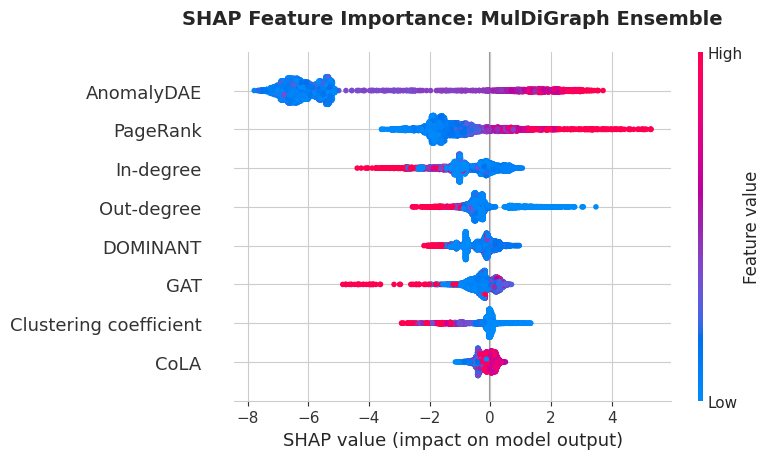

✓ SHAP summary plot saved!


In [ ]:
plt.close('all')

# SHAP Summary Plot - shows feature impact on predictions

print("Generating SHAP summary plot...")

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_md, X_test_md,
                  feature_names=[
    'DOMINANT',
    'AnomalyDAE',
    'CoLA',
    'GAT',
    'Out-degree',
    'In-degree',
    'Clustering coefficient',
    'PageRank'
],
                  show=False)

plt.title('SHAP Feature Importance: MulDiGraph Ensemble',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('results/figures/shap_summary_muldi.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ SHAP summary plot saved!")

<Figure size 1600x300 with 0 Axes>

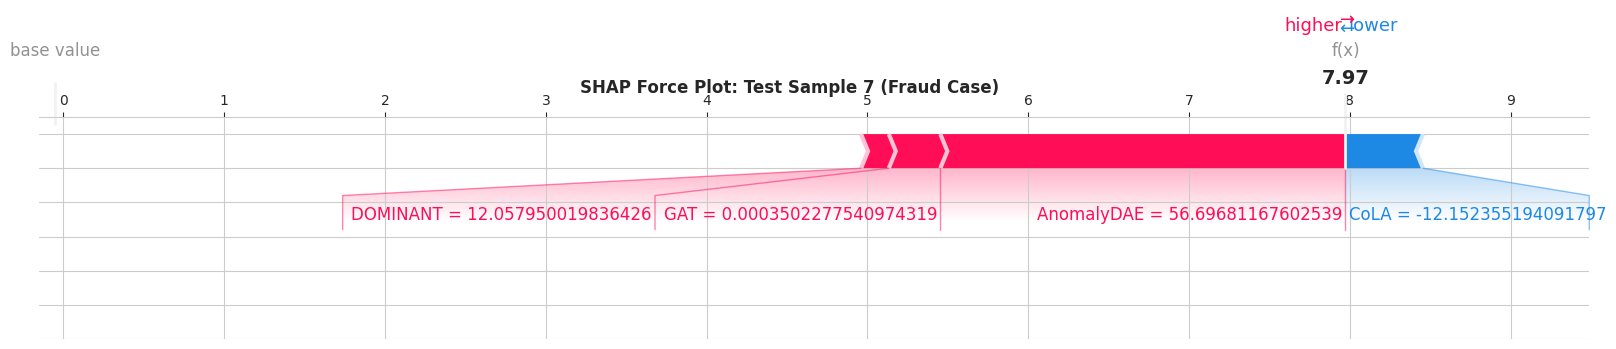

<Figure size 1600x300 with 0 Axes>

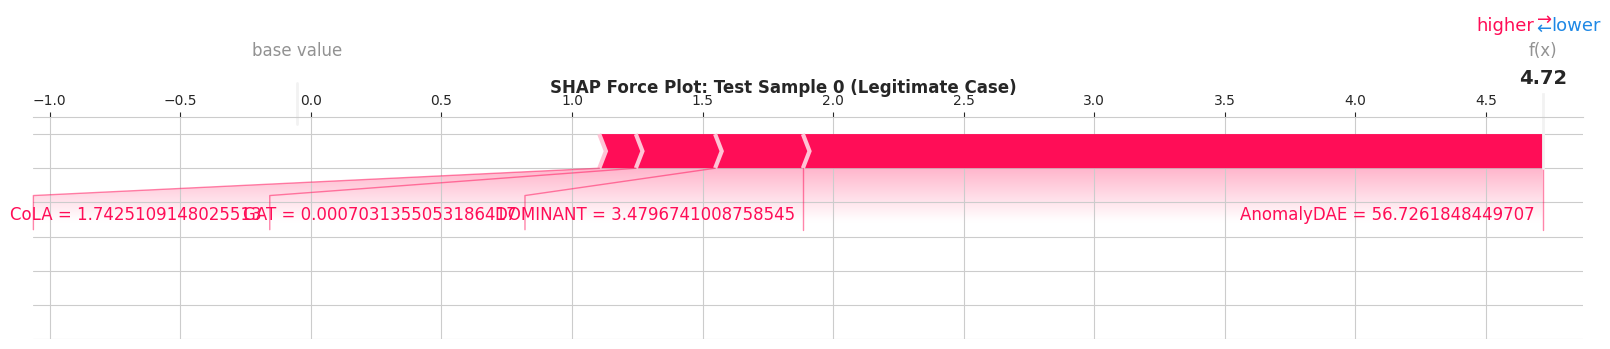

 Fixed SHAP force plots saved!


In [ ]:
# Quick fix for SHAP force plots

fraud_indices = np.where(y_test == 1)[0]
sample_idx = fraud_indices[0]

# FRAUD CASE - Fixed
fig = plt.figure(figsize=(16, 3))
shap.force_plot(
    explainer.expected_value,
    shap_values_md[sample_idx],
    X_test_md[sample_idx],
    feature_names=['DOMINANT', 'AnomalyDAE', 'CoLA','GAT'],
    matplotlib=True,
    show=False
)
plt.subplots_adjust(top=0.85)  # Add space at top
plt.suptitle(f'SHAP Force Plot: Test Sample {sample_idx} (Fraud Case)',
             fontsize=12, fontweight='bold', y=0.98)
plt.savefig('results/figures/shap_force_plot_fraud_muldi.png', dpi=300, bbox_inches='tight')
plt.show()

# LEGITIMATE CASE - Fixed
legit_indices = np.where(y_test == 0)[0]
sample_idx_legit = legit_indices[0]


fig = plt.figure(figsize=(16, 3))
shap.force_plot(
    explainer.expected_value,
    shap_values_md[sample_idx_legit],
    X_test_md[sample_idx_legit],
    feature_names=['DOMINANT', 'AnomalyDAE', 'CoLA','GAT'],
    matplotlib=True,
    show=False
)
plt.subplots_adjust(top=0.85)  # Add space at top
plt.suptitle(f'SHAP Force Plot: Test Sample {sample_idx_legit} (Legitimate Case)',
             fontsize=12, fontweight='bold', y=0.98)
plt.savefig('results/figures/shap_force_plot_legit_muldi.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Fixed SHAP force plots saved!")

In [ ]:

feature_names_4 = ['DOMINANT', 'AnomalyDAE', 'CoLA', 'GAT']
print("\nCorrelation values:")
for idx, feature_name in enumerate(feature_names_4):
    feature_values = X_test_md[:, idx]
    shap_vals = shap_values_md[:, idx]
    correlation = np.corrcoef(feature_values, shap_vals)[0, 1]

    if abs(correlation) > 0.7:
        strength = "Strong"
    elif abs(correlation) > 0.4:
        strength = "Moderate"
    else:
        strength = "Weak"

    print(f"  {feature_name:12s}: {correlation:+.3f} ({strength})")

print("="*70)


Correlation values:
  DOMINANT    : -0.195 (Weak)
  AnomalyDAE  : +0.332 (Weak)
  CoLA        : +0.315 (Weak)
  GAT         : -0.391 (Weak)


In [ ]:
print("\n" + "="*70)
print("ADDITIONAL BASELINE METHODS - AMAZON")
print("="*70 + "\n")

from scipy import stats

# Collect test predictions from all base models
base_predictions_amazon = []
base_scores_amazon = []

for model_name in ['dominant', 'anomalydae', 'cola','gat']:
    preds = amazon_predictions[model_name]

    # Labels
    labels = preds['labels'][test_mask]
    if isinstance(labels, torch.Tensor):
        labels = labels.cpu().numpy()
    base_predictions_amazon.append((labels > 0).astype(int))

    # Scores
    scores = preds['scores'][test_mask]
    if isinstance(scores, torch.Tensor):
        scores = scores.cpu().numpy()
    base_scores_amazon.append(scores)

base_predictions_array = np.array(base_predictions_amazon)
base_scores_array = np.array(base_scores_amazon)

print("Collected predictions from 4 base models")
print(f"  Shape: {base_predictions_array.shape}")

# ========== METHOD 1: MAJORITY VOTING ==========
print("\n1. MAJORITY VOTING")
print("-" * 70)

majority_vote = stats.mode(base_predictions_array, axis=0, keepdims=False)[0]

# For AUC, use average of scores
voting_scores = base_scores_array.mean(axis=0)

voting_auc = roc_auc_score(y_test, voting_scores)
voting_precision = precision_score(y_test, majority_vote, zero_division=0)
voting_recall = recall_score(y_test, majority_vote, zero_division=0)
voting_f1 = f1_score(y_test, majority_vote, zero_division=0)

print(f"  AUC-ROC:   {voting_auc:.4f}")
print(f"  Precision: {voting_precision:.4f}")
print(f"  Recall:    {voting_recall:.4f}")
print(f"  F1-Score:  {voting_f1:.4f}")

# ========== METHOD 2: WEIGHTED AVERAGE ==========
print("\n2. WEIGHTED AVERAGE (by individual model AUC)")
print("-" * 70)

# Calculate weights based on individual model performance
weights = []
for model_name in ['dominant', 'anomalydae', 'cola','gat']:
    preds = amazon_predictions[model_name]
    test_scores = preds['scores'][test_mask]
    if isinstance(test_scores, torch.Tensor):
        test_scores = test_scores.cpu().numpy()

    model_auc = roc_auc_score(y_test, test_scores)
    weights.append(model_auc)
    print(f"  {model_name.upper()} weight: {model_auc:.4f}")

# Normalize weights
weights = np.array(weights)
weights = weights / weights.sum()

print(f"\n  Normalized weights: {weights}")

# Weighted average of scores
weighted_avg_scores = np.average(base_scores_array, axis=0, weights=weights)
weighted_avg_labels = (weighted_avg_scores > weighted_avg_scores.mean()).astype(int)

weighted_auc = roc_auc_score(y_test, weighted_avg_scores)
weighted_precision = precision_score(y_test, weighted_avg_labels, zero_division=0)
weighted_recall = recall_score(y_test, weighted_avg_labels, zero_division=0)
weighted_f1 = f1_score(y_test, weighted_avg_labels, zero_division=0)

print(f"\n  AUC-ROC:   {weighted_auc:.4f}")
print(f"  Precision: {weighted_precision:.4f}")
print(f"  Recall:    {weighted_recall:.4f}")
print(f"  F1-Score:  {weighted_f1:.4f}")

# ========== METHOD 3: SIMPLE AVERAGING ==========
print("\n3. SIMPLE AVERAGING")
print("-" * 70)

simple_avg_scores = base_scores_array.mean(axis=0)
simple_avg_labels = (simple_avg_scores > simple_avg_scores.mean()).astype(int)

simple_auc = roc_auc_score(y_test, simple_avg_scores)
simple_precision = precision_score(y_test, simple_avg_labels, zero_division=0)
simple_recall = recall_score(y_test, simple_avg_labels, zero_division=0)
simple_f1 = f1_score(y_test, simple_avg_labels, zero_division=0)

print(f"  AUC-ROC:   {simple_auc:.4f}")
print(f"  Precision: {simple_precision:.4f}")
print(f"  Recall:    {simple_recall:.4f}")
print(f"  F1-Score:  {simple_f1:.4f}")

print("\n" + "="*70)
print(" Additional baseline methods evaluated!")
print("="*70)


ADDITIONAL BASELINE METHODS - AMAZON

Collected predictions from 4 base models
  Shape: (4, 2751)

1. MAJORITY VOTING
----------------------------------------------------------------------
  AUC-ROC:   0.7251
  Precision: 0.3867
  Recall:    0.2086
  F1-Score:  0.2710

2. WEIGHTED AVERAGE (by individual model AUC)
----------------------------------------------------------------------
  DOMINANT weight: 0.7938
  ANOMALYDAE weight: 0.6368
  COLA weight: 0.6566
  GAT weight: 0.7391

  Normalized weights: [0.28085891 0.22530205 0.23231378 0.26152525]

  AUC-ROC:   0.7322
  Precision: 0.0902
  Recall:    0.6691
  F1-Score:  0.1590

3. SIMPLE AVERAGING
----------------------------------------------------------------------
  AUC-ROC:   0.7251
  Precision: 0.0908
  Recall:    0.6619
  F1-Score:  0.1597

 Additional baseline methods evaluated!


In [ ]:
print("\n" + "="*70)
print("ADDITIONAL BASELINE METHODS - DGRAPH-FIN")
print("="*70 + "\n")

from scipy import stats

# Collect test predictions from all base models
base_predictions_dgraph = []
base_scores_dgraph = []

for model_name in ['dominant', 'anomalydae', 'cola','gat']:
    preds = dgraph_predictions[model_name]

    # Labels
    labels = preds['labels'][test_mask_dg]
    if isinstance(labels, torch.Tensor):
        labels = labels.cpu().numpy()
    base_predictions_dgraph.append((labels > 0).astype(int))

    # Scores
    scores = preds['scores'][test_mask_dg]
    if isinstance(scores, torch.Tensor):
        scores = scores.cpu().numpy()
    base_scores_dgraph.append(scores)

base_predictions_array = np.array(base_predictions_dgraph)
base_scores_array = np.array(base_scores_dgraph)

print("Collected predictions from 4 base models")
print(f"  Shape: {base_predictions_array.shape}")

# ========== METHOD 1: MAJORITY VOTING ==========
print("\n1. MAJORITY VOTING")
print("-" * 70)

majority_vote = stats.mode(base_predictions_array, axis=0, keepdims=False)[0]

# For AUC, use average of scores
voting_scores = base_scores_array.mean(axis=0)

voting_auc_dg = roc_auc_score(y_test_dg, voting_scores)
voting_precision_dg = precision_score(y_test_dg, majority_vote, zero_division=0)
voting_recall_dg = recall_score(y_test_dg, majority_vote, zero_division=0)
voting_f1_dg = f1_score(y_test_dg, majority_vote, zero_division=0)

print(f"  AUC-ROC:   {voting_auc_dg:.4f}")
print(f"  Precision: {voting_precision_dg:.4f}")
print(f"  Recall:    {voting_recall_dg:.4f}")
print(f"  F1-Score:  {voting_f1_dg:.4f}")

# ========== METHOD 2: WEIGHTED AVERAGE ==========
print("\n2. WEIGHTED AVERAGE (by individual model AUC)")
print("-" * 70)

# Calculate weights based on individual model performance
weights = []
for model_name in ['dominant', 'anomalydae', 'cola','gat']:
    preds = dgraph_predictions[model_name]
    test_scores = preds['scores'][test_mask_dg]
    if isinstance(test_scores, torch.Tensor):
        test_scores = test_scores.cpu().numpy()

    model_auc = roc_auc_score(y_test_dg, test_scores)
    weights.append(model_auc)
    print(f"  {model_name.upper()} weight: {model_auc:.4f}")

# Normalize weights
weights = np.array(weights)
weights = weights / weights.sum()

print(f"\n  Normalized weights: {weights}")

# Weighted average of scores
weighted_avg_scores = np.average(base_scores_array, axis=0, weights=weights)
weighted_avg_labels = (weighted_avg_scores > weighted_avg_scores.mean()).astype(int)

weighted_auc_dg = roc_auc_score(y_test_dg, weighted_avg_scores)
weighted_precision_dg = precision_score(y_test_dg, weighted_avg_labels, zero_division=0)
weighted_recall_dg = recall_score(y_test_dg, weighted_avg_labels, zero_division=0)
weighted_f1_dg = f1_score(y_test_dg, weighted_avg_labels, zero_division=0)

print(f"\n  AUC-ROC:   {weighted_auc_dg:.4f}")
print(f"  Precision: {weighted_precision_dg:.4f}")
print(f"  Recall:    {weighted_recall_dg:.4f}")
print(f"  F1-Score:  {weighted_f1_dg:.4f}")

# ========== METHOD 3: SIMPLE AVERAGING ==========
print("\n3. SIMPLE AVERAGING")
print("-" * 70)

simple_avg_scores = base_scores_array.mean(axis=0)
simple_avg_labels = (simple_avg_scores > simple_avg_scores.mean()).astype(int)

simple_auc_dg = roc_auc_score(y_test_dg, simple_avg_scores)
simple_precision_dg = precision_score(y_test_dg, simple_avg_labels, zero_division=0)
simple_recall_dg = recall_score(y_test_dg, simple_avg_labels, zero_division=0)
simple_f1_dg = f1_score(y_test_dg, simple_avg_labels, zero_division=0)

print(f"  AUC-ROC:   {simple_auc_dg:.4f}")
print(f"  Precision: {simple_precision_dg:.4f}")
print(f"  Recall:    {simple_recall_dg:.4f}")
print(f"  F1-Score:  {simple_f1_dg:.4f}")

print("\n" + "="*70)
print(" Additional baseline methods evaluated!")
print("="*70)


ADDITIONAL BASELINE METHODS - DGRAPH-FIN

Collected predictions from 4 base models
  Shape: (4, 6000)

1. MAJORITY VOTING
----------------------------------------------------------------------
  AUC-ROC:   0.4611
  Precision: 0.6367
  Recall:    0.0548
  F1-Score:  0.1009

2. WEIGHTED AVERAGE (by individual model AUC)
----------------------------------------------------------------------
  DOMINANT weight: 0.4975
  ANOMALYDAE weight: 0.4494
  COLA weight: 0.5930
  GAT weight: 0.4575

  Normalized weights: [0.24908072 0.22499964 0.29687253 0.22904711]

  AUC-ROC:   0.4636
  Precision: 0.4914
  Recall:    0.3975
  F1-Score:  0.4395

3. SIMPLE AVERAGING
----------------------------------------------------------------------
  AUC-ROC:   0.4611
  Precision: 0.4904
  Recall:    0.3965
  F1-Score:  0.4385

 Additional baseline methods evaluated!


In [ ]:
print("\n" + "="*70)
print("ADDITIONAL BASELINE METHODS - MULDIGRAPH ")
print("="*70 + "\n")

from scipy import stats

# Collect test predictions from all base models
base_predictions_muldi = []
base_scores_muldi = []

for model_name in ['dominant', 'anomalydae', 'cola','gat']:
    preds = muldi_predictions[model_name]

    # Labels
    labels = preds['labels'][test_mask_md]
    if isinstance(labels, torch.Tensor):
        labels = labels.cpu().numpy()
    base_predictions_muldi.append((labels > 0).astype(int))

    # Scores
    scores = preds['scores'][test_mask_md]
    if isinstance(scores, torch.Tensor):
        scores = scores.cpu().numpy()
    base_scores_muldi.append(scores)

base_predictions_array = np.array(base_predictions_muldi)
base_scores_array = np.array(base_scores_muldi)

print("Collected predictions from 4 base models")
print(f"  Shape: {base_predictions_array.shape}")

# ========== METHOD 1: MAJORITY VOTING ==========
print("\n1. MAJORITY VOTING")
print("-" * 70)

majority_vote = stats.mode(base_predictions_array, axis=0, keepdims=False)[0]

# For AUC, use average of scores
voting_scores = base_scores_array.mean(axis=0)

voting_auc_md = roc_auc_score(y_test_md, voting_scores)
voting_precision_md = precision_score(y_test_md, majority_vote, zero_division=0)
voting_recall_md = recall_score(y_test_md, majority_vote, zero_division=0)
voting_f1_md = f1_score(y_test_md, majority_vote, zero_division=0)

print(f"  AUC-ROC:   {voting_auc_md:.4f}")
print(f"  Precision: {voting_precision_md:.4f}")
print(f"  Recall:    {voting_recall_md:.4f}")
print(f"  F1-Score:  {voting_f1_md:.4f}")

# ========== METHOD 2: WEIGHTED AVERAGE ==========
print("\n2. WEIGHTED AVERAGE (by individual model AUC)")
print("-" * 70)

# Calculate weights based on individual model performance
weights = []
for model_name in ['dominant', 'anomalydae', 'cola','gat']:
    preds = muldi_predictions[model_name]
    test_scores = preds['scores'][test_mask_md]
    if isinstance(test_scores, torch.Tensor):
        test_scores = test_scores.cpu().numpy()

    model_auc = roc_auc_score(y_test_md, test_scores)
    weights.append(model_auc)
    print(f"  {model_name.upper()} weight: {model_auc:.4f}")

# Normalize weights
weights = np.array(weights)
weights = weights / weights.sum()

print(f"\n  Normalized weights: {weights}")

# Weighted average of scores
weighted_avg_scores = np.average(base_scores_array, axis=0, weights=weights)
weighted_avg_labels = (weighted_avg_scores > weighted_avg_scores.mean()).astype(int)

weighted_auc_md = roc_auc_score(y_test_md, weighted_avg_scores)
weighted_precision_md = precision_score(y_test_md, weighted_avg_labels, zero_division=0)
weighted_recall_md = recall_score(y_test_md, weighted_avg_labels, zero_division=0)
weighted_f1_md = f1_score(y_test_md, weighted_avg_labels, zero_division=0)

print(f"\n  AUC-ROC:   {weighted_auc_md:.4f}")
print(f"  Precision: {weighted_precision_md:.4f}")
print(f"  Recall:    {weighted_recall_md:.4f}")
print(f"  F1-Score:  {weighted_f1_md:.4f}")

# ========== METHOD 3: SIMPLE AVERAGING ==========
print("\n3. SIMPLE AVERAGING")
print("-" * 70)

simple_avg_scores = base_scores_array.mean(axis=0)
simple_avg_labels = (simple_avg_scores > simple_avg_scores.mean()).astype(int)

simple_auc_md = roc_auc_score(y_test_md, simple_avg_scores)
simple_precision_md = precision_score(y_test_md, simple_avg_labels, zero_division=0)
simple_recall_md = recall_score(y_test_md, simple_avg_labels, zero_division=0)
simple_f1_md = f1_score(y_test_md, simple_avg_labels, zero_division=0)

print(f"  AUC-ROC:   {simple_auc_md:.4f}")
print(f"  Precision: {simple_precision_md:.4f}")
print(f"  Recall:    {simple_recall_md:.4f}")
print(f"  F1-Score:  {simple_f1_md:.4f}")

print("\n" + "="*70)
print(" Additional baseline methods evaluated!")
print("="*70)


ADDITIONAL BASELINE METHODS - MULDIGRAPH 

Collected predictions from 4 base models
  Shape: (4, 5414)

1. MAJORITY VOTING
----------------------------------------------------------------------
  AUC-ROC:   0.9302
  Precision: 0.0625
  Recall:    0.0047
  F1-Score:  0.0087

2. WEIGHTED AVERAGE (by individual model AUC)
----------------------------------------------------------------------
  DOMINANT weight: 0.7644
  ANOMALYDAE weight: 0.9463
  COLA weight: 0.5922
  GAT weight: 0.8469

  Normalized weights: [0.24267624 0.30043922 0.18800382 0.26888071]

  AUC-ROC:   0.9336
  Precision: 0.2168
  Recall:    0.9953
  F1-Score:  0.3560

3. SIMPLE AVERAGING
----------------------------------------------------------------------
  AUC-ROC:   0.9302
  Precision: 0.2199
  Recall:    0.9859
  F1-Score:  0.3596

 Additional baseline methods evaluated!


In [ ]:
print("\n" + "="*70)
print("COMPREHENSIVE PERFORMANCE COMPARISON")
print("="*70 + "\n")

# Compile all results
all_methods_amazon = []

# Individual base models
for model_name in ['dominant', 'anomalydae', 'cola','gat']:
    preds = amazon_predictions[model_name]
    test_scores = preds['scores'][test_mask]
    test_labels = preds['labels'][test_mask]

    if isinstance(test_scores, torch.Tensor):
        test_scores = test_scores.cpu().numpy()
    if isinstance(test_labels, torch.Tensor):
        test_labels = test_labels.cpu().numpy()

    test_labels_binary = (test_labels > 0).astype(int)

    auc = roc_auc_score(y_test, test_scores)
    precision = precision_score(y_test, test_labels_binary, zero_division=0)
    recall = recall_score(y_test, test_labels_binary, zero_division=0)
    f1 = f1_score(y_test, test_labels_binary, zero_division=0)

    all_methods_amazon.append({
        'Method': model_name.upper(),
        'Type': 'Base Model',
        'AUC-ROC': auc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

# Simple ensemble methods
all_methods_amazon.append({
    'Method': 'Simple Averaging',
    'Type': 'Simple Ensemble',
    'AUC-ROC': simple_auc,
    'Precision': simple_precision,
    'Recall': simple_recall,
    'F1-Score': simple_f1
})

all_methods_amazon.append({
    'Method': 'Majority Voting',
    'Type': 'Simple Ensemble',
    'AUC-ROC': voting_auc,
    'Precision': voting_precision,
    'Recall': voting_recall,
    'F1-Score': voting_f1
})

all_methods_amazon.append({
    'Method': 'Weighted Average',
    'Type': 'Simple Ensemble',
    'AUC-ROC': weighted_auc,
    'Precision': weighted_precision,
    'Recall': weighted_recall,
    'F1-Score': weighted_f1
})

# Stacked ensemble (our method)
all_methods_amazon.append({
    'Method': 'XGBoost Stacking',
    'Type': 'Stacked Ensemble',
    'AUC-ROC': ensemble_auc,
    'Precision': ensemble_precision,
    'Recall': ensemble_recall,
    'F1-Score': ensemble_f1
})

# Create DataFrame
df_comprehensive = pd.DataFrame(all_methods_amazon)
df_comprehensive = df_comprehensive.sort_values('AUC-ROC', ascending=False)

print("Amazon Dataset - All Methods Comparison:")
print("="*70)
print(df_comprehensive.to_string(index=False))
print("="*70)

# Summary statistics
print(f"\nBest Base Model AUC-ROC:      {df_comprehensive[df_comprehensive['Type']=='Base Model']['AUC-ROC'].max():.4f}")
print(f"Best Simple Ensemble AUC-ROC: {df_comprehensive[df_comprehensive['Type']=='Simple Ensemble']['AUC-ROC'].max():.4f}")
print(f"Stacked Ensemble AUC-ROC:     {ensemble_auc:.4f}")

improvement_vs_best_base = ((ensemble_auc - df_comprehensive[df_comprehensive['Type']=='Base Model']['AUC-ROC'].max()) /
                            df_comprehensive[df_comprehensive['Type']=='Base Model']['AUC-ROC'].max() * 100)
print(f"\nImprovement over best base model: {improvement_vs_best_base:+.2f}%")

improvement_vs_best_simple = ((ensemble_auc - df_comprehensive[df_comprehensive['Type']=='Simple Ensemble']['AUC-ROC'].max()) /
                              df_comprehensive[df_comprehensive['Type']=='Simple Ensemble']['AUC-ROC'].max() * 100)
print(f"Improvement over best simple ensemble: {improvement_vs_best_simple:+.2f}%")

# Save
df_comprehensive.to_csv('results/tables/comprehensive_comparison_amazon.csv', index=False)
print("\n Comprehensive comparison saved!")
print("="*70)

# Compile all results
all_methods_dgraph = []

# Individual base models
for model_name in ['dominant', 'anomalydae', 'cola','gat']:
    preds = dgraph_predictions[model_name]
    test_scores = preds['scores'][test_mask_dg]
    test_labels = preds['labels'][test_mask_dg]

    if isinstance(test_scores, torch.Tensor):
        test_scores = test_scores.cpu().numpy()
    if isinstance(test_labels, torch.Tensor):
        test_labels = test_labels.cpu().numpy()

    test_labels_binary = (test_labels > 0).astype(int)

    auc = roc_auc_score(y_test_dg, test_scores)
    precision = precision_score(y_test_dg, test_labels_binary, zero_division=0)
    recall = recall_score(y_test_dg, test_labels_binary, zero_division=0)
    f1 = f1_score(y_test_dg, test_labels_binary, zero_division=0)

    all_methods_dgraph.append({
        'Method': model_name.upper(),
        'Type': 'Base Model',
        'AUC-ROC': auc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

# Simple ensemble methods
all_methods_dgraph.append({
    'Method': 'Simple Averaging',
    'Type': 'Simple Ensemble',
    'AUC-ROC': simple_auc_dg,
    'Precision': simple_precision_dg,
    'Recall': simple_recall_dg,
    'F1-Score': simple_f1_dg
})

all_methods_dgraph.append({
    'Method': 'Majority Voting',
    'Type': 'Simple Ensemble',
    'AUC-ROC': voting_auc_dg,
    'Precision': voting_precision_dg,
    'Recall': voting_recall_dg,
    'F1-Score': voting_f1_dg
})

all_methods_dgraph.append({
    'Method': 'Weighted Average',
    'Type': 'Simple Ensemble',
    'AUC-ROC': weighted_auc_dg,
    'Precision': weighted_precision_dg,
    'Recall': weighted_recall_dg,
    'F1-Score': weighted_f1_dg
})

# Stacked ensemble (our method)
all_methods_dgraph.append({
    'Method': 'XGBoost Stacking',
    'Type': 'Stacked Ensemble',
    'AUC-ROC': dg_ensemble_auc,
    'Precision': dg_ensemble_precision,
    'Recall': dg_ensemble_recall,
    'F1-Score': dg_ensemble_f1
})

# Create DataFrame
df_comprehensive_dgraph = pd.DataFrame(all_methods_dgraph)
df_comprehensive_dgraph = df_comprehensive_dgraph.sort_values('AUC-ROC', ascending=False)

print("DGraph-Fin Dataset - All Methods Comparison:")
print("="*70)
print(df_comprehensive_dgraph.to_string(index=False))
print("="*70)

# Summary statistics
print(f"\nBest Base Model AUC-ROC:      {df_comprehensive_dgraph[df_comprehensive_dgraph['Type']=='Base Model']['AUC-ROC'].max():.4f}")
print(f"Best Simple Ensemble AUC-ROC: {df_comprehensive_dgraph[df_comprehensive_dgraph['Type']=='Simple Ensemble']['AUC-ROC'].max():.4f}")
print(f"Stacked Ensemble AUC-ROC:     {dg_ensemble_auc:.4f}")

improvement_vs_best_base = ((ensemble_auc - df_comprehensive_dgraph[df_comprehensive_dgraph['Type']=='Base Model']['AUC-ROC'].max()) /
                            df_comprehensive_dgraph[df_comprehensive_dgraph['Type']=='Base Model']['AUC-ROC'].max() * 100)
print(f"\nImprovement over best base model: {improvement_vs_best_base:+.2f}%")

improvement_vs_best_simple = ((ensemble_auc - df_comprehensive_dgraph[df_comprehensive_dgraph['Type']=='Simple Ensemble']['AUC-ROC'].max()) /
                              df_comprehensive_dgraph[df_comprehensive_dgraph['Type']=='Simple Ensemble']['AUC-ROC'].max() * 100)
print(f"Improvement over best simple ensemble: {improvement_vs_best_simple:+.2f}%")

# Save
df_comprehensive_dgraph.to_csv('results/tables/comprehensive_comparison_dgraph.csv', index=False)

# Compile all results
all_methods_muldi = []

# Individual base models
for model_name in ['dominant', 'anomalydae', 'cola','gat']:
    preds = muldi_predictions[model_name]
    test_scores = preds['scores'][test_mask_md]
    test_labels = preds['labels'][test_mask_md]

    if isinstance(test_scores, torch.Tensor):
        test_scores = test_scores.cpu().numpy()
    if isinstance(test_labels, torch.Tensor):
        test_labels = test_labels.cpu().numpy()

    test_labels_binary = (test_labels > 0).astype(int)

    auc = roc_auc_score(y_test_md, test_scores)
    precision = precision_score(y_test_md, test_labels_binary, zero_division=0)
    recall = recall_score(y_test_md, test_labels_binary, zero_division=0)
    f1 = f1_score(y_test_md, test_labels_binary, zero_division=0)

    all_methods_muldi.append({
        'Method': model_name.upper(),
        'Type': 'Base Model',
        'AUC-ROC': auc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

# Simple ensemble methods
all_methods_muldi.append({
    'Method': 'Simple Averaging',
    'Type': 'Simple Ensemble',
    'AUC-ROC': simple_auc_md,
    'Precision': simple_precision_md,
    'Recall': simple_recall_md,
    'F1-Score': simple_f1_md
})

all_methods_muldi.append({
    'Method': 'Majority Voting',
    'Type': 'Simple Ensemble',
    'AUC-ROC': voting_auc_md,
    'Precision': voting_precision_md,
    'Recall': voting_recall_md,
    'F1-Score': voting_f1_md
})

all_methods_muldi.append({
    'Method': 'Weighted Average',
    'Type': 'Simple Ensemble',
    'AUC-ROC': weighted_auc_md,
    'Precision': weighted_precision_md,
    'Recall': weighted_recall_md,
    'F1-Score': weighted_f1_md
})

# Stacked ensemble (our method)
all_methods_muldi.append({
    'Method': 'XGBoost Stacking',
    'Type': 'Stacked Ensemble',
    'AUC-ROC': md_ensemble_auc,
    'Precision': md_ensemble_precision,
    'Recall': md_ensemble_recall,
    'F1-Score': md_ensemble_f1
})

# Create DataFrame
df_comprehensive_muldi = pd.DataFrame(all_methods_muldi)
df_comprehensive_muldi = df_comprehensive_muldi.sort_values('AUC-ROC', ascending=False)

print("MulDiGraph Dataset - All Methods Comparison:")
print("="*70)
print(df_comprehensive_muldi.to_string(index=False))
print("="*70)

# Summary statistics
print(f"\nBest Base Model AUC-ROC:      {df_comprehensive_muldi[df_comprehensive_muldi['Type']=='Base Model']['AUC-ROC'].max():.4f}")
print(f"Best Simple Ensemble AUC-ROC: {df_comprehensive_muldi[df_comprehensive_muldi['Type']=='Simple Ensemble']['AUC-ROC'].max():.4f}")
print(f"Stacked Ensemble AUC-ROC:     {md_ensemble_auc:.4f}")

improvement_vs_best_base = ((ensemble_auc - df_comprehensive_muldi[df_comprehensive_muldi['Type']=='Base Model']['AUC-ROC'].max()) /
                            df_comprehensive_muldi[df_comprehensive_muldi['Type']=='Base Model']['AUC-ROC'].max() * 100)
print(f"\nImprovement over best base model: {improvement_vs_best_base:+.2f}%")

improvement_vs_best_simple = ((ensemble_auc - df_comprehensive_muldi[df_comprehensive_muldi['Type']=='Simple Ensemble']['AUC-ROC'].max()) /
                              df_comprehensive_muldi[df_comprehensive_muldi['Type']=='Simple Ensemble']['AUC-ROC'].max() * 100)
print(f"Improvement over best simple ensemble: {improvement_vs_best_simple:+.2f}%")

# Save
df_comprehensive_muldi.to_csv('results/tables/comprehensive_comparison_muldi.csv', index=False)

# ============================================================
# CROSS-DATASET SUMMARY TABLE (Amazon + DGraph-Fin)
# ============================================================
print("\n" + "="*70)
print("CROSS-DATASET PERFORMANCE SUMMARY")
print("="*70)

cross_dataset = []
for model_name in ['dominant', 'anomalydae', 'cola', 'gat']:
    # Amazon
    am_preds = amazon_predictions[model_name]
    am_scores = am_preds['scores'][test_mask]
    if isinstance(am_scores, torch.Tensor): am_scores = am_scores.cpu().numpy()
    am_auc = roc_auc_score(y_test, am_scores)

    # DGraph-Fin
    dg_preds = dgraph_predictions[model_name]
    dg_scores = dg_preds['scores'][test_mask_dg]
    if isinstance(dg_scores, torch.Tensor): dg_scores = dg_scores.cpu().numpy()
    dg_auc = roc_auc_score(y_test_dg, dg_scores)

     # MulDiGraph
    md_preds = muldi_predictions[model_name]
    md_scores = md_preds['scores'][test_mask_md]
    if isinstance(md_scores, torch.Tensor): md_scores = md_scores.cpu().numpy()
    md_auc = roc_auc_score(y_test_md, md_scores)

    cross_dataset.append({
        'Model': model_name.upper(),
        'Type': 'Base Model',
        'Amazon AUC': am_auc,
        'DGraph-Fin AUC': dg_auc,
        'MulDiGraph AUC': md_auc
    })

cross_dataset.append({
    'Model': 'XGBoost Ensemble',
    'Type': 'Stacked Ensemble',
    'Amazon AUC': ensemble_auc,
    'DGraph-Fin AUC': dg_ensemble_auc,
    'MulDiGraph AUC': md_ensemble_auc
})

df_cross = pd.DataFrame(cross_dataset)
print(df_cross.to_string(index=False))
df_cross.to_csv('results/tables/cross_dataset_comparison.csv', index=False)
print("\n✓ Cross-dataset comparison saved!")


COMPREHENSIVE PERFORMANCE COMPARISON

Amazon Dataset - All Methods Comparison:
          Method             Type  AUC-ROC  Precision   Recall  F1-Score
XGBoost Stacking Stacked Ensemble 0.925785   0.372000 0.669065  0.478149
        DOMINANT       Base Model 0.793791   0.266423 0.525180  0.353511
             GAT       Base Model 0.739148   0.319444 0.496403  0.388732
Weighted Average  Simple Ensemble 0.732226   0.090204 0.669065  0.158974
 Majority Voting  Simple Ensemble 0.725071   0.386667 0.208633  0.271028
Simple Averaging  Simple Ensemble 0.725071   0.090819 0.661871  0.159722
            COLA       Base Model 0.656588   0.111524 0.215827  0.147059
      ANOMALYDAE       Base Model 0.636771   0.081218 0.115108  0.095238

Best Base Model AUC-ROC:      0.7938
Best Simple Ensemble AUC-ROC: 0.7322
Stacked Ensemble AUC-ROC:     0.9258

Improvement over best base model: +16.63%
Improvement over best simple ensemble: +26.43%

 Comprehensive comparison saved!
DGraph-Fin Dataset - All Me

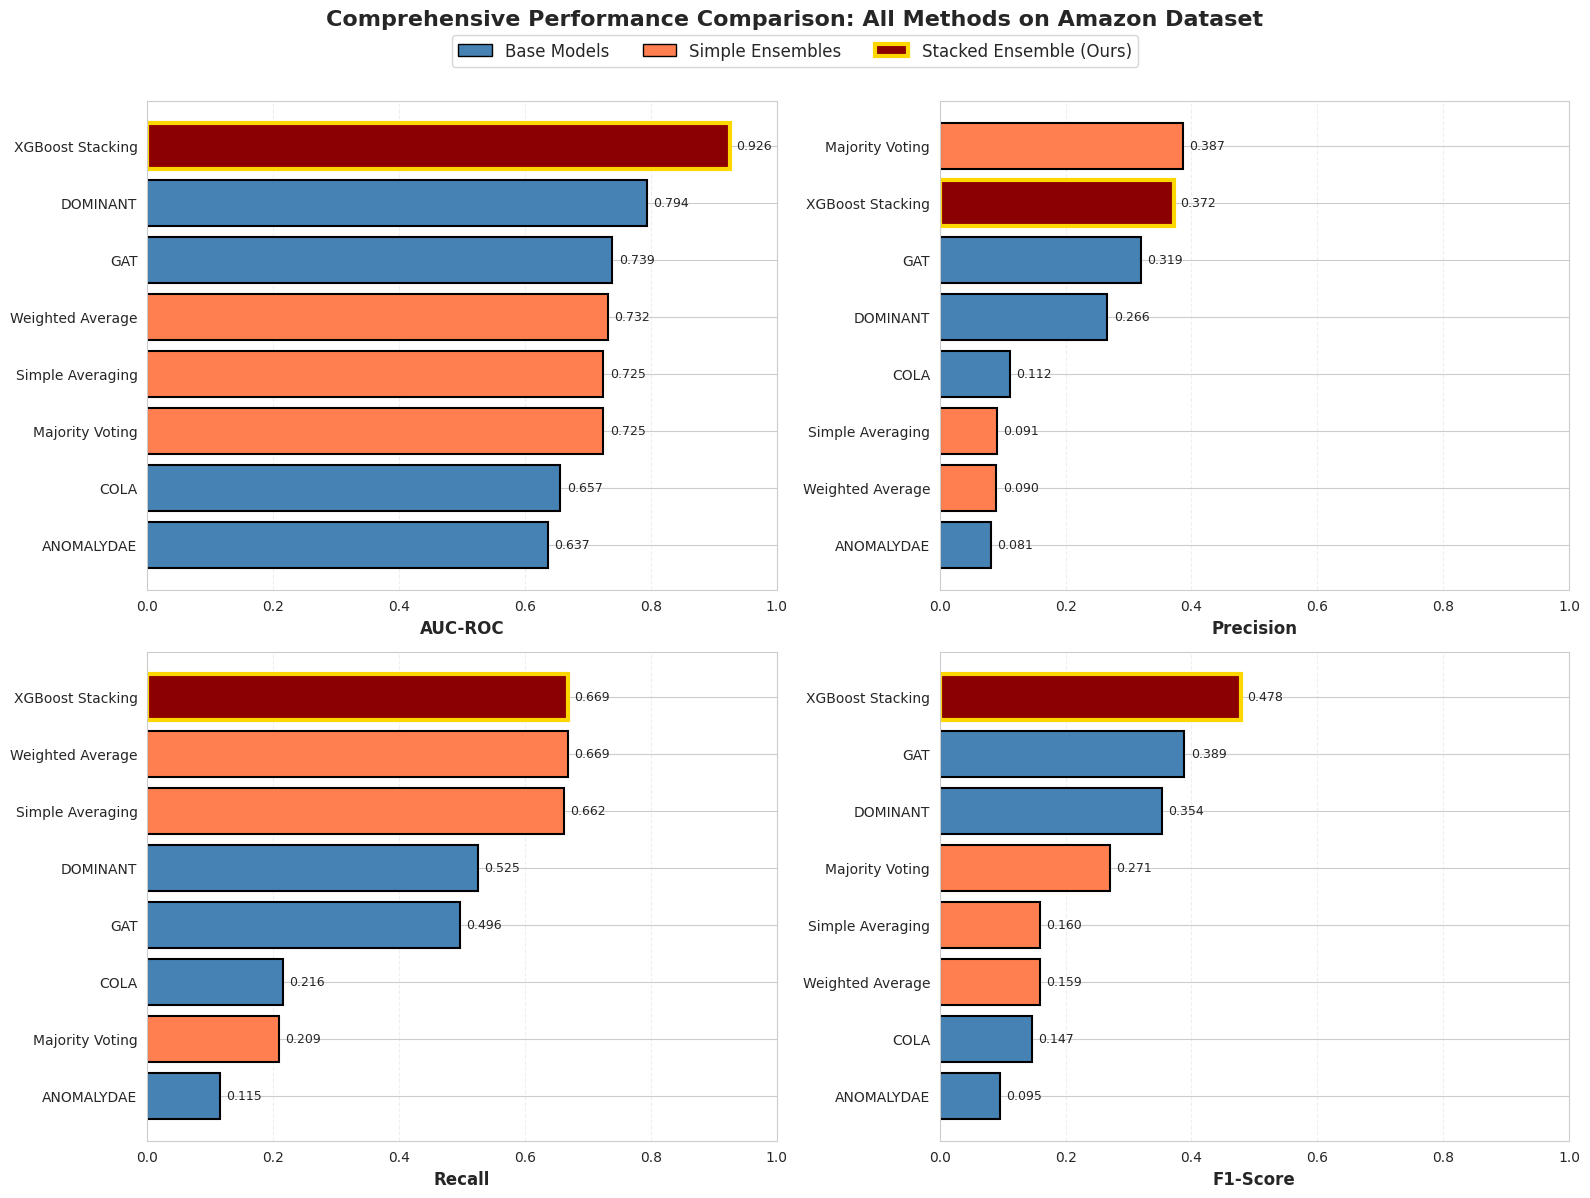

✓ Comprehensive comparison visualization saved!


In [ ]:
plt.close('all')

# Visualize all methods comparison

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

metrics = ['AUC-ROC', 'Precision', 'Recall', 'F1-Score']

for idx, metric in enumerate(metrics):
    ax = axes[idx]

    # Sort by current metric
    df_sorted = df_comprehensive.sort_values(metric, ascending=True)

    # Color by type
    colors = []
    for method_type in df_sorted['Type']:
        if method_type == 'Base Model':
            colors.append('steelblue')
        elif method_type == 'Simple Ensemble':
            colors.append('coral')
        else:  # Stacked Ensemble
            colors.append('darkred')

    bars = ax.barh(df_sorted['Method'], df_sorted[metric],
                   color=colors, edgecolor='black', linewidth=1.5)

    # Highlight our method
    for i, method in enumerate(df_sorted['Method']):
        if method == 'XGBoost Stacking':
            bars[i].set_edgecolor('gold')
            bars[i].set_linewidth(3)

    ax.set_xlabel(metric, fontsize=12, fontweight='bold')
    ax.set_xlim([0, 1.0])
    ax.grid(axis='x', alpha=0.3, linestyle='--')

    # Add value labels
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.01, bar.get_y() + bar.get_height()/2.,
                f'{width:.3f}',
                ha='left', va='center', fontsize=9)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', edgecolor='black', label='Base Models'),
    Patch(facecolor='coral', edgecolor='black', label='Simple Ensembles'),
    Patch(facecolor='darkred', edgecolor='gold', linewidth=3, label='Stacked Ensemble (Ours)')
]
fig.legend(handles=legend_elements, loc='upper center',
           bbox_to_anchor=(0.5, 0.98), ncol=3, fontsize=12)

plt.suptitle('Comprehensive Performance Comparison: All Methods on Amazon Dataset',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('results/figures/comprehensive_comparison_all_methods_amazon.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Comprehensive comparison visualization saved!")

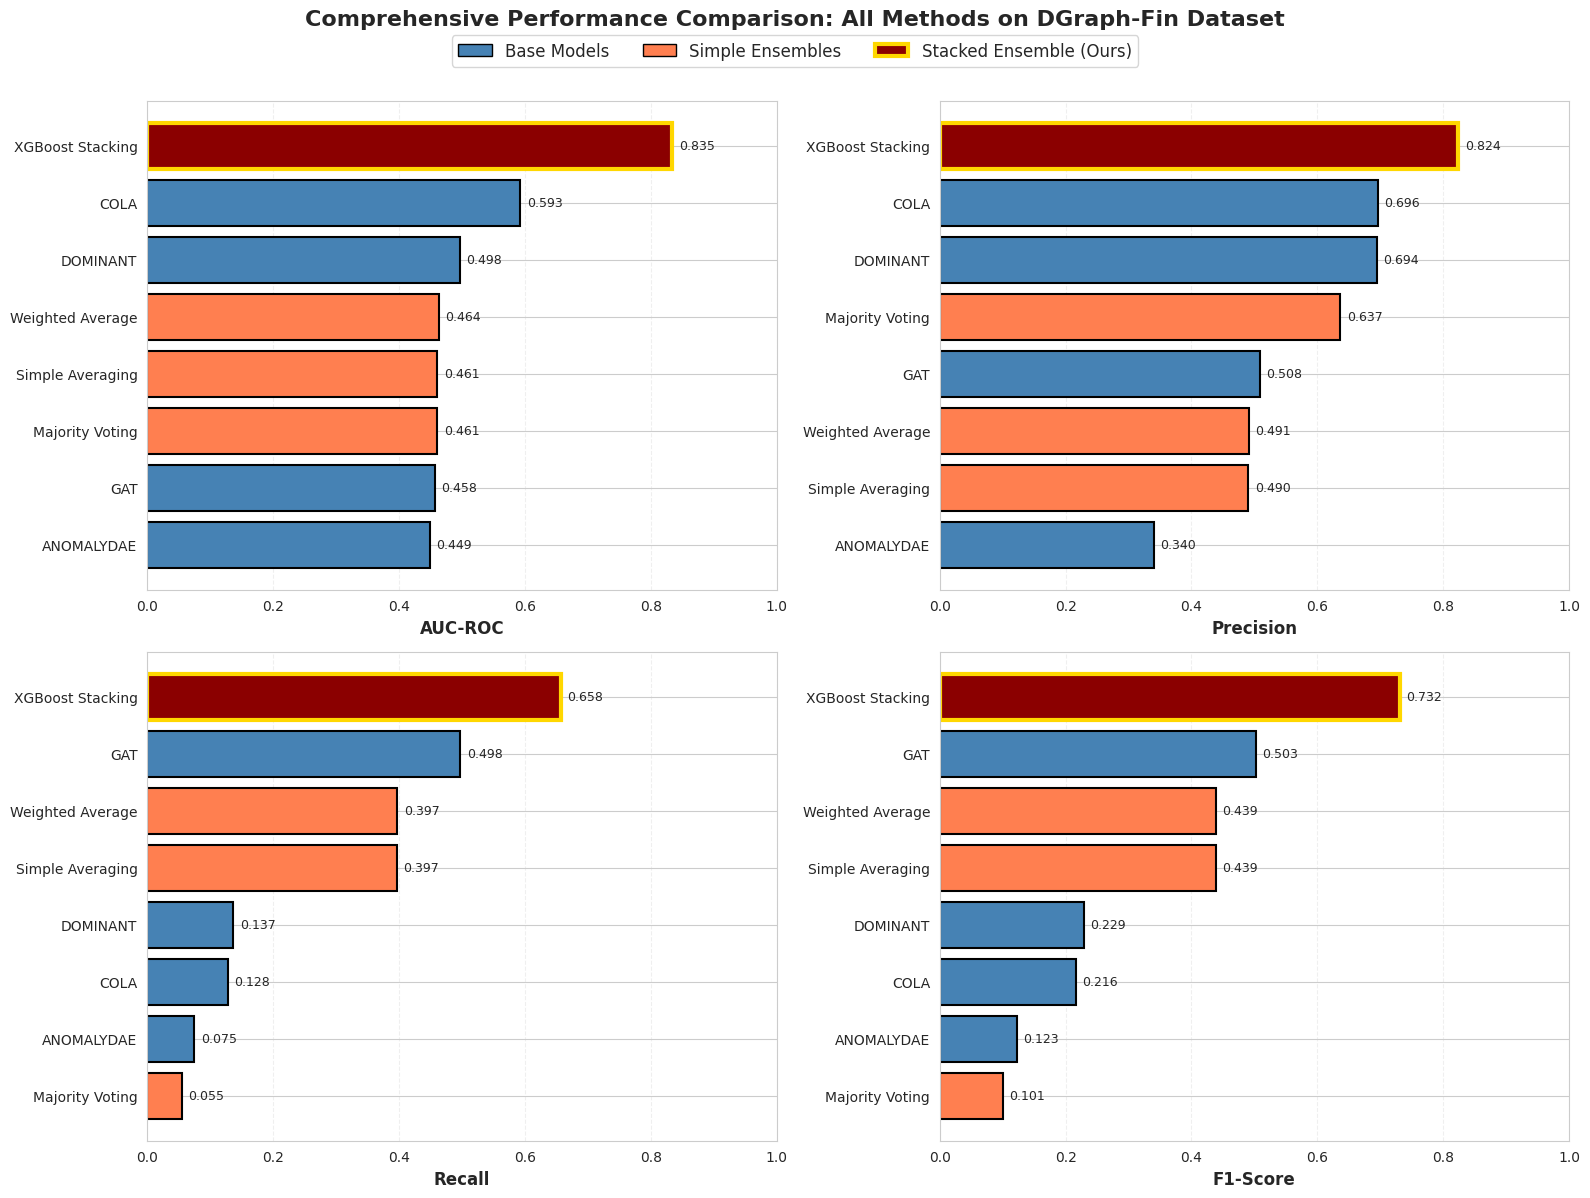

✓ Comprehensive comparison visualization saved!


In [ ]:
plt.close('all')

# Visualize all methods comparison

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

metrics = ['AUC-ROC', 'Precision', 'Recall', 'F1-Score']

for idx, metric in enumerate(metrics):
    ax = axes[idx]

    # Sort by current metric
    df_sorted_dg = df_comprehensive_dgraph.sort_values(metric, ascending=True)

    # Color by type
    colors = []
    for method_type in df_sorted_dg['Type']:
        if method_type == 'Base Model':
            colors.append('steelblue')
        elif method_type == 'Simple Ensemble':
            colors.append('coral')
        else:  # Stacked Ensemble
            colors.append('darkred')

    bars = ax.barh(df_sorted_dg['Method'], df_sorted_dg[metric],
                   color=colors, edgecolor='black', linewidth=1.5)

    # Highlight our method
    for i, method in enumerate(df_sorted_dg['Method']):
        if method == 'XGBoost Stacking':
            bars[i].set_edgecolor('gold')
            bars[i].set_linewidth(3)

    ax.set_xlabel(metric, fontsize=12, fontweight='bold')
    ax.set_xlim([0, 1.0])
    ax.grid(axis='x', alpha=0.3, linestyle='--')

    # Add value labels
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.01, bar.get_y() + bar.get_height()/2.,
                f'{width:.3f}',
                ha='left', va='center', fontsize=9)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', edgecolor='black', label='Base Models'),
    Patch(facecolor='coral', edgecolor='black', label='Simple Ensembles'),
    Patch(facecolor='darkred', edgecolor='gold', linewidth=3, label='Stacked Ensemble (Ours)')
]
fig.legend(handles=legend_elements, loc='upper center',
           bbox_to_anchor=(0.5, 0.98), ncol=3, fontsize=12)

plt.suptitle('Comprehensive Performance Comparison: All Methods on DGraph-Fin Dataset',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('results/figures/comprehensive_comparison_all_methods_dgraph.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Comprehensive comparison visualization saved!")

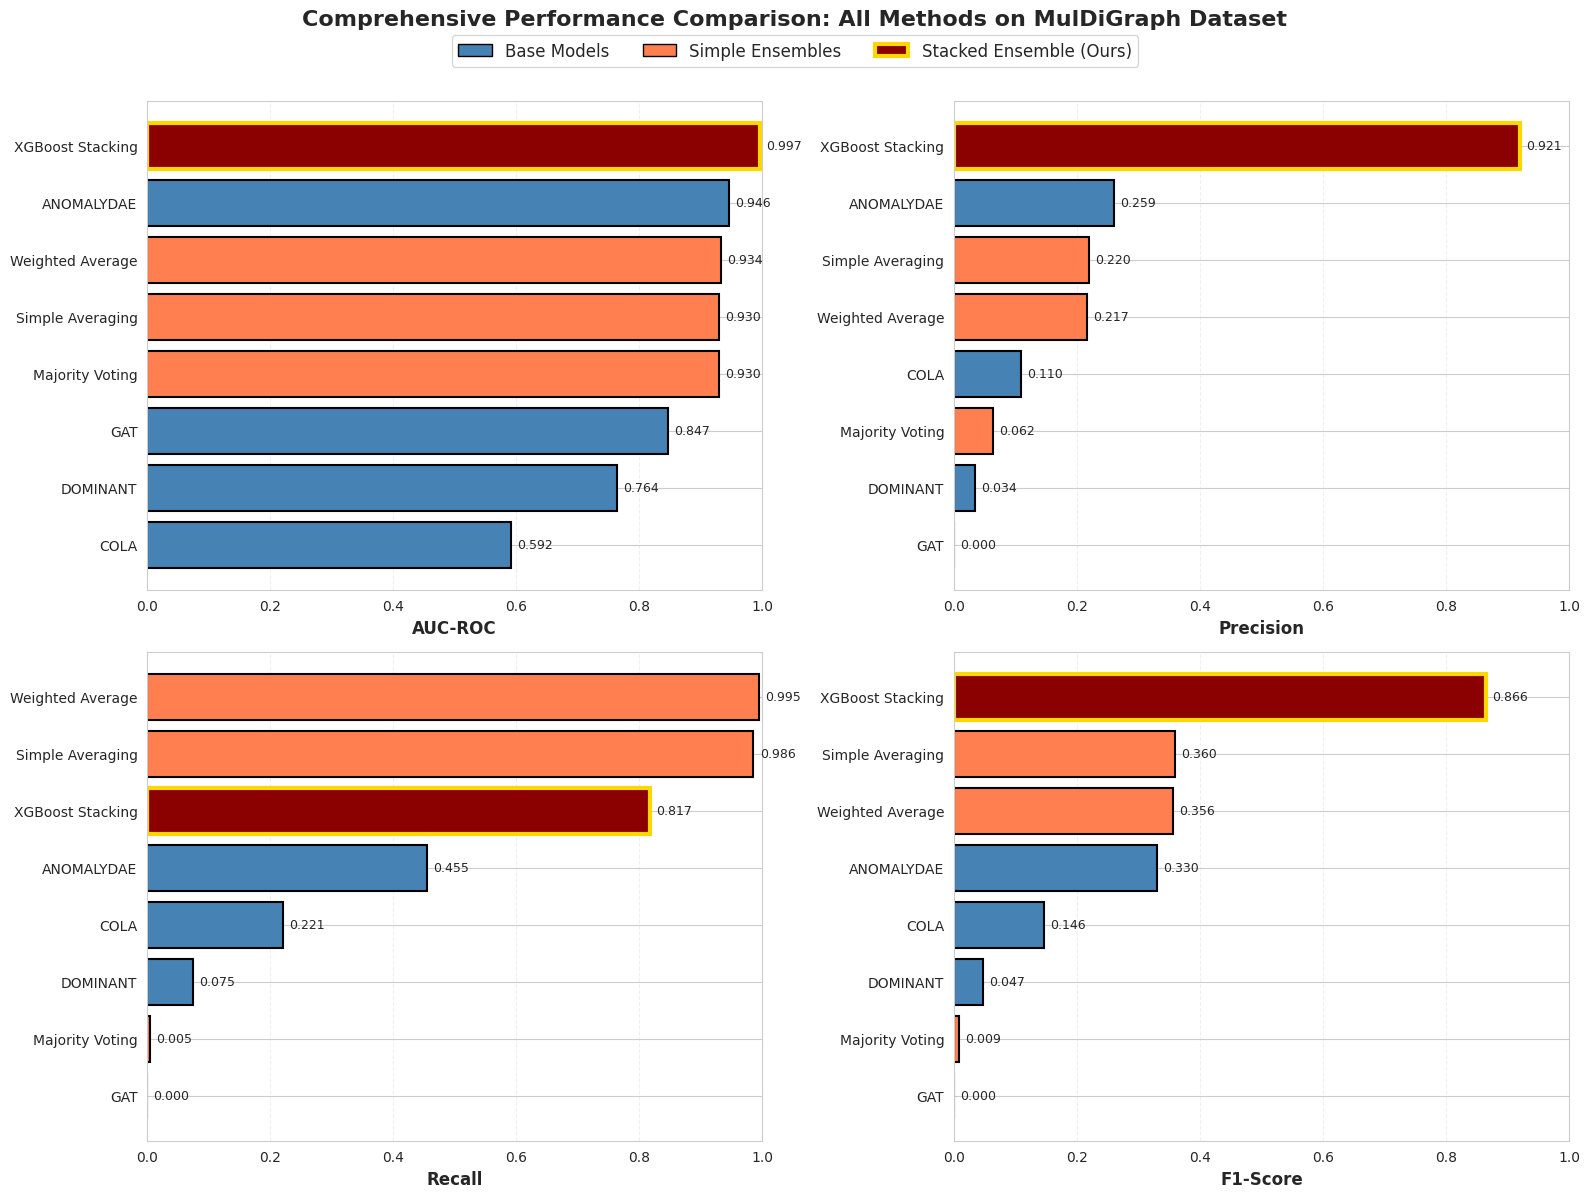

✓ Comprehensive comparison visualization saved!


In [ ]:
plt.close('all')

# Visualize all methods comparison

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

metrics = ['AUC-ROC', 'Precision', 'Recall', 'F1-Score']

for idx, metric in enumerate(metrics):
    ax = axes[idx]

    # Sort by current metric
    df_sorted_md = df_comprehensive_muldi.sort_values(metric, ascending=True)

    # Color by type
    colors = []
    for method_type in df_sorted_md['Type']:
        if method_type == 'Base Model':
            colors.append('steelblue')
        elif method_type == 'Simple Ensemble':
            colors.append('coral')
        else:  # Stacked Ensemble
            colors.append('darkred')

    bars = ax.barh(df_sorted_md['Method'], df_sorted_md[metric],
                   color=colors, edgecolor='black', linewidth=1.5)

    # Highlight our method
    for i, method in enumerate(df_sorted_md['Method']):
        if method == 'XGBoost Stacking':
            bars[i].set_edgecolor('gold')
            bars[i].set_linewidth(3)

    ax.set_xlabel(metric, fontsize=12, fontweight='bold')
    ax.set_xlim([0, 1.0])
    ax.grid(axis='x', alpha=0.3, linestyle='--')

    # Add value labels
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.01, bar.get_y() + bar.get_height()/2.,
                f'{width:.3f}',
                ha='left', va='center', fontsize=9)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', edgecolor='black', label='Base Models'),
    Patch(facecolor='coral', edgecolor='black', label='Simple Ensembles'),
    Patch(facecolor='darkred', edgecolor='gold', linewidth=3, label='Stacked Ensemble (Ours)')
]
fig.legend(handles=legend_elements, loc='upper center',
           bbox_to_anchor=(0.5, 0.98), ncol=3, fontsize=12)

plt.suptitle('Comprehensive Performance Comparison: All Methods on MulDiGraph Dataset',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('results/figures/comprehensive_comparison_all_methods_muldi.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Comprehensive comparison visualization saved!")

In [ ]:
# ============================================================
# LEAVE-ONE-OUT ABLATION STUDY - AMAZON DATASET
# ============================================================
print("\n" + "="*70)
print("LEAVE-ONE-OUT ABLATION STUDY: AMAZON DATASET")
print("="*70)

from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

# Get full meta-feature matrix for Amazon
test_mask_am  = amazon_predictions['dominant']['test_mask']
y_true_am     = (amazon_predictions['dominant']['ground_truth'] > 0).astype(int)
y_test_am     = y_true_am[test_mask_am]
y_val_am      = y_true_am[amazon_predictions['dominant']['val_mask']]

# All 4 base model scores
all_scores_am = {
    'dominant':   amazon_predictions['dominant']['scores'],
    'anomalydae': amazon_predictions['anomalydae']['scores'],
    'cola':       amazon_predictions['cola']['scores'],
    'gat':        amazon_predictions['gat']['scores'],
}

# Convert tensors
for k in all_scores_am:
    if isinstance(all_scores_am[k], torch.Tensor):
        all_scores_am[k] = all_scores_am[k].cpu().numpy()
    all_scores_am[k] = np.array(all_scores_am[k], dtype=np.float32)

model_names  = ['dominant', 'anomalydae', 'cola', 'gat']
ablation_results = []

# ── Full ensemble first ──────────────────────────────────────
X_full = np.column_stack([all_scores_am[m] for m in model_names])
X_train_full = X_full[amazon_predictions['dominant']['train_mask']]
y_train_full = y_true_am[amazon_predictions['dominant']['train_mask']]
X_val_full   = X_full[amazon_predictions['dominant']['val_mask']]
X_test_full  = X_full[test_mask_am]

neg = (y_train_full == 0).sum()
pos = (y_train_full == 1).sum()
spw = neg / pos if pos > 0 else 1.0

clf_full = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    objective='binary:logistic', eval_metric='aucpr',
    scale_pos_weight=spw, subsample=0.8,
    colsample_bytree=0.8, random_state=42,
    use_label_encoder=False, early_stopping_rounds=30
)
clf_full.fit(X_train_full, y_train_full,
             eval_set=[(X_val_full, y_val_am)],
             verbose=False)

full_auc = roc_auc_score(y_test_am,
                          clf_full.predict_proba(X_test_full)[:, 1])

ablation_results.append({
    'Configuration': 'Full ensemble (all 4 models)',
    'AUC-ROC': full_auc,
    'Delta': '---'
})
print(f"Full ensemble AUC-ROC: {full_auc:.4f}")

# ── Leave-one-out ────────────────────────────────────────────
for left_out in model_names:
    remaining = [m for m in model_names if m != left_out]

    X_loo = np.column_stack([all_scores_am[m] for m in remaining])
    X_train_loo = X_loo[amazon_predictions['dominant']['train_mask']]
    X_val_loo   = X_loo[amazon_predictions['dominant']['val_mask']]
    X_test_loo  = X_loo[test_mask_am]

    neg = (y_train_full == 0).sum()
    pos = (y_train_full == 1).sum()
    spw = neg / pos if pos > 0 else 1.0

    clf_loo = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        objective='binary:logistic', eval_metric='aucpr',
        scale_pos_weight=spw, subsample=0.8,
        colsample_bytree=0.8, random_state=42,
        use_label_encoder=False, early_stopping_rounds=30
    )
    clf_loo.fit(X_train_loo, y_train_full,
                eval_set=[(X_val_loo, y_val_am)],
                verbose=False)

    loo_auc = roc_auc_score(y_test_am,
                             clf_loo.predict_proba(X_test_loo)[:, 1])
    delta   = ((loo_auc - full_auc) / full_auc) * 100

    ablation_results.append({
        'Configuration': f'Without {left_out.upper()}',
        'AUC-ROC': loo_auc,
        'Delta': f'{delta:+.2f}%'
    })
    print(f"Without {left_out.upper():12s}: AUC={loo_auc:.4f}  "
          f"Delta={delta:+.2f}%")

# ── Results table ────────────────────────────────────────────
df_ablation = pd.DataFrame(ablation_results)
print("\n" + "="*70)
print("ABLATION STUDY RESULTS")
print("="*70)
print(df_ablation.to_string(index=False))

df_ablation.to_csv('results/tables/ablation_study_amazon.csv', index=False)
print("\n✓ Saved to results/tables/ablation_study_amazon.csv")


LEAVE-ONE-OUT ABLATION STUDY: AMAZON DATASET
Full ensemble AUC-ROC: 0.9480
Without DOMINANT    : AUC=0.8200  Delta=-13.50%
Without ANOMALYDAE  : AUC=0.9152  Delta=-3.46%
Without COLA        : AUC=0.9173  Delta=-3.24%
Without GAT         : AUC=0.8806  Delta=-7.11%

ABLATION STUDY RESULTS
               Configuration  AUC-ROC   Delta
Full ensemble (all 4 models) 0.948029     ---
            Without DOMINANT 0.820016 -13.50%
          Without ANOMALYDAE 0.915218  -3.46%
                Without COLA 0.917334  -3.24%
                 Without GAT 0.880601  -7.11%

✓ Saved to results/tables/ablation_study_amazon.csv


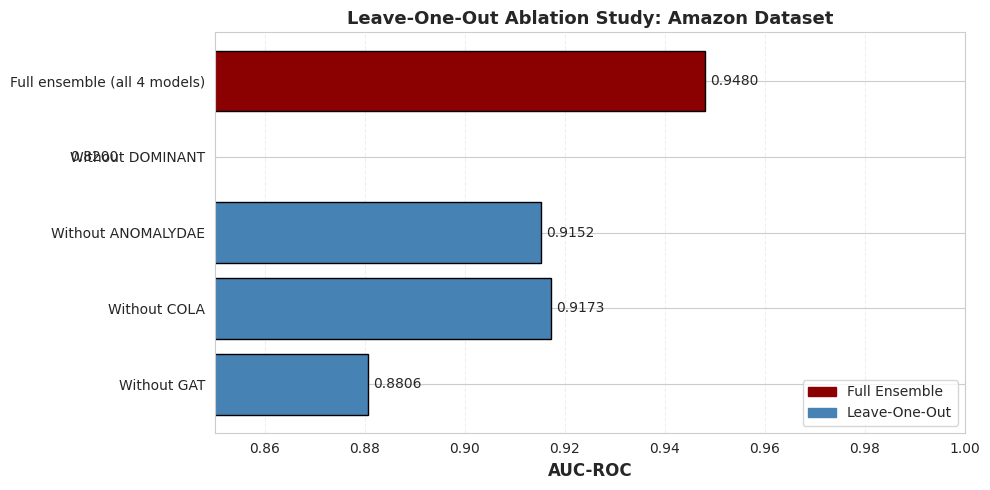

✓ Ablation plot saved!


In [ ]:
# ── Plot ablation results ────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.close('all')
fig, ax = plt.subplots(figsize=(10, 5))

configs = df_ablation['Configuration'].tolist()
aucs    = df_ablation['AUC-ROC'].tolist()
colors  = ['darkred'] + ['steelblue'] * (len(configs) - 1)

bars = ax.barh(configs, aucs, color=colors, edgecolor='black')

for bar, auc in zip(bars, aucs):
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height() / 2,
            f'{auc:.4f}', va='center', ha='left', fontsize=10)

ax.set_xlabel('AUC-ROC', fontsize=12, fontweight='bold')
ax.set_xlim([0.85, 1.0])
ax.set_title('Leave-One-Out Ablation Study: Amazon Dataset',
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.invert_yaxis()

full_patch = mpatches.Patch(color='darkred',  label='Full Ensemble')
loo_patch  = mpatches.Patch(color='steelblue', label='Leave-One-Out')
ax.legend(handles=[full_patch, loo_patch], loc='lower right')

plt.tight_layout()
plt.savefig('results/figures/ablation_study_amazon.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ Ablation plot saved!")